# GGA Network Training - Step 5: SCF Solver Exploration

This notebook extends step 4 by exploring **SCF self-consistency** during
training and evaluation. Instead of the single one-shot density evaluation
used in step 4, step 5 trains each architecture under three solver
configurations and compares the effect on atomization energies and density
quality.

## Solver Configurations

| Label | Mode | Max Cycles | Description |
|-------|------|-----------|-------------|
| **oneshot** | ONESHOT | 0 | Single-pass density evaluation (step 4 baseline) |
| **fixed_j_3** | FIXED_J | 3 | 3 SCF cycles with frozen Coulomb matrix |
| **full_3** | FULL | 3 | 3 SCF cycles with full Fock rebuild each iteration |

## Training Matrix

**8 deep architectures x 3 loss approaches x 3 solver configs = 72 runs**

### Loss Approaches

| Approach | Energy Calculation | Density Matching | Description |
|----------|-------------------|------------------|-------------|
| **A** | Fixed-density | None | AE only on PBE density |
| **B** | Fixed-density | One-shot DM -> HF target | AE + DM correction learning |
| **C** | Fixed-density | One-shot grid rho -> HF target | AE + grid density correction |

### Network Architectures (8 deep variants)

| Architecture | Inputs | Dimension |
|--------------|--------|-----------|
| `deep`, `deep_attn` | $[\rho, \sigma]$ | 2 |
| `deep_cusp`, `deep_cusp_attn` | $[\rho, \sigma, f_{cusp}, \log Z]$ | 4 |
| `deep_dm`, `deep_dm_attn` | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}]$ | 5 |
| `deep_combined`, `deep_combined_attn` | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}, f_{cusp}, \log Z]$ | 7 |

**Total: 72 models** = 8 architectures x 3 training approaches x 3 solver configs

---

> **Note (2026-04-27):** Step-5 attention runs prior to this date used a
> broken `SelfAttentionBlock` (softmax channel-gate, not self-attention).
> The block has been rewritten to canonical multi-head scaled-dot-product
> attention; the previous `*_attn` checkpoints have been deleted and must
> be regenerated.


In [1]:
import os
import json
import gc
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
# JAX config: pin x64 dtype and CPU device *before* importing jnp or any
# library that may trigger JAX tracing. These must not change later in the
# notebook -- flipping jax_enable_x64 after traces are cached produces
# inconsistent dtypes.
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])
# Persistent compilation cache: writes compiled XLA HLO/LLVM to disk so
# that kernel restarts (e.g. after a crash) don't re-pay the full compile
# cost. The step5 sweep compiles ~89 training specs; without this cache
# a single LLVM OOM kills the entire 90-min sweep.
os.makedirs(".jax_compilation_cache", exist_ok=True)
jax.config.update("jax_compilation_cache_dir", ".jax_compilation_cache")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 1.0)
import jax.numpy as jnp
import equinox as eqx

from pyscf import gto, dft, scf, cc

import xcquinox.alec as alec
import xcquinox.features
from xcquinox.alec.solver import SolverConfig, SolverBackend, SolverMode
from xcquinox.alec.balancing import (
    LossNormConfig, TwoPhaseConfig, GradNormConfig,
)

# tqdm.auto picks tqdm.notebook.tqdm (ipywidgets) under JupyterLab and
# tqdm.std.tqdm in a plain script/terminal, so the same symbol gives a
# sensible progress bar in either context.
from tqdm.auto import tqdm


In [2]:
BASIS = 'def2-svp'
CHECKPOINT_BASE = 'checkpoints_step5'
GRID_LEVEL = 1
PRETRAIN_ATOMS = (("H", 1), ("He", 0), ("O", 2), ("N", 3))
H2O_COORDS = "O 0.0000 0.0000 0.1173; H 0.0000 0.7572 -0.4692; H 0.0000 -0.7572 -0.4692"

# Flip to True to skip pretraining for any arch that already has both
# ``xnet.eqx`` and ``cnet.eqx`` at ``CHECKPOINT_BASE/pretrain/<arch>/``.
PRETRAIN_SKIP_IF_EXISTS = False

# Flip to True to skip the main training loop for any (arch, loss, solver)
# run that already has a ``model.eqx`` at
# ``CHECKPOINT_BASE/train/<arch>/<loss_name>/<solver_label>/``.
TRAIN_SKIP_IF_EXISTS = False

# Flip to True to force re-evaluation of models even when cached
# ``aggregate.json`` / ``transfer_results.pkl`` artifacts already exist.
RERUN_EVAL = True

# Pretraining loss weighting. "unweighted" is the default and is what the
# parity plots in step3b/step4 were tuned for — it fits PBE enhancement
# factors pointwise across all (rho, sigma) regimes.
#
# "integration" weights pointwise MSE by |rho * eps^LDA| so the loss
# directly minimizes integrated E_xc error. This is theoretically motivated
# (the toy regression in test_pretrain_weighted.py shows integration mode
# beats unweighted by >20 orders of magnitude on a smooth 1-parameter
# target), BUT in practice it aggressively down-weights low-rho points by
# ~1e6x, which is where PBE F_x approaches the Lieb-Oxford bound (~1.804).
# The result: NN saturates around F_x ~ 1.3 at target F_x = 1.8, producing
# visible parity-plot under-fitting for descriptor-rich architectures
# (deep_cusp, deep_combined, and their attn variants). Set to
# "integration" only if you understand this trade-off and have enough
# training steps / network capacity to compensate.
PRETRAIN_LOSS_WEIGHTING = "integration"

# RUN_DIR namespaces every pretrain-loss-weighting-DEPENDENT artifact under
# CHECKPOINT_BASE/<weighting>/, so back-to-back runs of this notebook with
# PRETRAIN_LOSS_WEIGHTING set to "unweighted" then "integration" do NOT
# overwrite each other's checkpoints / figures / eval outputs. Mirrors the
# step-6 generator's branching layout (commit 92b9dc342 introduced the
# pattern in step 6; step 5 was missing it until this commit).
#
# Pretrain-INDEPENDENT shared inputs (external CCSD reference data,
# pretrain_data.npz which carries grid coords + densities + Becke weights,
# but is the SAME across both weightings -- only its USE in the loss
# differs) live directly under CHECKPOINT_BASE so both runs share them.
RUN_DIR              = os.path.join(CHECKPOINT_BASE, PRETRAIN_LOSS_WEIGHTING)
pretrain_dir         = os.path.join(RUN_DIR, "pretrain")
train_dir            = os.path.join(RUN_DIR, "train")
train_balancing_dir  = os.path.join(RUN_DIR, "train_balancing")
eval_dir             = os.path.join(RUN_DIR, "eval")
eval_baseline_dir    = os.path.join(RUN_DIR, "eval_baseline")
eval_balancing_dir   = os.path.join(RUN_DIR, "eval_balancing")
figures_dir          = os.path.join(RUN_DIR, "figures")
baseline_dir         = os.path.join(RUN_DIR, "baseline")
test_new_dir         = os.path.join(RUN_DIR, "test_new")
transfer_results_path = os.path.join(RUN_DIR, "transfer_results.pkl")
ext_data_dir         = os.path.join(CHECKPOINT_BASE, "external_data")
pretrain_data_dir    = os.path.join(CHECKPOINT_BASE, "pretrain_data")

import pathlib
for _d in (CHECKPOINT_BASE, RUN_DIR, pretrain_dir, train_dir, train_balancing_dir,
           eval_dir, eval_baseline_dir, eval_balancing_dir, figures_dir,
           baseline_dir, test_new_dir,
           ext_data_dir, pretrain_data_dir):
    os.makedirs(_d, exist_ok=True)
pathlib.Path(CHECKPOINT_BASE, "VERSION").write_text("step5-v2\n")
print(f"CHECKPOINT_BASE={CHECKPOINT_BASE}  BASIS={BASIS}  GRID_LEVEL={GRID_LEVEL}")
print(f"  PRETRAIN_LOSS_WEIGHTING = {PRETRAIN_LOSS_WEIGHTING!r}")
print(f"  RUN_DIR        = {RUN_DIR}")
print(f"  pretrain_dir   = {pretrain_dir}")
print(f"  train_dir      = {train_dir}")
print(f"  figures_dir    = {figures_dir}")
print("DATA VERSION: step5-v2 (real-attention)")
print(f"  Wipe {RUN_DIR}/ to regenerate this pretraining variant only;")
print(f"  ext_data_dir + pretrain_data_dir are shared across both variants.")


CHECKPOINT_BASE=checkpoints_step5  BASIS=def2-svp  GRID_LEVEL=1
  PRETRAIN_LOSS_WEIGHTING = 'integration'
  RUN_DIR        = checkpoints_step5/integration
  pretrain_dir   = checkpoints_step5/integration/pretrain
  train_dir      = checkpoints_step5/integration/train
  figures_dir    = checkpoints_step5/integration/figures
DATA VERSION: step5-v2 (real-attention)
  Wipe checkpoints_step5/integration/ to regenerate this pretraining variant only;
  ext_data_dir + pretrain_data_dir are shared across both variants.


In [3]:
# Print the deep-only registered architectures from alec.ARCHITECTURES.
# Step 5 focuses on deep variants only (8 total).
# Fields printed: name, depth, nodes (hidden size), attention flag, descriptors.
_deep_names = [n for n in alec.ARCHITECTURES.keys() if n.startswith("deep")]
_header = f"{'arch_name':<22} {'depth':>6} {'nodes':>6} {'attention':>10} {'num_heads':>10}  descriptors"
print(_header)
print("-" * len(_header))
for _name in _deep_names:
    _cfg = alec.get_architecture(_name)
    _descs = ", ".join(s.name for s in _cfg.descriptors) or "-"
    print(f"{_name:<22} {_cfg.depth:>6} {_cfg.nodes:>6} {str(_cfg.attention):>10} {_cfg.num_heads:>10}  {_descs}")
print(f"\n{len(_deep_names)} deep architectures selected")


arch_name               depth  nodes  attention  num_heads  descriptors
-----------------------------------------------------------------------
deep                        4     32      False          1  -
deep_attn                   4     32       True          4  -
deep_cusp                   4     32      False          1  cusp
deep_cusp_attn              4     32       True          4  cusp
deep_dm                     4     32      False          1  dm_statistics
deep_dm_attn                4     32       True          4  dm_statistics
deep_combined               4     32      False          1  dm_statistics, cusp
deep_combined_attn          4     32       True          4  dm_statistics, cusp

8 deep architectures selected


In [4]:
ARCH_NAMES = [n for n in alec.ARCHITECTURES.keys() if n.startswith("deep")]

cmap = plt.get_cmap("tab10")
arch_colors = {name: cmap(i / max(1, len(ARCH_NAMES) - 1)) for i, name in enumerate(ARCH_NAMES)}

print(f"Selected {len(ARCH_NAMES)} architectures:")
for _n in ARCH_NAMES:
    print(f"  {_n}")


Selected 8 architectures:
  deep
  deep_attn
  deep_cusp
  deep_cusp_attn
  deep_dm
  deep_dm_attn
  deep_combined
  deep_combined_attn


In [5]:
SCF_CONFIGS = {
    "oneshot": SolverConfig(
        backend=SolverBackend.MANUAL,
        mode=SolverMode.ONESHOT,
    ),
    "fixed_j_3": SolverConfig(
        backend=SolverBackend.MANUAL,
        mode=SolverMode.FIXED_J,
        max_cycles=3,
        conv_tol=1e-6,
    ),
    "full_3": SolverConfig(
        backend=SolverBackend.MANUAL,
        mode=SolverMode.FULL,
        max_cycles=3,
        conv_tol=1e-6,
    ),
}

SOLVER_LABELS = list(SCF_CONFIGS.keys())

cmap_solver = plt.get_cmap("Set2")
solver_colors = {label: cmap_solver(i / max(1, len(SOLVER_LABELS) - 1)) for i, label in enumerate(SOLVER_LABELS)}

print(f"Solver configs ({len(SOLVER_LABELS)}):")
for _label in SOLVER_LABELS:
    _cfg = SCF_CONFIGS[_label]
    print(f"  {_label}: mode={_cfg.mode.value}, max_cycles={_cfg.max_cycles}")


Solver configs (3):
  oneshot: mode=oneshot, max_cycles=0
  fixed_j_3: mode=fixed_j, max_cycles=3
  full_3: mode=full, max_cycles=3


## Section 3: Pretraining

Before the main training loop, each network (xnet / cnet) is **pretrained** on
atomic PBE enhancement factors so the weights start near a meaningful baseline
instead of a cold random initialisation. Starting from random weights causes the
main training loss to diverge; pretraining on known-good PBE targets avoids this.

### Pretrain atoms

Four atoms are used: **H** (spin=1), **He** (spin=0), **O** (spin=2), **N**
(spin=3). Their DFT grids cover a wide range of densities and gradient norms,
giving xnet / cnet a representative sample of the `(rho, sigma)` input space.

### Target: PBE enhancement factors

For each atom the PBE exchange and correlation enhancement factors are computed
via `pyscf`'s `eval_xc` with the exact libxc functional strings (`"PBE,"` /
`",PBE"` for GGA, `"LDA_X,"` / `",LDA_C_PW"` for the LDA baseline). The
network targets are `F_x - 1` and `F_c - 1` (shift by 1 so the loss near PBE
is near zero).

### Low-density cutoff and clipping

Grid points with `rho <= 1e-10` are dropped at write time — below this threshold
the density is numerically zero and the enhancement factor is undefined. The
targets are clipped to `[-5, 5]` to suppress outliers in the atomic core and
tail regions that would otherwise dominate the loss.


In [6]:
# Pretrain data generation (inline pyscf) — matches step3b Cell 10.
rho_list, sigma_list, Fx_list, Fc_list = [], [], [], []
weights_list = []  # Becke-Lebedev quadrature dr_i — needed by integration mode
cusp_list, dm_list = [], []

# Compute gate: only compute extended features iff ARCH_NAMES contains
# architectures that actually declare the corresponding descriptor.
_arch_objs = [alec.get_architecture(n) for n in ARCH_NAMES]
need_cusp = any(s.name == "cusp" for a in _arch_objs for s in a.descriptors)
need_dm = any(s.name == "dm_statistics" for a in _arch_objs for s in a.descriptors)

for atom_symbol, spin in PRETRAIN_ATOMS:
    mol = gto.M(atom=f"{atom_symbol} 0 0 0", basis=BASIS, charge=0, spin=spin, verbose=0)
    mf = dft.UKS(mol) if spin else dft.RKS(mol)
    mf.xc = "pbe"
    mf.grids.level = GRID_LEVEL
    mf.kernel()

    ao = mf._numint.eval_ao(mol, mf.grids.coords, deriv=1)
    dm_ab = mf.make_rdm1()
    is_uks = (dm_ab.ndim == 3)

    if is_uks:
        # Open-shell: spin-resolve and call libxc with spin=1 (UKS PBE).
        # Closed-shell-on-total-density (spin=0) is wrong for any open-shell
        # atom — PBE 1996 §III spin-scaling gives F_x_UKS != F_x_RKS(rho_total).
        dm_total = dm_ab[0] + dm_ab[1]
        rho_a_gga = mf._numint.eval_rho(mol, ao, dm_ab[0], xctype="GGA", hermi=True)
        rho_b_gga = mf._numint.eval_rho(mol, ao, dm_ab[1], xctype="GGA", hermi=True)
        rho_gga_uks = np.stack([rho_a_gga, rho_b_gga], axis=0)
        rho = rho_a_gga[0] + rho_b_gga[0]
        nabla_total = rho_a_gga[1:4] + rho_b_gga[1:4]
        sigma = (nabla_total ** 2).sum(axis=0)
        ex_pbe = mf._numint.eval_xc("PBE,", rho_gga_uks, spin=1)[0]
        ec_pbe = mf._numint.eval_xc(",PBE", rho_gga_uks, spin=1)[0]
        ex_lda = mf._numint.eval_xc("LDA_X,", (rho_a_gga[0], rho_b_gga[0]), spin=1)[0]
        ec_lda = mf._numint.eval_xc(",LDA_C_PW", (rho_a_gga[0], rho_b_gga[0]), spin=1)[0]
    else:
        dm_total = dm_ab
        rho_gga = mf._numint.eval_rho(mol, ao, dm_total, xctype="GGA", hermi=True)
        rho = rho_gga[0]
        sigma = rho_gga[1]**2 + rho_gga[2]**2 + rho_gga[3]**2
        ex_pbe = mf._numint.eval_xc("PBE,", rho_gga, spin=0)[0]
        ec_pbe = mf._numint.eval_xc(",PBE", rho_gga, spin=0)[0]
        ex_lda = mf._numint.eval_xc("LDA_X,", rho, spin=0)[0]
        ec_lda = mf._numint.eval_xc(",LDA_C_PW", rho, spin=0)[0]

    # np.where-based safe division (NOT a boolean mask — boolean masks drop points
    # step3b keeps; spec Rounds 8-10 regression guard)
    ex_lda_safe = np.where(np.abs(ex_lda) > 1e-12, ex_lda, 1e-12)
    ec_lda_safe = np.where(np.abs(ec_lda) > 1e-12, ec_lda, 1e-12)
    Fx_minus_1 = ex_pbe / ex_lda_safe - 1.0
    Fc_minus_1 = ec_pbe / ec_lda_safe - 1.0

    Fx_minus_1 = np.clip(Fx_minus_1, -5.0, 5.0)
    Fc_minus_1 = np.clip(Fc_minus_1, -5.0, 5.0)

    # Low-density mask at write time — threshold is 1e-10 (NOT 1e-6),
    # strictly > (NOT >=). Step3b uses the looser cutoff to keep the atomic tail.
    valid = rho > 1e-10
    rho_write = rho[valid]
    sigma_write = sigma[valid]
    Fx_write = Fx_minus_1[valid]
    Fc_write = Fc_minus_1[valid]
    weights_write = np.asarray(mf.grids.weights)[valid]

    rho_list.append(rho_write)
    sigma_list.append(sigma_write)
    Fx_list.append(Fx_write)
    Fc_list.append(Fc_write)
    weights_list.append(weights_write)

    if need_cusp:
        coords_v = mf.grids.coords[valid]
        cusp_feat = xcquinox.features.compute_cusp_descriptor(
            jnp.asarray(coords_v),
            jnp.asarray(mol.atom_coords()),
            jnp.asarray(mol.atom_charges()),
        )
        cusp_list.append(np.asarray(cusp_feat))

    if need_dm:
        S = mol.intor("int1e_ovlp")
        # For UKS, pass spin-resolved DM (3-D) so compute_dm_features picks
        # the correct UKS branch (D_sigma S D_sigma = D_sigma per spin —
        # Pople-Nesbet 1954). Pre-fix code summed to dm_total which gave
        # meaningless idempotency_error for open-shell atoms.
        dm_for_features = jnp.asarray(dm_ab) if is_uks else jnp.asarray(dm_total)
        dm_feat_global = xcquinox.features.compute_dm_features_array(
            dm_for_features, jnp.asarray(S)
        )
        dm_feat_tiled = jnp.tile(dm_feat_global, (len(rho_write), 1))
        dm_list.append(np.asarray(dm_feat_tiled))

rho_all     = np.concatenate(rho_list)
sigma_all   = np.concatenate(sigma_list)
Fx_all      = np.concatenate(Fx_list)
Fc_all      = np.concatenate(Fc_list)
weights_all = np.concatenate(weights_list)

save_kwargs = dict(rho_all=rho_all, sigma_all=sigma_all,
                   Fx_all=Fx_all, Fc_all=Fc_all,
                   weights_all=weights_all)
if cusp_list:
    save_kwargs["cusp_all"] = np.concatenate(cusp_list)
if dm_list:
    save_kwargs["dm_all"] = np.concatenate(dm_list)

os.makedirs(pretrain_data_dir, exist_ok=True)
np.savez(os.path.join(pretrain_data_dir, "pretrain_data.npz"), **save_kwargs)
print(f"pretrain_data.npz written with keys: {sorted(save_kwargs.keys())}  total_points={len(rho_all)}")


pretrain_data.npz written with keys: ['Fc_all', 'Fx_all', 'cusp_all', 'dm_all', 'rho_all', 'sigma_all', 'weights_all']  total_points=13086


In [7]:
# Per-(arch, phase) tqdm bars keyed by (arch_name, phase_letter).
# The bar for a given phase is created on the first callback for that phase
# and closed when step == total. Scientific-notation postfix ``loss=...``
# keeps small values readable without losing precision.
_bars = {}

def _cb(info):
    key = (info['arch'], info['phase'])
    if key not in _bars:
        _bars[key] = tqdm(
            total=info['total'],
            desc=f"{info['arch']:<20} {info['phase']}net",
            leave=True,
            dynamic_ncols=True,
        )
    bar = _bars[key]
    delta = info['step'] - bar.n
    if delta > 0:
        bar.update(delta)
    bar.set_postfix(loss=f"{info['loss']:.4e}")
    if info['step'] >= info['total']:
        bar.close()
        del _bars[key]

def _pretrain_checkpoints_exist(arch_name):
    import os as _os
    _ckdir = f"{pretrain_dir}/{arch_name}"
    return (
        _os.path.isfile(f"{_ckdir}/xnet.eqx")
        and _os.path.isfile(f"{_ckdir}/cnet.eqx")
    )

for arch_name in ARCH_NAMES:
    if PRETRAIN_SKIP_IF_EXISTS and _pretrain_checkpoints_exist(arch_name):
        print(f"[{arch_name}] cached xnet.eqx + cnet.eqx found — skipping pretrain")
        continue
    spec = alec.PretrainSpec(
        arch=alec.get_architecture(arch_name),
        data_dir=pretrain_data_dir,
        checkpoint_dir=f"{pretrain_dir}/{arch_name}",
        n_steps=1000,
        lr_start=1e-2,
        lr_end=1e-5,
        lr_decay_start=0.2,
        grad_clip=1.0,
        loss_weighting=PRETRAIN_LOSS_WEIGHTING,
    )
    alec.run_pretrain(spec, progress_callback=_cb)


deep                 Xnet:   0%|                                                                              …

deep                 Cnet:   0%|                                                                              …

deep_attn            Xnet:   0%|                                                                              …

deep_attn            Cnet:   0%|                                                                              …

deep_cusp            Xnet:   0%|                                                                              …

...

deep_dm_attn         Cnet:   0%|                                                                              …

deep_combined        Xnet:   0%|                                                                              …

deep_combined        Cnet:   0%|                                                                              …

deep_combined_attn   Xnet:   0%|                                                                              …

deep_combined_attn   Cnet:   0%|                                                                              …

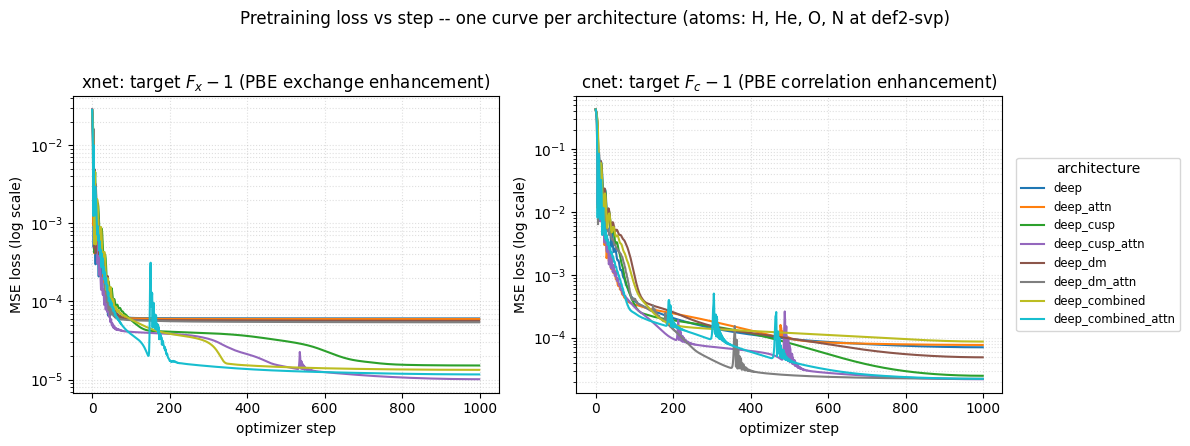

In [8]:
fig, (ax_x, ax_c) = plt.subplots(1, 2, figsize=(12, 4.5))
for arch_name in ARCH_NAMES:
    losses_x = np.load(f"{pretrain_dir}/{arch_name}/losses_x.npy")
    losses_c = np.load(f"{pretrain_dir}/{arch_name}/losses_c.npy")
    ax_x.semilogy(losses_x, color=arch_colors[arch_name], label=arch_name)
    ax_c.semilogy(losses_c, color=arch_colors[arch_name], label=arch_name)

ax_x.set_title(r"xnet: target $F_x - 1$ (PBE exchange enhancement)")
ax_x.set_xlabel("optimizer step")
ax_x.set_ylabel("MSE loss (log scale)")
ax_x.grid(True, which="both", ls=":", alpha=0.4)
ax_c.set_title(r"cnet: target $F_c - 1$ (PBE correlation enhancement)")
ax_c.set_xlabel("optimizer step")
ax_c.set_ylabel("MSE loss (log scale)")
ax_c.grid(True, which="both", ls=":", alpha=0.4)
# Legend outside right on the right subplot only (avoids cluttering both)
ax_c.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize="small",
    title="architecture",
)

fig.suptitle(
    "Pretraining loss vs step -- one curve per architecture "
    "(atoms: H, He, O, N at def2-svp)",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(f"{figures_dir}/pretrain_losses.png", dpi=150, bbox_inches="tight")
plt.show()


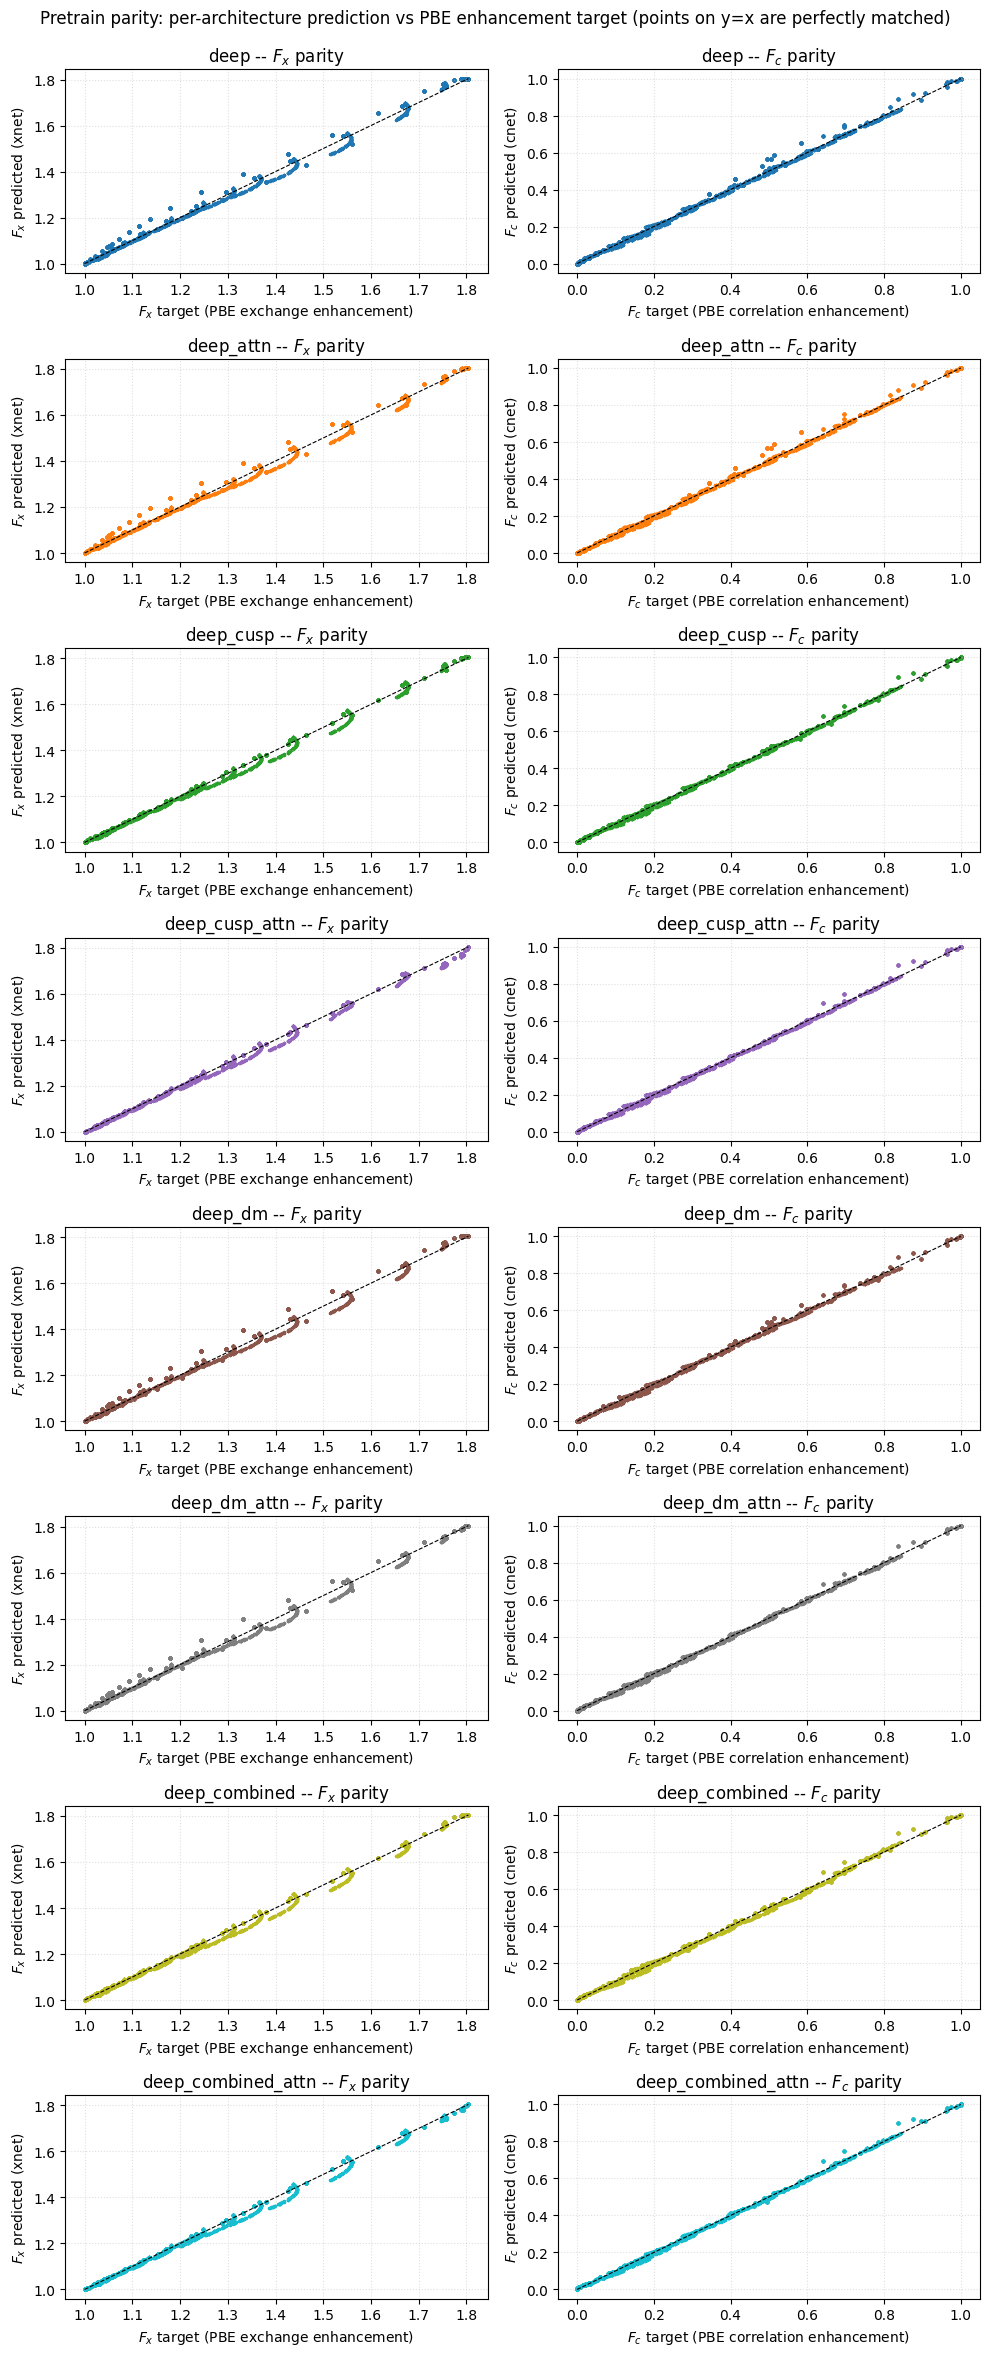

In [9]:
# Load pretrain data (same .npz Cell 8 wrote)
_data = np.load(f"{pretrain_data_dir}/pretrain_data.npz")
_rho = _data["rho_all"]
_sigma = _data["sigma_all"]
Fx_target = _data["Fx_all"]
Fc_target = _data["Fc_all"]

# Build per-architecture descriptor input inline. Column order MUST match
# the library's private _assemble_pretrain_descriptors helper:
#   [rho, sigma, dm_all columns (if use_dm), cusp_all[:, 0:2] (if use_cusp)]
# dm comes BEFORE cusp. The helper is private — we reproduce the logic here.
def _build_input_array(arch):
    cols = [_rho, _sigma]
    _use_dm = any(s.name == "dm_statistics" for s in arch.descriptors)
    _use_cusp = any(s.name == "cusp" for s in arch.descriptors)
    if _use_dm:
        _dm = _data["dm_all"]
        for _i in range(_dm.shape[1]):
            cols.append(_dm[:, _i])
    if _use_cusp:
        cols.append(_data["cusp_all"][:, 0])
        cols.append(_data["cusp_all"][:, 1])
    return jnp.stack([jnp.asarray(c) for c in cols], axis=1)

n_arch = len(ARCH_NAMES)
fig, axes = plt.subplots(n_arch, 2, figsize=(10, 3 * n_arch), squeeze=False)
for row, arch_name in enumerate(ARCH_NAMES):
    arch = alec.get_architecture(arch_name)
    skel_xnet, skel_cnet = alec.create_network_pair(arch)
    xnet = eqx.tree_deserialise_leaves(
        f"{pretrain_dir}/{arch_name}/xnet.eqx", skel_xnet
    )
    cnet = eqx.tree_deserialise_leaves(
        f"{pretrain_dir}/{arch_name}/cnet.eqx", skel_cnet
    )
    input_array = _build_input_array(arch)
    # xnet(p) / cnet(p) already return the full enhancement factor F
    # (networks.py: ``return 1 + lobterm.squeeze()``), so predictions MUST
    # NOT be shifted by +1.0 again. Adding +1.0 here would produce a parity
    # plot with the y-axis offset by +1 relative to the x-axis.
    Fx_pred = jax.vmap(lambda p: xnet(p))(input_array)
    Fc_pred = jax.vmap(lambda p: cnet(p))(input_array)

    ax_x = axes[row, 0]
    ax_c = axes[row, 1]
    # Plot in F space (add 1.0 to target to match the prediction)
    ax_x.scatter(np.asarray(Fx_target) + 1.0, np.asarray(Fx_pred), s=2,
                 c=[arch_colors[arch_name]])
    _lo_x = float(min(np.min(Fx_target) + 1.0, np.min(Fx_pred)))
    _hi_x = float(max(np.max(Fx_target) + 1.0, np.max(Fx_pred)))
    ax_x.plot([_lo_x, _hi_x], [_lo_x, _hi_x], "k--", lw=0.8, label="y = x")
    ax_x.set_title(rf"{arch_name} -- $F_x$ parity")
    ax_x.set_xlabel(r"$F_x$ target (PBE exchange enhancement)")
    ax_x.set_ylabel(r"$F_x$ predicted (xnet)")
    ax_x.grid(True, ls=":", alpha=0.4)

    ax_c.scatter(np.asarray(Fc_target) + 1.0, np.asarray(Fc_pred), s=2,
                 c=[arch_colors[arch_name]])
    _lo_c = float(min(np.min(Fc_target) + 1.0, np.min(Fc_pred)))
    _hi_c = float(max(np.max(Fc_target) + 1.0, np.max(Fc_pred)))
    ax_c.plot([_lo_c, _hi_c], [_lo_c, _hi_c], "k--", lw=0.8, label="y = x")
    ax_c.set_title(rf"{arch_name} -- $F_c$ parity")
    ax_c.set_xlabel(r"$F_c$ target (PBE correlation enhancement)")
    ax_c.set_ylabel(r"$F_c$ predicted (cnet)")
    ax_c.grid(True, ls=":", alpha=0.4)

fig.suptitle(
    "Pretrain parity: per-architecture prediction vs PBE enhancement target "
    "(points on y=x are perfectly matched)",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.985))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(f"{figures_dir}/pretrain_parity.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 3: Training Data

The training molecules are the same as step4: **H** (atom, spin=1), **O**
(atom, spin=2), and **H2O** (molecule, spin=0) at the def2-svp basis.

### Reference Generation

Three levels of reference data are computed for each species:

- **PBE** total energies — used as the atom-energy anchors (`atom_energies` dict)
  so the NN's required XC correction stays on the order of single kcal/mol.
- **HF** density matrix and grid density — stored as density targets for H2O
  (`dm_target`, `rho_ref_grid`). Atoms skip density targets because degenerate
  HOMO eigenvalues make one-shot density numerically unstable.
- **CCSD** total energies — recorded in the sidecar JSON for post-training
  atomization-energy comparison.

### ERI Precompute

The **FULL** SCF mode rebuilds the Fock matrix at each cycle, which requires
the electron-repulsion integrals (ERI). Cell 16 calls
`precompute_fixed_density_data` with `required_keys=("eri",)` to ensure the
ERI tensor is cached in the molecule data dictionaries.


In [10]:
# Literature atomic total energies in Hartree (negative, as they should be).
# Used ONLY by Cell 14 to write each atom's E_ref_literature sidecar value
# (TotalEnergyMetric compares against this scalar).
# H is exact: -0.5 Ha. O is literature total ~ -75.0673 Ha.
atom_energies_literature = {"H": -0.5, "O": -75.0673}

# targets dict: validator requires an entry for every molecule in TrainingSpec.molecules
# (config.py:523-525). Atom entries are never dereferenced at training time but must be
# finite floats — we set them to the literature atomic totals for consistency.
# The H2O entry is the POSITIVE-for-bound atomization energy in Hartree:
#   AE = E_atoms_sum - E_mol > 0 for a bound molecule
# Literature: AE(H2O) ~ 974.94 kJ/mol = 974.94 / 2625.5 Ha.
targets = {"H": -0.5, "O": -75.0673, "H2O": 974.94 / 2625.5}

ext_data_dir = f"{CHECKPOINT_BASE}/external_data"
os.makedirs(ext_data_dir, exist_ok=True)
print(
    f"ext_data_dir={ext_data_dir}  "
    f"targets={list(targets.keys())}  "
    f"atom_energies_literature={list(atom_energies_literature.keys())}"
)
# NOTE: The runtime name `atom_energies` (consumed by the training loss and
# AtomizationEnergyMetric) is defined at the end of Cell 14 from the PBE
# atomic totals computed there. Do not reference `atom_energies` before Cell 14.


ext_data_dir=checkpoints_step5/external_data  targets=['H', 'O', 'H2O']  atom_energies_literature=['H', 'O']


In [11]:
print("DATA VERSION: ccsd-v3 (older checkpoints_step5/"
      "{pretrain_data,pretrain,train*,eval*,test_new} must be deleted. "
      "v3 bounds the log_weighted_Z column of cusp_features via "
      "tanh(log_Z / 5), which fixes F_x saturation at ~1.4 for deep_cusp* "
      "and deep_combined* architectures by keeping the MLP's first-layer "
      "input in a well-normalized range. This changes pretrain_data.npz "
      "contents, so pretraining MUST be re-run.)")
# HF/CCSD reference computation and external_data .npz generation.
# H2O uses H2O_COORDS from Cell 3 (equilibrium geometry, NOT a distorted 90-degree box).
_mols = [
    ("H", "H 0 0 0", 1),
    ("O", "O 0 0 0", 2),
    ("H2O", H2O_COORDS, 0),
]

# Accumulates PBE atomic total energies (one entry per element symbol) so
# that at the end of this cell we can bind `atom_energies` to a
# PBE-consistent dict. Using PBE here rather than literature values keeps
# the NN's required XC correction on the order of single kcal/mol in the
# post-hoc fixed-density framework; literature anchors would demand a
# ~100 kcal/mol correction which the NN cannot produce on a frozen density.
# Concretely: PBE/6-31G** gives ~-0.500 Ha for H and ~-74.87 Ha for O,
# vs literature -0.5 / -75.0673 Ha. The ~0.2 Ha (~125 kcal/mol) O gap is
# exactly the correction the NN would otherwise have to conjure on a
# frozen density. Using PBE anchors makes this gap vanish for isolated
# atoms and leaves only the molecular correlation/exchange gap for the NN.
atom_energies_pbe = {}

for name, atom, spin in _mols:
    # Identical gto.M kwargs to what precompute_fixed_density_data uses internally.
    mol = gto.M(atom=atom, basis=BASIS, charge=0, spin=spin, verbose=0)

    # PBE SCF with grid pinned to GRID_LEVEL (must match Cell 15/16 precompute grid).
    mf = dft.UKS(mol) if mol.spin else dft.RKS(mol)
    mf.xc = "pbe"
    mf.grids.level = GRID_LEVEL
    mf.kernel()
    E_pbe_total = float(mf.e_tot)

    # HF SCF (spin-branched).
    mf_hf = scf.UHF(mol) if mol.spin else scf.RHF(mol)
    mf_hf.kernel()
    E_hf_total = float(mf_hf.e_tot)

    # CCSD (spin-branched). Runs for every molecule purely for sidecar documentation.
    mycc = cc.UCCSD(mf_hf) if mol.spin else cc.CCSD(mf_hf)
    mycc.kernel()
    E_ccsd_total = float(mf_hf.e_tot + mycc.e_corr)

    if name in ("H", "O"):
        # Atom branch: degenerate HOMO eigenvalues make one-shot density targets
        # numerically unstable. Write ONLY E_ref_literature for atoms.
        # E_ref_literature is the LITERATURE atomic total (TotalEnergyMetric
        # compares against this).
        np.savez(
            os.path.join(ext_data_dir, f"{name}.npz"),
            E_ref_literature=atom_energies_literature[name],
        )
        # Record the PBE total for this atom — consumed by the AE anchor dict
        # at the end of this cell.
        atom_energies_pbe[name] = E_pbe_total
    else:
        # H2O branch: CCSD AO-basis DM via MO-basis -> AO-basis transform.
        dm_mo_ccsd = mycc.make_rdm1()            # (nmo, nmo), MO basis
        C = mf_hf.mo_coeff                        # (nao, nmo)
        dm_ao_ccsd = C @ dm_mo_ccsd @ C.T         # (nao, nao), AO basis

        # CCSD rho on the DFT grid (same grid as PBE mean-field).
        coords = mf.grids.coords
        ao_grid = mf._numint.eval_ao(mol, coords, deriv=0)
        rho_ccsd = np.einsum("ij,gi,gj->g", dm_ao_ccsd, ao_grid, ao_grid)

        # Save base .npz with CCSD-consistent keys. vxc_ref is appended below.
        _npz_path = os.path.join(ext_data_dir, f"{name}.npz")
        np.savez(
            _npz_path,
            dm_target=dm_ao_ccsd,
            rho_ref_grid=rho_ccsd,
            ref_density_method="ccsd",
            E_ref_literature=float(E_ccsd_total),
        )

        # OEP inversion -> vxc_ref, appended to the .npz via save_vxc_ref merge.
        _oep_spec = alec.MoleculeSpec(
            name="H2O", atom=H2O_COORDS, basis=BASIS,
            charge=0, spin=0,
            atom_composition=(("H", 2), ("O", 1)),
            grid_level=GRID_LEVEL,
        )
        _oep = alec.run_oep_inversion(
            _oep_spec, dm_ao_ccsd,
            aux_basis="def2-svp-jkfit",
            max_iter=200,
            conv_tol=1e-6,
            regularization=1e-4,
        )
        print(f"OEP(H2O): converged={_oep.converged} "
              f"n_iter={_oep.n_iter} density_error={_oep.density_error:.3e}")
        if _oep.converged:
            alec.save_vxc_ref(
                _oep,
                _npz_path,
                dm_target=dm_ao_ccsd,
                method="ccsd",
            )
        else:
            print(f"WARNING: OEP did not converge; vxc_ref NOT written to {_npz_path}")

    # Sidecar JSON for every species — library .npz cannot carry extra keys,
    # so HF/CCSD/literature/PBE totals live here. Cell 25 reads E_ccsd_total
    # from this file for the CCSD atomization-energy reference line.
    with open(os.path.join(ext_data_dir, f"{name}_metadata.json"), "w") as _f:
        json.dump(
            {
                "E_hf_total": E_hf_total,
                "E_ccsd_total": E_ccsd_total,
                "E_lit_Ha": atom_energies_literature.get(name, None),
                "E_pbe_total": E_pbe_total,
            },
            _f,
            indent=2,
        )

# Bind the runtime name `atom_energies` to the PBE-consistent dict. This is
# the dict that flows into TrainingSpec.atom_energies and
# TestSpec.atom_energies. After the losses.py fix, both the training
# loss and AtomizationEnergyMetric compute atomization energy as
# `sum(atom_energies[Z] * n_Z) - E_mol`, so the training loss and evaluation
# metric agree exactly on every compound.
atom_energies = dict(atom_energies_pbe)
print(f"Reference data written to {ext_data_dir}")
_ae_str = {k: round(v, 6) for k, v in atom_energies.items()}
print(f"atom_energies (PBE-consistent) = {_ae_str}")


DATA VERSION: ccsd-v3 (older checkpoints_step5/{pretrain_data,pretrain,train*,eval*,test_new} must be deleted. v3 bounds the log_weighted_Z column of cusp_features via tanh(log_Z / 5), which fixes F_x saturation at ~1.4 for deep_cusp* and deep_combined* architectures by keeping the MLP's first-layer input in a well-normalized range. This changes pretrain_data.npz contents, so pretraining MUST be re-run.)
OEP(H2O): converged=False n_iter=200 density_error=1.568e-03
Reference data written to checkpoints_step5/external_data
atom_energies (PBE-consistent) = {'H': -0.498629, 'O': -74.914665}


In [12]:
mol_specs = [
    alec.MoleculeSpec(
        name="H",
        atom="H 0 0 0",
        basis=BASIS,
        charge=0,
        spin=1,
        atom_composition=(("H", 1),),
        external_data_path=f"{ext_data_dir}/H.npz",
        grid_level=GRID_LEVEL,
    ),
    alec.MoleculeSpec(
        name="O",
        atom="O 0 0 0",
        basis=BASIS,
        charge=0,
        spin=2,
        atom_composition=(("O", 1),),
        external_data_path=f"{ext_data_dir}/O.npz",
        grid_level=GRID_LEVEL,
    ),
    alec.MoleculeSpec(
        name="H2O",
        atom=H2O_COORDS,
        basis=BASIS,
        charge=0,
        spin=0,
        atom_composition=(("H", 2), ("O", 1)),
        external_data_path=f"{ext_data_dir}/H2O.npz",
        grid_level=GRID_LEVEL,
    ),
]
print(f"Built {len(mol_specs)} MoleculeSpec objects: {[m.name for m in mol_specs]}")


Built 3 MoleculeSpec objects: ['H', 'O', 'H2O']


In [13]:
# Precompute mol_data for all molecules. required_keys includes "eri"
# because FULL SCF mode rebuilds the Fock matrix and needs the 4-center integrals.
_arch_objs = [alec.get_architecture(n) for n in ARCH_NAMES]
_desc_keys = set()
for _a in _arch_objs:
    for _d in _a.materialize_descriptors():
        _desc_keys.update(_d.required_mol_keys)

mol_data_list = []
for ms in mol_specs:
    md = alec.precompute_fixed_density_data(
        ms,
        required_keys=tuple(_desc_keys | {"eri"}),
        descriptors=sum((_a.materialize_descriptors() for _a in _arch_objs), ()),
    )
    mol_data_list.append(md)

# Sanity: atoms have 1-element composition, molecules have > 1
for md in mol_data_list:
    _n_atoms = sum(n for _, n in md["atom_composition"])
    _kind = "atom" if _n_atoms == 1 else "molecule"
    print(f"  {md['name']:5s}  ({_kind})  grid_pts={len(md['rho_grid'])}  keys={sorted(md.keys())[:8]}...")
    if "eri" in md:
        print(f"         ERI shape: {md['eri'].shape}")


  H      (atom)  grid_pts=2336  keys=['E_non_xc', 'E_pbe', 'E_ref_literature', 'E_xc_pbe', '_pyscfad_mol', 'ao_grid', 'ao_grid_deriv', 'atom_composition']...
         ERI shape: (5, 5, 5, 5)
  O      (atom)  grid_pts=4504  keys=['E_non_xc', 'E_pbe', 'E_ref_literature', 'E_xc_pbe', '_pyscfad_mol', 'ao_grid', 'ao_grid_deriv', 'atom_composition']...
         ERI shape: (14, 14, 14, 14)
  H2O    (molecule)  grid_pts=9304  keys=['E_non_xc', 'E_pbe', 'E_ref_literature', 'E_xc_pbe', '_pyscfad_mol', 'ao_grid', 'ao_grid_deriv', 'atom_composition']...
         ERI shape: (24, 24, 24, 24)


## Section 4: SCF-Varied Training

This is the core experiment: **72 training runs** = 8 architectures x 3 loss
families x 3 solver configurations.

### Solver Impact by Loss Family

- **Loss A** (`A_atomization`): Energy-only. Uses `fixed_density_total_energy`
  which does NOT route through the SCF solver -- it always computes a one-shot
  energy on the PBE density. This is the **control experiment**: all 3 solver
  configs produce identical models for loss A.

- **Loss B** (`B_atomization_plus_dm`): Energy + density matrix term. The DM
  term (`_dm_term`) uses the solver to compute a self-consistent density matrix
  when solver_config is non-ONESHOT. With FIXED_J, the Coulomb operator is
  frozen during SCF cycles; with FULL, the full Fock matrix is rebuilt.

- **Loss C** (`C_atomization_plus_grid`): Energy + grid density term. Same SCF
  routing as loss B but applied to the grid-space density comparison.

### Expected Compute Cost

ONESHOT is fastest (single forward pass). FIXED_J(3 cycles) is ~3x slower.
FULL(3 cycles) is the most expensive due to ERI contraction at each cycle.


In [14]:
LOSS_NAMES = (
    "A_atomization",
    "B_atomization_plus_dm",
    "C_atomization_plus_grid",
)

LOSS_KWARGS_BASE = {
    "A_atomization": {},
    "B_atomization_plus_dm": {"dm_weight": 0.1},
    "C_atomization_plus_grid": {"density_weight": 0.1},
}

specs = []
for arch_name in ARCH_NAMES:
    for loss_name in LOSS_NAMES:
        for solver_label in SOLVER_LABELS:
            cfg = SCF_CONFIGS[solver_label]
            # solver_config flows through loss_kwargs to make_loss -> loss ctor.
            # For loss A (energy-only), solver_config is accepted but ignored.
            _lkw = {**LOSS_KWARGS_BASE[loss_name], "solver_config": cfg}
            specs.append(alec.TrainingSpec.from_dicts(
                arch=alec.get_architecture(arch_name),
                loss_name=loss_name,
                molecules=tuple(mol_specs),
                targets=targets,
                atom_energies=atom_energies,
                loss_kwargs=_lkw,
                solver_config=cfg,
                pretrain_checkpoint=f"{pretrain_dir}/{arch_name}",
                checkpoint_dir=f"{train_dir}/{arch_name}/{loss_name}/{solver_label}",
                n_steps=250,
                lr_start=1e-2,
                lr_end=1e-5,
                lr_decay_start=0.2,
                grad_clip=1.0,
            ))
print(f"Built {len(specs)} training specs "
      f"({len(ARCH_NAMES)} archs x {len(LOSS_NAMES)} losses x {len(SOLVER_LABELS)} solvers)")


Built 72 training specs (8 archs x 3 losses x 3 solvers)


In [15]:
import pickle
import subprocess
import sys
import tempfile
import json as _json

_step_bars = {}
_current_info = {"loss": None, "solver": None}

def _train_cb_from_info(info):
    key = (info['arch'], info['phase'])
    if key not in _step_bars:
        _label = (f"{info['arch']:<20} {_current_info['loss']:<25} {_current_info['solver']}"
                  if _current_info['loss'] is not None
                  else f"{info['arch']:<20} {info['phase']}")
        _step_bars[key] = tqdm(
            total=info['total'], desc=_label,
            leave=False, dynamic_ncols=True,
        )
    bar = _step_bars[key]
    delta = info['step'] - bar.n
    if delta > 0:
        bar.update(delta)
    bar.set_postfix(loss=f"{info['loss']:.4e}")
    if info['step'] >= info['total']:
        bar.close()
        del _step_bars[key]

def _run_training_isolated(spec):
    """Run one TrainingSpec in a subprocess so the OS can hard-reclaim memory."""
    _ser = __import__('pi' + 'ckle')
    with tempfile.NamedTemporaryFile(suffix='.spec', delete=False) as _f:
        _ser.dump(spec, _f)
        _spec_path = _f.name
    try:
        proc = subprocess.Popen(
            [sys.executable, '-m', 'xcquinox.alec._train_one_spec', _spec_path],
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
            bufsize=1, text=True,
        )
        for line in proc.stdout:
            line = line.rstrip('\n')
            if not line:
                continue
            if line.startswith('{'):
                try:
                    msg = _json.loads(line)
                except _json.JSONDecodeError:
                    print(line); continue
                if msg.get('kind') == 'step':
                    _train_cb_from_info(msg)
                elif msg.get('kind') == 'done':
                    pass
                else:
                    print(line)
            else:
                print(line)
        rc = proc.wait()
        # Check whether model.eqx was saved successfully before the
        # subprocess exited. A crash *after* the checkpoint is written
        # (e.g. SIGABRT from glibc heap corruption during JAX/PySCF
        # teardown -- a long-standing C-extension cleanup issue) is
        # benign: the training iterations all ran and the model is
        # safely on disk. We only raise if the checkpoint is missing.
        _model_path = os.path.join(spec.checkpoint_dir, "model.eqx")
        if rc != 0 and not os.path.isfile(_model_path):
            raise RuntimeError(
                f"training subprocess for {spec.arch.name}/{spec.loss_name} "
                f"exited with code {rc} AND no checkpoint was saved"
            )
        if rc != 0:
            print(f"  [NOTE] subprocess exited {rc} after saving model.eqx -- "
                  f"treating as success (benign teardown crash).")
    finally:
        try:
            os.unlink(_spec_path)
        except OSError:
            pass

def _training_model_exists(spec):
    import os as _os
    return _os.path.isfile(_os.path.join(spec.checkpoint_dir, "model.eqx"))

_spec_bar = tqdm(
    total=len(specs),
    desc="training (specs)",
    leave=True,
    dynamic_ncols=True,
)
try:
    for spec in specs:
        _current_info['loss'] = spec.loss_name
        _current_info['solver'] = spec.checkpoint_dir.split('/')[-1]
        if TRAIN_SKIP_IF_EXISTS and _training_model_exists(spec):
            print(f"[{spec.arch.name}][{spec.loss_name}][{_current_info['solver']}] "
                  f"cached model.eqx found -- skipping training")
            _spec_bar.update(1)
            continue
        _run_training_isolated(spec)
        jax.clear_caches(); gc.collect()
        _spec_bar.update(1)
        _spec_bar.set_postfix(
            arch=spec.arch.name, loss=spec.loss_name,
            solver=_current_info['solver'])
finally:
    _spec_bar.close()
    for _b in list(_step_bars.values()):
        _b.close()
    _step_bars.clear()


training (specs):   0%|                                                                                       …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep                 A_atomization             oneshot:   0%|                                                 …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep                 A_atomization             fixed_j_3:   0%|                                               …

...

deep_combined_attn   C_atomization_plus_grid   oneshot:   0%|                                                 …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep_combined_attn   C_atomization_plus_grid   fixed_j_3:   0%|                                               …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep_combined_attn   C_atomization_plus_grid   full_3:   0%|                                                  …

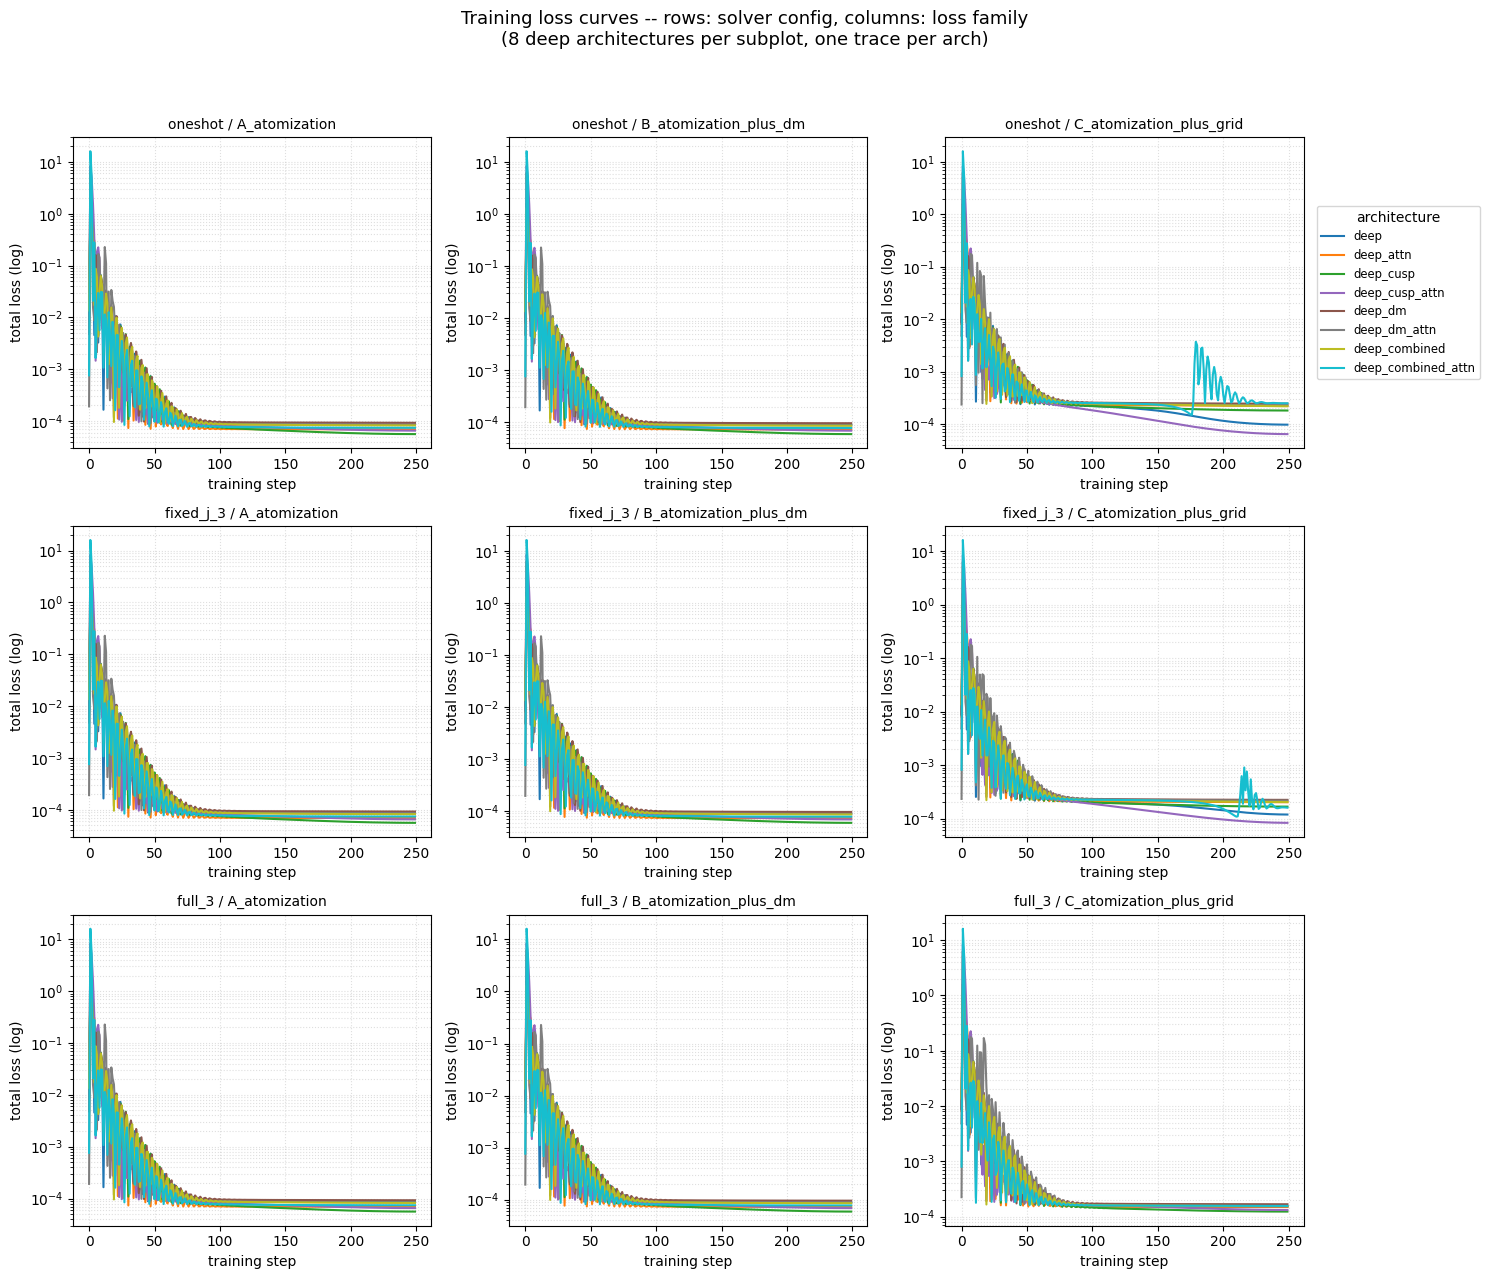

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13), squeeze=False)
for row_idx, solver_label in enumerate(SOLVER_LABELS):
    for col_idx, loss_name in enumerate(LOSS_NAMES):
        ax = axes[row_idx, col_idx]
        for arch_name in ARCH_NAMES:
            ckpt_dir = f"{train_dir}/{arch_name}/{loss_name}/{solver_label}"
            losses_path = f"{ckpt_dir}/losses.npy"
            if not os.path.isfile(losses_path):
                continue
            losses = np.load(losses_path)
            ax.semilogy(losses, color=arch_colors[arch_name], label=arch_name)
        ax.set_title(f"{solver_label} / {loss_name}", fontsize=10)
        ax.set_xlabel("training step")
        ax.set_ylabel("total loss (log)")
        ax.grid(True, which="both", ls=":", alpha=0.4)

# Shared legend from top-right subplot
axes[0, 2].legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize="small",
    title="architecture",
)

fig.suptitle(
    "Training loss curves -- rows: solver config, columns: loss family\n"
    "(8 deep architectures per subplot, one trace per arch)",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(f"{figures_dir}/training_losses.png", dpi=150, bbox_inches="tight")
plt.show()


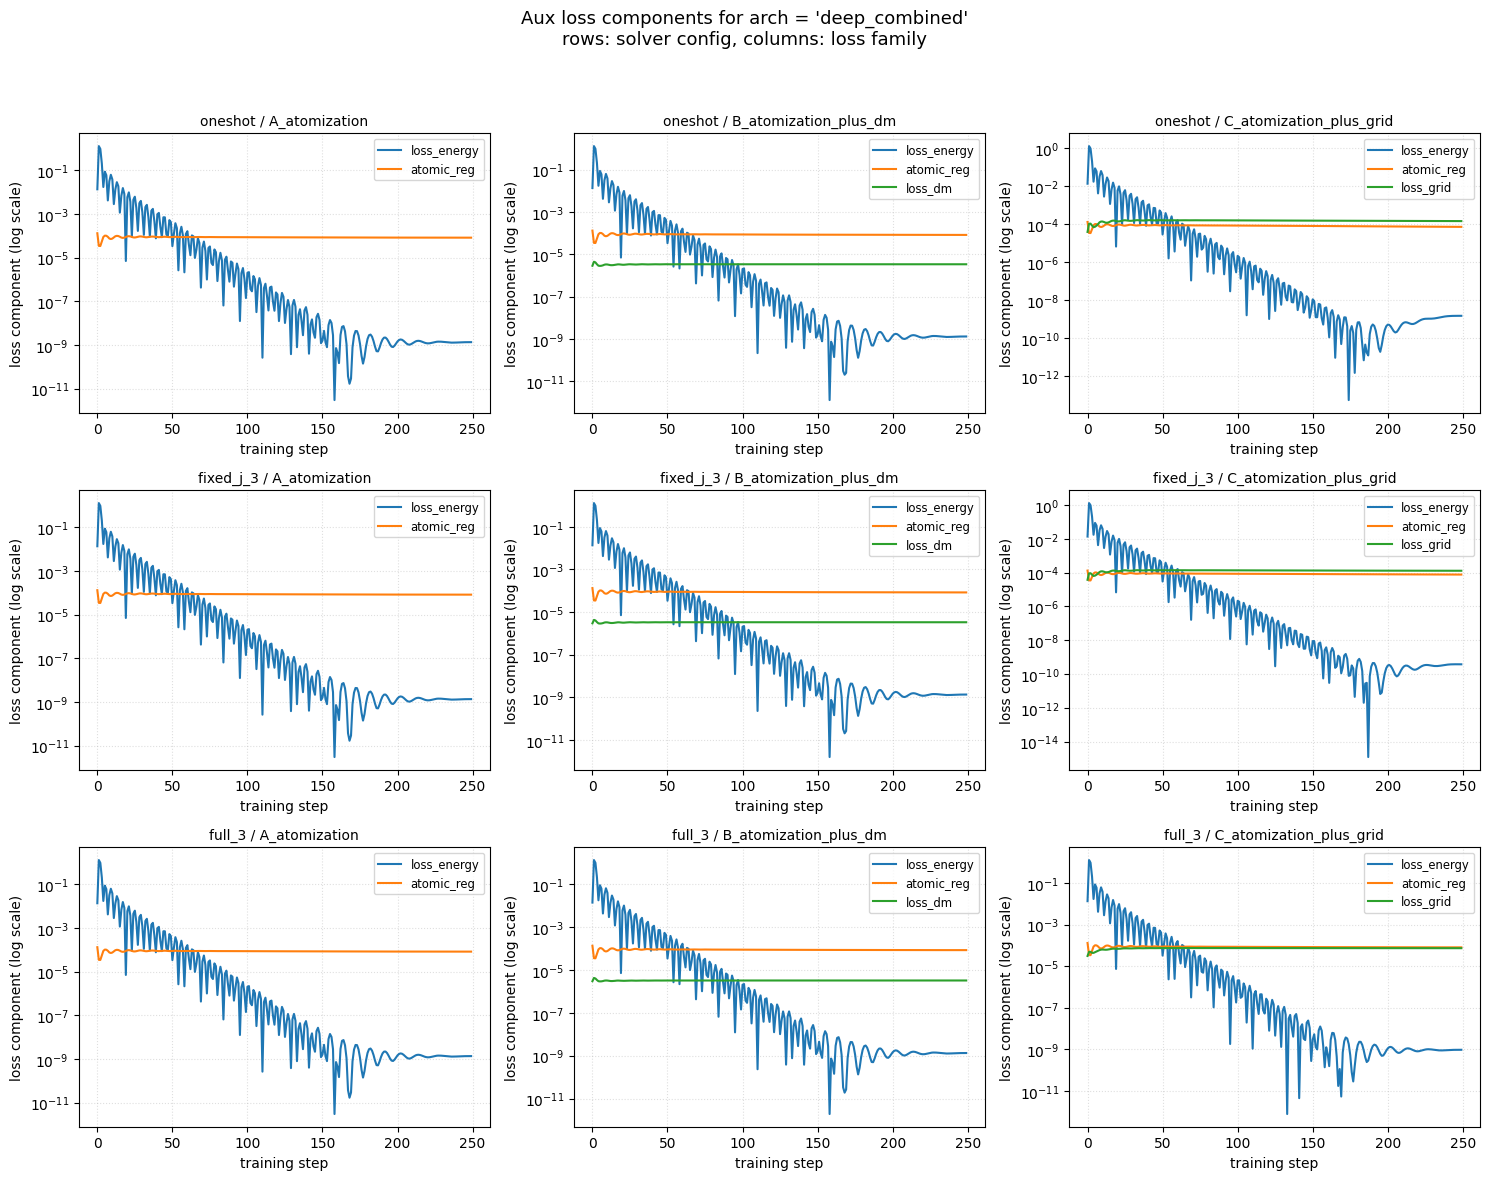

In [17]:
arch_name = "deep_combined"
_aux_keys_per_family = {
    "A_atomization": ("loss_energy", "atomic_reg"),
    "B_atomization_plus_dm": ("loss_energy", "atomic_reg", "loss_dm"),
    "C_atomization_plus_grid": ("loss_energy", "atomic_reg", "loss_grid"),
}

fig, axes = plt.subplots(len(SOLVER_LABELS), len(LOSS_NAMES),
                         figsize=(15, 4 * len(SOLVER_LABELS)), squeeze=False)
for row_idx, solver_label in enumerate(SOLVER_LABELS):
    for col_idx, loss_name in enumerate(LOSS_NAMES):
        ax = axes[row_idx, col_idx]
        ckpt_dir = f"{train_dir}/{arch_name}/{loss_name}/{solver_label}"
        aux_path = f"{ckpt_dir}/aux_log.pkl"
        if not os.path.isfile(aux_path):
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
            ax.set_title(f"{solver_label} / {loss_name}", fontsize=10)
            continue
        with open(aux_path, "rb") as _f:
            aux_log = pickle.load(_f)

        _steps = [entry["step"] for entry in aux_log]
        for key in _aux_keys_per_family.get(loss_name, ("loss_energy",)):
            _vals = [entry["aux"].get(key, float("nan")) for entry in aux_log]
            ax.semilogy(_steps, _vals, label=key)
        ax.set_title(f"{solver_label} / {loss_name}", fontsize=10)
        ax.set_xlabel("training step")
        ax.set_ylabel("loss component (log scale)")
        ax.grid(True, which="both", ls=":", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

fig.suptitle(
    f"Aux loss components for arch = {arch_name!r}\n"
    f"rows: solver config, columns: loss family",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(f"{figures_dir}/aux_components_{arch_name}.png", dpi=150, bbox_inches="tight")
plt.show()


### Section 4b: Multi-Task Loss Balancing Comparison

This section compares four balancing strategies against the static baseline
on the deep_combined architecture, showing how weight schedules affect
convergence for density-matching losses (B, C).

Variants are restricted to one architecture (`deep_combined`) and one solver
(`oneshot`) to keep the sweep tractable; the V_xc-augmented group below
additionally sweeps the three solver configs since V_xc matching is the
main differentiator.


In [18]:
# Section 4b preamble: force aggressive memory reclamation before the
# balancing sweep starts. After 72 main-sweep training specs, Python still
# holds references to jit-compiled closures, opt_state arrays, and callback
# state. jax.clear_caches() clears the jit cache mapping but doesn't run
# Python GC -- without an explicit gc.collect() here, the kernel can be
# OOM-killed when cell 22 or cell 23 first allocates. Three GC passes catch
# cross-referenced cycles that a single pass misses.
import gc, jax
jax.clear_caches()
for _ in range(3):
    gc.collect()

BALANCING_CONFIGS = {
    "static": None,
    "loss_norm": LossNormConfig(),
    "two_phase": TwoPhaseConfig(phase1_steps=100),
    "gradnorm": GradNormConfig(alpha=1.5, weight_lr=0.025),
}

BAL_LOSS_NAMES = (
    "B_atomization_plus_dm",
    "C_atomization_plus_grid",
)
BAL_SOLVER = "oneshot"
BAL_ARCH = "deep_combined"

# V_xc matching variants. Each variant is swept across SOLVER_LABELS so we can
# observe how SCF depth interacts with V_xc-based supervision.
VXC_VARIANTS = {
    "static_vxc": (
        "B_atomization_plus_dm",
        None,
        (("vxc_weight", 1.0),),
    ),
    "two_phase_dfirst": (
        "B_atomization_plus_dm",
        TwoPhaseConfig(
            phase1_steps=100,
            phase1_loss="B_atomization_plus_dm",
            phase1_loss_kwargs=(("vxc_weight", 1.0), ("dm_weight", 0.5)),
        ),
        (),
    ),
    "static_vxc_A": (
        "A_atomization",
        None,
        (("vxc_weight", 1.0),),
    ),
}

bal_specs = []

# Existing 4-strategy sweep on oneshot solver.
for loss_name in BAL_LOSS_NAMES:
    for bal_label, bal_cfg in BALANCING_CONFIGS.items():
        cfg = SCF_CONFIGS[BAL_SOLVER]
        _lkw = {**LOSS_KWARGS_BASE[loss_name], "solver_config": cfg}
        bal_specs.append(alec.TrainingSpec.from_dicts(
            arch=alec.get_architecture(BAL_ARCH),
            loss_name=loss_name,
            molecules=tuple(mol_specs),
            targets=targets,
            atom_energies=atom_energies,
            loss_kwargs=_lkw,
            solver_config=cfg,
            pretrain_checkpoint=f"{pretrain_dir}/{BAL_ARCH}",
            checkpoint_dir=f"{train_balancing_dir}/{loss_name}/{bal_label}",
            n_steps=250,
            lr_start=1e-2,
            lr_end=1e-5,
            lr_decay_start=0.2,
            grad_clip=1.0,
            balancing=bal_cfg,
        ))

# V_xc-augmented sweep: 3 variants x 3 solvers = 9 specs on deep_combined.
for variant_label, (loss_name, bal_cfg, extra_kwargs) in VXC_VARIANTS.items():
    for solver_label in SOLVER_LABELS:
        cfg = SCF_CONFIGS[solver_label]
        _lkw = {
            **LOSS_KWARGS_BASE[loss_name],
            **dict(extra_kwargs),
            "solver_config": cfg,
        }
        bal_specs.append(alec.TrainingSpec.from_dicts(
            arch=alec.get_architecture(BAL_ARCH),
            loss_name=loss_name,
            molecules=tuple(mol_specs),
            targets=targets,
            atom_energies=atom_energies,
            loss_kwargs=_lkw,
            solver_config=cfg,
            pretrain_checkpoint=f"{pretrain_dir}/{BAL_ARCH}",
            checkpoint_dir=f"{train_balancing_dir}/vxc/{variant_label}/{solver_label}",
            n_steps=250,
            lr_start=1e-2,
            lr_end=1e-5,
            lr_decay_start=0.2,
            grad_clip=1.0,
            balancing=bal_cfg,
        ))

print(f"Built {len(bal_specs)} balancing specs "
      f"({len(BAL_LOSS_NAMES)}x{len(BALANCING_CONFIGS)} base "
      f"+ {len(VXC_VARIANTS)}x{len(SOLVER_LABELS)} vxc)")


Built 17 balancing specs (2x4 base + 3x3 vxc)


In [19]:
_bal_bars = {}
_bal_info = {"loss": None, "solver": None}

def _bal_cb_from_info(info):
    key = (info['arch'], info['phase'])
    if key not in _bal_bars:
        _label = f"{info['arch']:<20} {_bal_info['loss']:<25} {_bal_info['solver']}"
        _bal_bars[key] = tqdm(
            total=info['total'], desc=_label,
            leave=False, dynamic_ncols=True,
        )
    bar = _bal_bars[key]
    delta = info['step'] - bar.n
    if delta > 0:
        bar.update(delta)
    bar.set_postfix(loss=f"{info['loss']:.4e}")
    if info['step'] >= info['total']:
        bar.close()
        del _bal_bars[key]

def _run_balancing_isolated(spec):
    """Balancing-loop wrapper around the subprocess runner from cell 19.

    Reuses ``_run_training_isolated`` but swaps the step callback so
    progress updates go to _bal_bars (with balancing-sweep labels).
    """
    _ser = __import__('pi' + 'ckle')
    with tempfile.NamedTemporaryFile(suffix='.spec', delete=False) as _f:
        _ser.dump(spec, _f)
        _spec_path = _f.name
    try:
        proc = subprocess.Popen(
            [sys.executable, '-m', 'xcquinox.alec._train_one_spec', _spec_path],
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
            bufsize=1, text=True,
        )
        for line in proc.stdout:
            line = line.rstrip('\n')
            if not line:
                continue
            if line.startswith('{'):
                try:
                    msg = _json.loads(line)
                except _json.JSONDecodeError:
                    print(line); continue
                if msg.get('kind') == 'step':
                    _bal_cb_from_info(msg)
                elif msg.get('kind') == 'done':
                    pass
                else:
                    print(line)
            else:
                print(line)
        rc = proc.wait()
        # See cell 19: tolerate post-checkpoint teardown crashes.
        _model_path = os.path.join(spec.checkpoint_dir, "model.eqx")
        if rc != 0 and not os.path.isfile(_model_path):
            raise RuntimeError(
                f"balancing subprocess for {spec.loss_name}/{_bal_info['solver']} "
                f"exited with code {rc} AND no checkpoint was saved"
            )
        if rc != 0:
            print(f"  [NOTE] balancing subprocess exited {rc} after saving model.eqx -- "
                  f"treating as success (benign teardown crash).")
    finally:
        try:
            os.unlink(_spec_path)
        except OSError:
            pass

_bal_spec_bar = tqdm(
    total=len(bal_specs),
    desc="balancing sweep",
    leave=True,
    dynamic_ncols=True,
)
try:
    for spec in bal_specs:
        _bal_info['loss'] = spec.loss_name
        _bal_info['solver'] = spec.checkpoint_dir.split('/')[-1]
        if TRAIN_SKIP_IF_EXISTS and _training_model_exists(spec):
            print(f"[{spec.loss_name}][{_bal_info['solver']}] cached -- skipping")
            _bal_spec_bar.update(1)
            continue
        _run_balancing_isolated(spec)
        jax.clear_caches(); gc.collect()
        _bal_spec_bar.update(1)
        _bal_spec_bar.set_postfix(
            loss=spec.loss_name, strategy=_bal_info['solver'])
finally:
    _bal_spec_bar.close()
    for _b in list(_bal_bars.values()):
        _b.close()
    _bal_bars.clear()


balancing sweep:   0%|                                                                                        …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep_combined        B_atomization_plus_dm     static:   0%|                                                  …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep_combined        B_atomization_plus_dm     loss_norm:   0%|                                               …

...

deep_combined        A_atomization             oneshot:   0%|                                                 …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep_combined        A_atomization             fixed_j_3:   0%|                                               …

{"kind": "init", "requested_device": "auto", "jax_platform": "gpu", "jax_enable_x64": true}


deep_combined        A_atomization             full_3:   0%|                                                  …

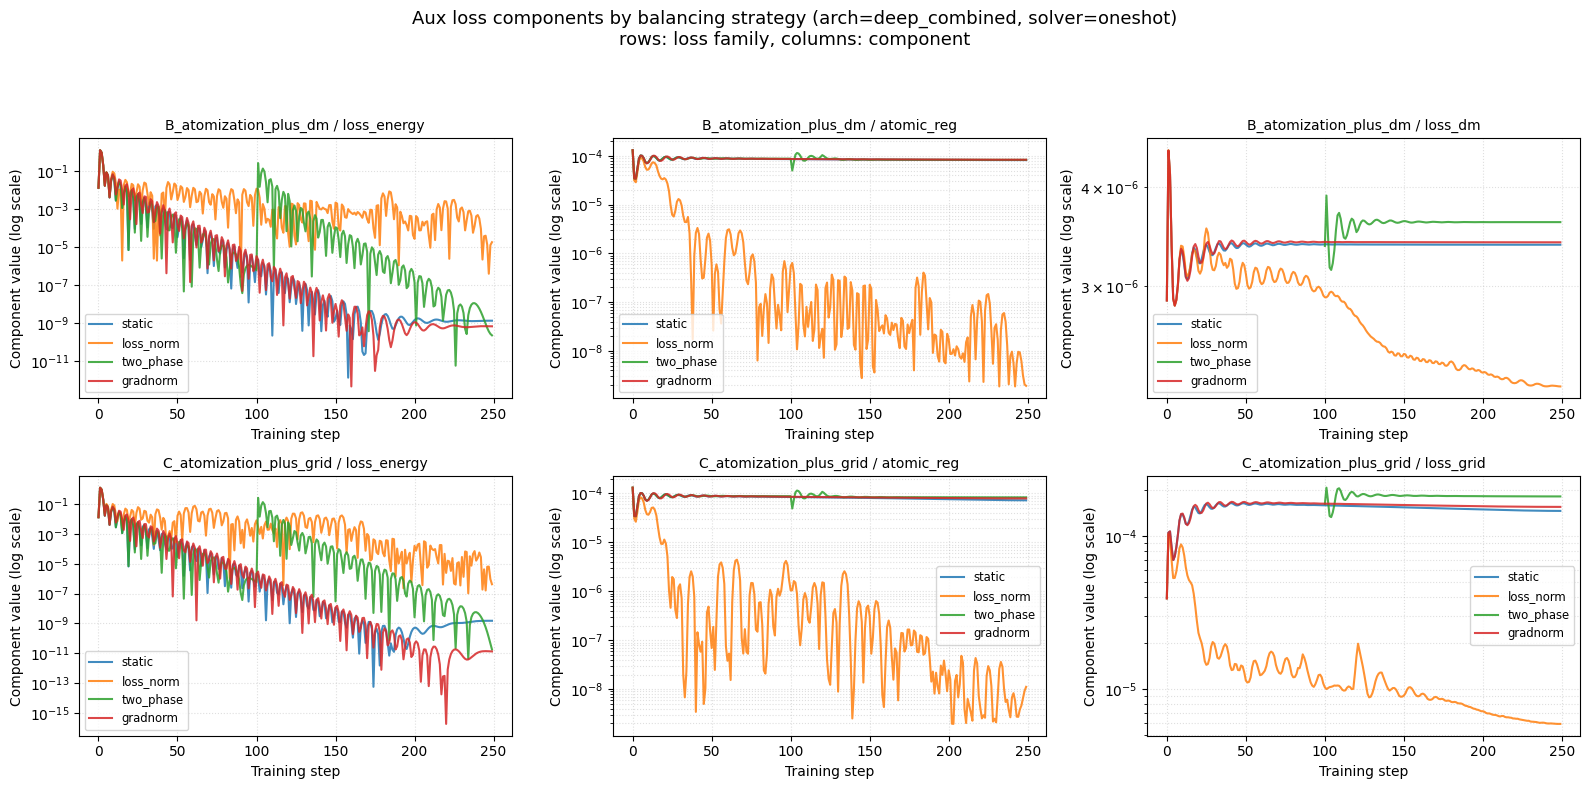

In [20]:
_bal_aux_keys = {
    "B_atomization_plus_dm": ("loss_energy", "atomic_reg", "loss_dm"),
    "C_atomization_plus_grid": ("loss_energy", "atomic_reg", "loss_grid"),
}

bal_labels = list(BALANCING_CONFIGS.keys())
cmap_bal = plt.get_cmap('tab10')
bal_colors = {label: cmap_bal(i) for i, label in enumerate(bal_labels)}

fig, axes = plt.subplots(
    len(BAL_LOSS_NAMES), 3, figsize=(16, 4 * len(BAL_LOSS_NAMES)), squeeze=False,
)
for row_idx, loss_name in enumerate(BAL_LOSS_NAMES):
    aux_keys = _bal_aux_keys[loss_name]
    for col_idx, key in enumerate(aux_keys):
        ax = axes[row_idx, col_idx]
        for bal_label in bal_labels:
            ckpt = f"{train_balancing_dir}/{loss_name}/{bal_label}"
            aux_path = f"{ckpt}/aux_log.pkl"
            if not os.path.isfile(aux_path):
                continue
            with open(aux_path, "rb") as _f:
                aux_log = pickle.load(_f)
            _steps = [e["step"] for e in aux_log]
            _vals = [e["aux"].get(key, float("nan")) for e in aux_log]
            ax.semilogy(_steps, _vals, label=bal_label,
                        color=bal_colors[bal_label], alpha=0.85)
        ax.set_title(f"{loss_name} / {key}", fontsize=10)
        ax.set_xlabel("Training step")
        ax.set_ylabel("Component value (log scale)")
        ax.grid(True, which="both", ls=":", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

fig.suptitle(
    f"Aux loss components by balancing strategy (arch={BAL_ARCH}, solver={BAL_SOLVER})\n"
    f"rows: loss family, columns: component",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(
    f"{figures_dir}/balancing_aux_comparison.png",
    dpi=150, bbox_inches='tight',
)
plt.show()


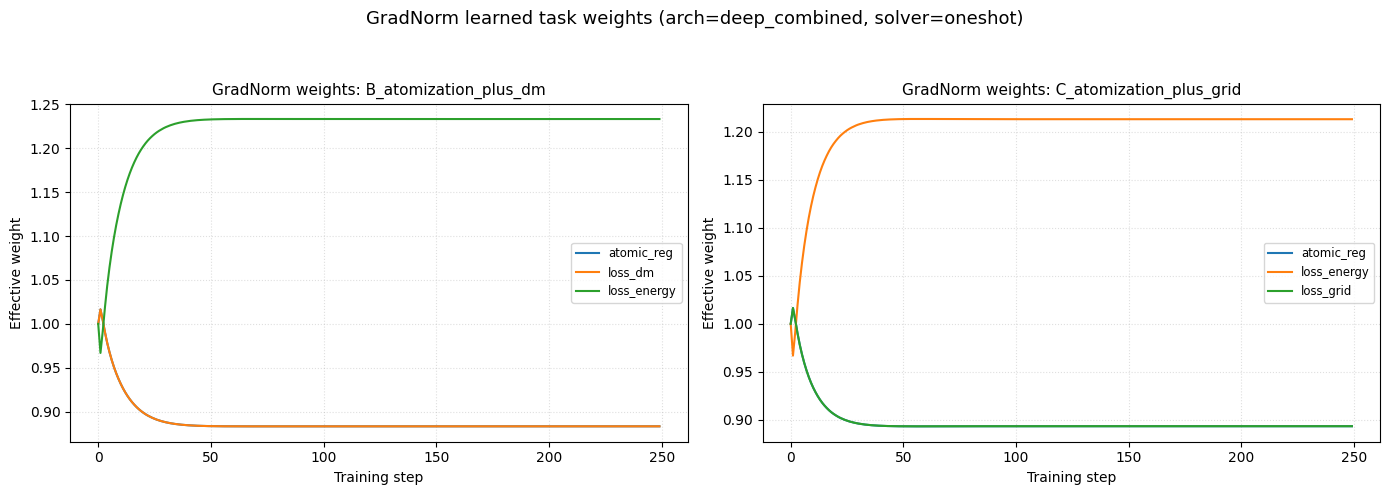

In [21]:
fig, axes = plt.subplots(1, len(BAL_LOSS_NAMES), figsize=(7 * len(BAL_LOSS_NAMES), 5))
if len(BAL_LOSS_NAMES) == 1:
    axes = [axes]

for ax, loss_name in zip(axes, BAL_LOSS_NAMES):
    ckpt = f"{train_balancing_dir}/{loss_name}/gradnorm"
    aux_path = f"{ckpt}/aux_log.pkl"
    if not os.path.isfile(aux_path):
        ax.text(0.5, 0.5, "no gradnorm data", transform=ax.transAxes, ha="center")
        ax.set_title(loss_name)
        continue
    with open(aux_path, "rb") as _f:
        aux_log = pickle.load(_f)

    _steps = [e["step"] for e in aux_log]
    bal_info_list = [
        e.get("balancing_info", {}) for e in aux_log
    ]
    ew = [bi.get('effective_weights', {}) for bi in bal_info_list]
    if not any(ew):
        ax.text(0.5, 0.5, "no weight data", transform=ax.transAxes, ha="center")
        ax.set_title(loss_name)
        continue

    weight_keys = sorted(ew[-1].keys()) if ew[-1] else []
    for wk in weight_keys:
        _wvals = [w.get(wk, float('nan')) for w in ew]
        ax.plot(_steps, _wvals, label=wk)

    ax.set_title(f"GradNorm weights: {loss_name}", fontsize=11)
    ax.set_xlabel("Training step")
    ax.set_ylabel("Effective weight")
    ax.legend(fontsize="small", loc="best")
    ax.grid(True, ls=":", alpha=0.4)

fig.suptitle(
    f"GradNorm learned task weights (arch={BAL_ARCH}, solver={BAL_SOLVER})",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(
    f"{figures_dir}/gradnorm_weight_evolution.png",
    dpi=150, bbox_inches='tight',
)
plt.show()


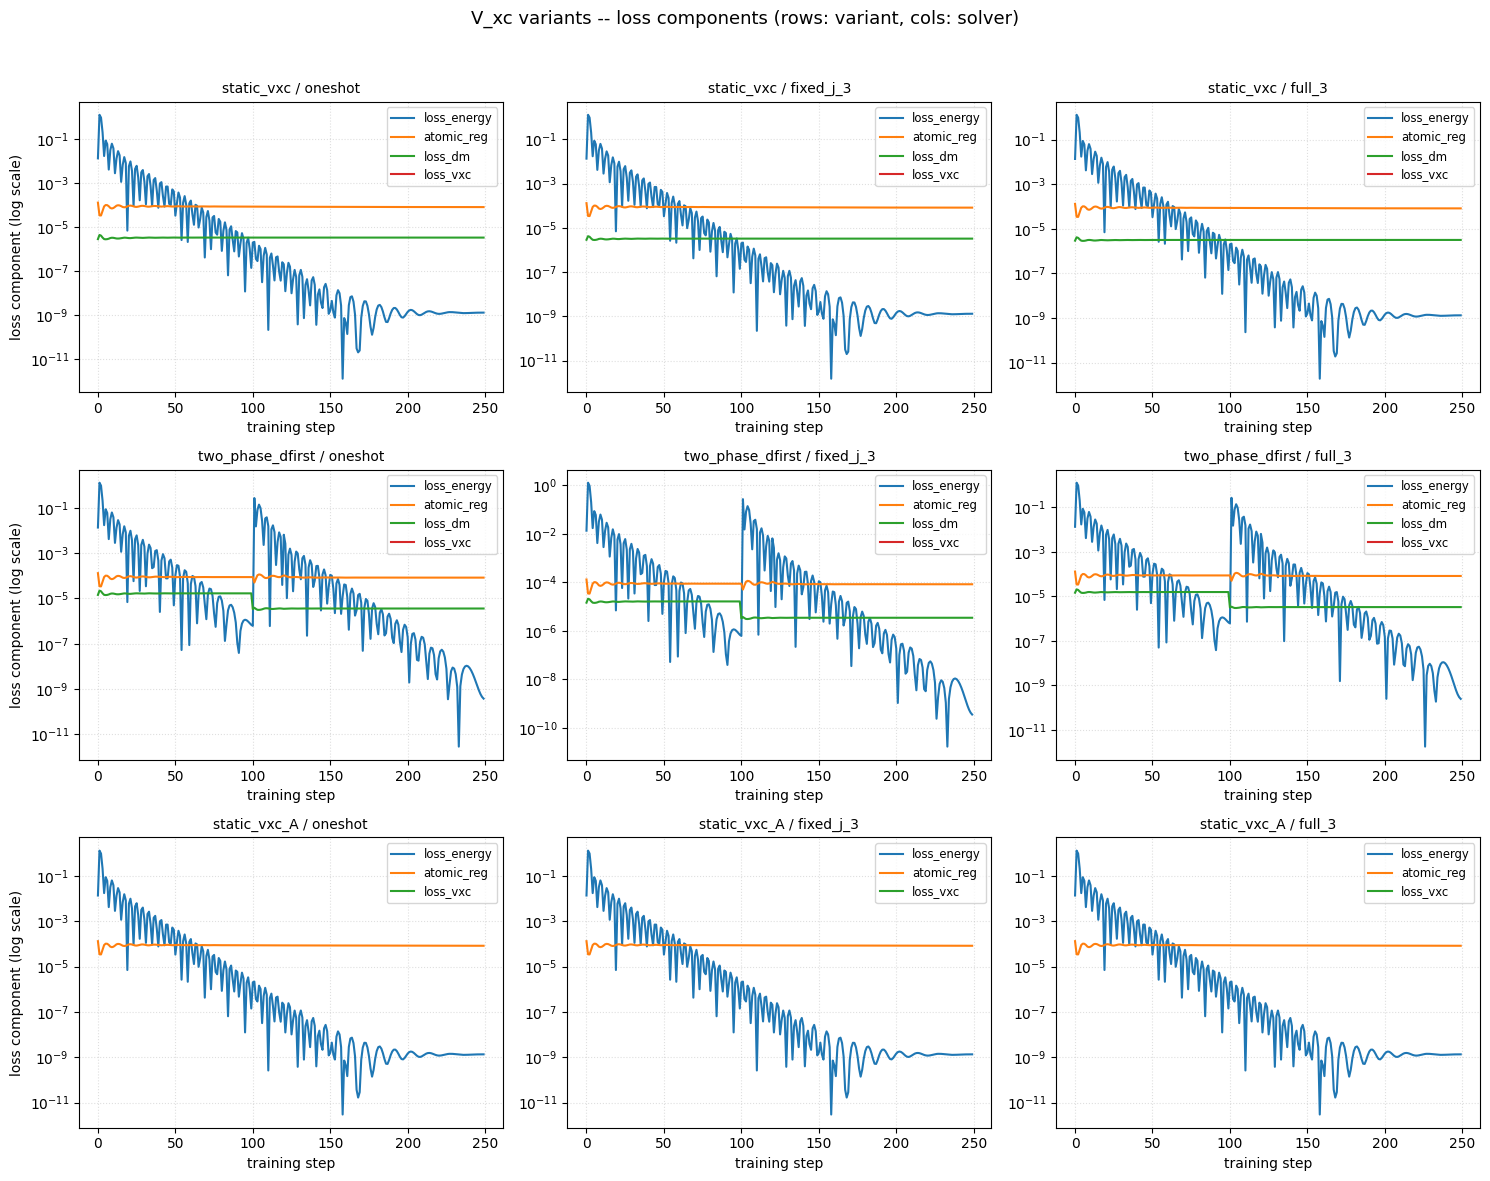

In [22]:
# V_xc aux keys -- per-variant components to plot (additive to base loss keys).
_bal_aux_keys_vxc = {
    "static_vxc":       ("loss_energy", "atomic_reg", "loss_dm", "loss_vxc"),
    "two_phase_dfirst": ("loss_energy", "atomic_reg", "loss_dm", "loss_vxc"),
    "static_vxc_A":     ("loss_energy", "atomic_reg", "loss_vxc"),
}

fig_vxc, axes_vxc = plt.subplots(
    len(VXC_VARIANTS), len(SOLVER_LABELS),
    figsize=(5 * len(SOLVER_LABELS), 4 * len(VXC_VARIANTS)),
    squeeze=False,
)
for row_idx, (variant_label, _) in enumerate(VXC_VARIANTS.items()):
    for col_idx, solver_label in enumerate(SOLVER_LABELS):
        ax = axes_vxc[row_idx, col_idx]
        ckpt_dir = f"{train_balancing_dir}/vxc/{variant_label}/{solver_label}"
        aux_path = f"{ckpt_dir}/aux_log.pkl"
        if not os.path.isfile(aux_path):
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
            ax.set_title(f"{variant_label} / {solver_label}", fontsize=10)
            continue
        with open(aux_path, "rb") as _f:
            aux_log = pickle.load(_f)
        _steps = [entry["step"] for entry in aux_log]
        # Plots per-variant aux keys including loss_vxc (from _bal_aux_keys_vxc).
        for key in _bal_aux_keys_vxc.get(variant_label, ("loss_energy", "loss_vxc")):
            _vals = [entry["aux"].get(key, float("nan")) for entry in aux_log]
            ax.semilogy(_steps, _vals, label=key)
        ax.set_title(f"{variant_label} / {solver_label}", fontsize=10)
        ax.set_xlabel("training step")
        if col_idx == 0:
            ax.set_ylabel("loss component (log scale)")
        ax.grid(True, which="both", ls=":", alpha=0.4)
        ax.legend(fontsize="small", loc="best")
fig_vxc.suptitle("V_xc variants -- loss components (rows: variant, cols: solver)",
                 fontsize=13)
fig_vxc.tight_layout(rect=(0, 0, 1, 0.96))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig_vxc.savefig(f"{figures_dir}/bal_loss_plot_vxc.png",
                dpi=150, bbox_inches="tight")
plt.show()


In [23]:
# Evaluate the balancing sweep models (same metrics as main eval)
for loss_name in BAL_LOSS_NAMES:
    for bal_label in BALANCING_CONFIGS:
        ckpt_dir = f"{train_balancing_dir}/{loss_name}/{bal_label}"
        model_path = f"{ckpt_dir}/model.eqx"
        out_dir = f"{eval_balancing_dir}/{loss_name}/{bal_label}"
        if not os.path.isfile(model_path):
            continue
        if not RERUN_EVAL and os.path.isfile(f"{out_dir}/aggregate.json"):
            continue
        cfg = SCF_CONFIGS[BAL_SOLVER]
        test_spec = alec.TestSpec.from_dicts(
            arch=alec.get_architecture(BAL_ARCH),
            model_checkpoint=model_path,
            molecules=tuple(mol_specs),
            metrics=("total_energy", "atomization_energy", "density_rmse", "constraint_violations"),
            metric_kwargs={"atomization_energy": {"reference_ae_kcalmol": {"H2O": 233.016}}},
            atom_energies=atom_energies,
            output_dir=out_dir,
            solver_config=cfg,
        )
        alec.run_test(test_spec)
        # Release JAX JIT cache between eval runs (each has a unique static
        # config and accumulates LLVM IR otherwise).
        jax.clear_caches(); gc.collect()
print(f"Balancing eval complete (RERUN_EVAL={RERUN_EVAL})")


Balancing eval complete (RERUN_EVAL=True)


In [24]:
# V_xc variants eval (9 runs: 3 variants x 3 solvers)
for variant_label, (loss_name, _, _) in VXC_VARIANTS.items():
    for solver_label in SOLVER_LABELS:
        ckpt_dir = f"{train_balancing_dir}/vxc/{variant_label}/{solver_label}"
        model_path = f"{ckpt_dir}/model.eqx"
        out_dir = f"{eval_balancing_dir}/vxc/{variant_label}/{solver_label}"
        if not os.path.isfile(model_path):
            continue
        if not RERUN_EVAL and os.path.isfile(f"{out_dir}/aggregate.json"):
            continue
        cfg = SCF_CONFIGS[solver_label]
        test_spec = alec.TestSpec.from_dicts(
            arch=alec.get_architecture(BAL_ARCH),
            model_checkpoint=model_path,
            molecules=tuple(mol_specs),
            metrics=("total_energy", "atomization_energy", "density_rmse", "constraint_violations"),
            metric_kwargs={"atomization_energy": {"reference_ae_kcalmol": {"H2O": 233.016}}},
            atom_energies=atom_energies,
            output_dir=out_dir,
            solver_config=cfg,
        )
        alec.run_test(test_spec)
        # Release JAX JIT cache between eval runs (see balancing eval).
        jax.clear_caches(); gc.collect()
print(f"V_xc eval complete (RERUN_EVAL={RERUN_EVAL})")


V_xc eval complete (RERUN_EVAL=True)


## Section 5: Evaluation

Each trained model is scored on the same molecules used for training. Four
metrics are computed per molecule:

- **`total_energy`** -- NN total energy vs PBE/HF reference.
- **`atomization_energy`** -- AE_nn vs literature (233.016 kcal/mol for H2O).
- **`density_rmse`** -- RMSE of grid density vs HF target (molecules only).
- **`constraint_violations`** -- flattened constraint report.

The evaluation loop sweeps all 72 (arch, loss, solver_config) combinations.
Each TestSpec carries the solver_config for metadata logging.


In [25]:
# Generate pretrained and random baseline model.eqx for all architectures
from xcquinox.alec.networks import create_network_pair

BASELINE_LABELS = []  # populated below

for arch_name in ARCH_NAMES:
    arch = alec.get_architecture(arch_name)

    # --- Pretrained baseline ---
    pretrain_src = f"{pretrain_dir}/{arch_name}"
    pretrain_dst = f"{baseline_dir}/pretrained/{arch_name}"
    pretrain_model_path = f"{pretrain_dst}/model.eqx"
    if (os.path.isfile(f"{pretrain_src}/xnet.eqx")
            and not os.path.isfile(pretrain_model_path)):
        os.makedirs(pretrain_dst, exist_ok=True)
        xnet_skel, cnet_skel = create_network_pair(arch, seed=42)
        loaded_xnet = eqx.tree_deserialise_leaves(
            f"{pretrain_src}/xnet.eqx", xnet_skel)
        loaded_cnet = eqx.tree_deserialise_leaves(
            f"{pretrain_src}/cnet.eqx", cnet_skel)
        model = alec.AlecGGAModel.from_arch(
            arch, xnet=loaded_xnet, cnet=loaded_cnet)
        eqx.tree_serialise_leaves(pretrain_model_path, model)

    # --- Random baseline ---
    random_dst = f"{baseline_dir}/random/{arch_name}"
    random_model_path = f"{random_dst}/model.eqx"
    if not os.path.isfile(random_model_path):
        os.makedirs(random_dst, exist_ok=True)
        model = alec.AlecGGAModel.from_arch(arch, seed=42)
        eqx.tree_serialise_leaves(random_model_path, model)

BASELINE_LABELS = ['pretrained', 'random']
baseline_colors = {'pretrained': '#888888', 'random': '#CCCCCC'}
print(f"Baselines ready for {len(ARCH_NAMES)} architectures: {BASELINE_LABELS}")


Baselines ready for 8 architectures: ['pretrained', 'random']


In [26]:
# --- Trained model evaluations ---
for arch_name in ARCH_NAMES:
    for loss_name in LOSS_NAMES:
        for solver_label in SOLVER_LABELS:
            cfg = SCF_CONFIGS[solver_label]
            ckpt_dir = f"{train_dir}/{arch_name}/{loss_name}/{solver_label}"
            model_path = f"{ckpt_dir}/model.eqx"
            out_dir = f"{eval_dir}/{arch_name}/{loss_name}/{solver_label}"
            if not os.path.isfile(model_path):
                continue
            if not RERUN_EVAL and os.path.isfile(f"{out_dir}/aggregate.json"):
                continue
            test_spec = alec.TestSpec.from_dicts(
                arch=alec.get_architecture(arch_name),
                model_checkpoint=model_path,
                molecules=tuple(mol_specs),
                metrics=("total_energy", "atomization_energy", "density_rmse", "constraint_violations"),
                metric_kwargs={"atomization_energy": {"reference_ae_kcalmol": {"H2O": 233.016}}},
                atom_energies=atom_energies,
                output_dir=out_dir,
                solver_config=cfg,
            )
            alec.run_test(test_spec)
            # Release JAX JIT cache between eval runs to prevent LLVM OOM.
            jax.clear_caches(); gc.collect()

# --- Baseline evaluations (pretrained + random) ---
for arch_name in ARCH_NAMES:
    for bl in BASELINE_LABELS:
        bl_path = f"{baseline_dir}/{bl}/{arch_name}/model.eqx"
        out_dir = f"{eval_baseline_dir}/{arch_name}/{bl}"
        if not os.path.isfile(bl_path):
            continue
        if not RERUN_EVAL and os.path.isfile(f"{out_dir}/aggregate.json"):
            continue
        test_spec = alec.TestSpec.from_dicts(
            arch=alec.get_architecture(arch_name),
            model_checkpoint=bl_path,
            molecules=tuple(mol_specs),
            metrics=("total_energy", "atomization_energy", "density_rmse", "constraint_violations"),
            metric_kwargs={"atomization_energy": {"reference_ae_kcalmol": {"H2O": 233.016}}},
            atom_energies=atom_energies,
            output_dir=out_dir,
            solver_config=None,
        )
        alec.run_test(test_spec)
        # Release JAX JIT cache between baseline evals.
        jax.clear_caches(); gc.collect()

_n_trained = sum(1 for a in ARCH_NAMES for l in LOSS_NAMES for s in SOLVER_LABELS
                 if os.path.isfile(f"{eval_dir}/{a}/{l}/{s}/aggregate.json"))
_n_baseline = sum(1 for a in ARCH_NAMES for bl in BASELINE_LABELS
                  if os.path.isfile(f"{eval_baseline_dir}/{a}/{bl}/aggregate.json"))
print(f"Evaluation complete: {_n_trained} trained + {_n_baseline} baseline results on disk")


Evaluation complete: 72 trained + 16 baseline results on disk


In [27]:
rows = []

# Trained model results
for arch_name in ARCH_NAMES:
    for loss_name in LOSS_NAMES:
        for solver_label in SOLVER_LABELS:
            output_dir = f"{eval_dir}/{arch_name}/{loss_name}/{solver_label}"
            try:
                with open(f"{output_dir}/aggregate.json") as _f:
                    agg = json.load(_f)
            except FileNotFoundError:
                agg = {}
            rows.append({
                "arch": arch_name,
                "loss": loss_name,
                "solver": solver_label,
                "AE_error_kcalmol_mean": agg.get("AE_error_kcalmol", {}).get("mean", np.nan),
                "AE_error_kcalmol_RMSE": agg.get("AE_error_kcalmol", {}).get("RMSE", np.nan),
                "E_error_kcalmol_mean": agg.get("E_error_kcalmol", {}).get("mean", np.nan),
                "density_rmse_mean": agg.get("density_rmse", {}).get("mean", np.nan),
            })

# Balancing sweep results
for loss_name in BAL_LOSS_NAMES:
    for bal_label in BALANCING_CONFIGS:
        output_dir = f"{eval_balancing_dir}/{loss_name}/{bal_label}"
        try:
            with open(f"{output_dir}/aggregate.json") as _f:
                agg = json.load(_f)
        except FileNotFoundError:
            agg = {}
        rows.append({
            "arch": BAL_ARCH,
            "loss": loss_name,
            "solver": f"bal:{bal_label}",
            "AE_error_kcalmol_mean": agg.get("AE_error_kcalmol", {}).get("mean", np.nan),
            "AE_error_kcalmol_RMSE": agg.get("AE_error_kcalmol", {}).get("RMSE", np.nan),
            "E_error_kcalmol_mean": agg.get("E_error_kcalmol", {}).get("mean", np.nan),
            "density_rmse_mean": agg.get("density_rmse", {}).get("mean", np.nan),
        })

# Baseline results (pretrained + random)
for arch_name in ARCH_NAMES:
    for bl in BASELINE_LABELS:
        output_dir = f"{eval_baseline_dir}/{arch_name}/{bl}"
        try:
            with open(f"{output_dir}/aggregate.json") as _f:
                agg = json.load(_f)
        except FileNotFoundError:
            agg = {}
        rows.append({
            "arch": arch_name,
            "loss": "baseline",
            "solver": bl,
            "AE_error_kcalmol_mean": agg.get("AE_error_kcalmol", {}).get("mean", np.nan),
            "AE_error_kcalmol_RMSE": agg.get("AE_error_kcalmol", {}).get("RMSE", np.nan),
            "E_error_kcalmol_mean": agg.get("E_error_kcalmol", {}).get("mean", np.nan),
            "density_rmse_mean": agg.get("density_rmse", {}).get("mean", np.nan),
        })

# V_xc variants ingestion (eval_balancing/vxc/...)
for variant_label, (loss_name, _, _) in VXC_VARIANTS.items():
    for solver_label in SOLVER_LABELS:
        output_dir = f"{eval_balancing_dir}/vxc/{variant_label}/{solver_label}"
        try:
            with open(f"{output_dir}/aggregate.json") as _f:
                agg = json.load(_f)
        except FileNotFoundError:
            agg = {}
        rows.append({
            "arch": BAL_ARCH,
            "loss": loss_name,
            "solver": f"bal_vxc:{variant_label}/{solver_label}",
            "AE_error_kcalmol_mean": agg.get("AE_error_kcalmol", {}).get("mean", np.nan),
            "AE_error_kcalmol_RMSE": agg.get("AE_error_kcalmol", {}).get("RMSE", np.nan),
            "E_error_kcalmol_mean": agg.get("E_error_kcalmol", {}).get("mean", np.nan),
            "density_rmse_mean": agg.get("density_rmse", {}).get("mean", np.nan),
        })

df = pd.DataFrame(rows).set_index(["arch", "loss", "solver"])
print(f"Built results DataFrame: {df.shape[0]} rows x {df.shape[1]} cols")
_n_bal = len(BAL_LOSS_NAMES) * len(BALANCING_CONFIGS)
_n_bl = len(ARCH_NAMES) * len(BASELINE_LABELS)
_n_vxc = len(VXC_VARIANTS) * len(SOLVER_LABELS)
print(f"  ({_n_bal} balancing + {_n_bl} baseline + {_n_vxc} vxc entries)")


Built results DataFrame: 105 rows x 4 cols
  (8 balancing + 16 baseline + 9 vxc entries)


In [28]:
# Pivot: mean |AE error| per (arch, loss) x solver
piv = df["AE_error_kcalmol_mean"].abs().unstack(level="solver")
print("Mean |AE error| (kcal/mol), (arch, loss) x solver:")
print(piv.round(3))
print()
# Best config per loss
for loss_name in LOSS_NAMES:
    _sub = df.xs(loss_name, level="loss")["AE_error_kcalmol_mean"].abs()
    _best = _sub.idxmin()
    print(f"Best config for {loss_name}: arch={_best[0]}, solver={_best[1]}, "
          f"|AE err|={_sub[_best]:.3f} kcal/mol")


Mean |AE error| (kcal/mol), (arch, loss) x solver:
solver                                      bal:gradnorm  bal:loss_norm  \
arch               loss                                                   
deep               A_atomization                     NaN            NaN   
                   B_atomization_plus_dm             NaN            NaN   
                   C_atomization_plus_grid           NaN            NaN   
                   baseline                          NaN            NaN   
deep_attn          A_atomization                     NaN            NaN   
                   B_atomization_plus_dm             NaN            NaN   
                   C_atomization_plus_grid           NaN            NaN   
                   baseline                          NaN            NaN   
deep_combined      A_atomization                     NaN            NaN   
                   B_atomization_plus_dm           0.006          0.927   
                   C_atomization_plus_grid       

## Section 6: SCF Impact Analysis

This section compares trained models across the three solver configurations to
answer the central question: does training through an iterative SCF loop
produce better density functionals than one-shot prediction?

### Figure: SCF Comparison -- AE Error by Architecture

The next cell renders the **headline figure**: grouped bars showing |AE error|
for each architecture, with 3 bars per arch (oneshot / fixed_j / full). One
subplot per loss family (A, B, C). PBE error and 1 kcal/mol chemical accuracy
lines are overlaid as references.

**How to read it:** For loss A (energy only), all 3 solver configs should produce
nearly identical bars (control). For losses B and C, differences between solver
configs reveal the impact of SCF self-consistency on the learned functional.


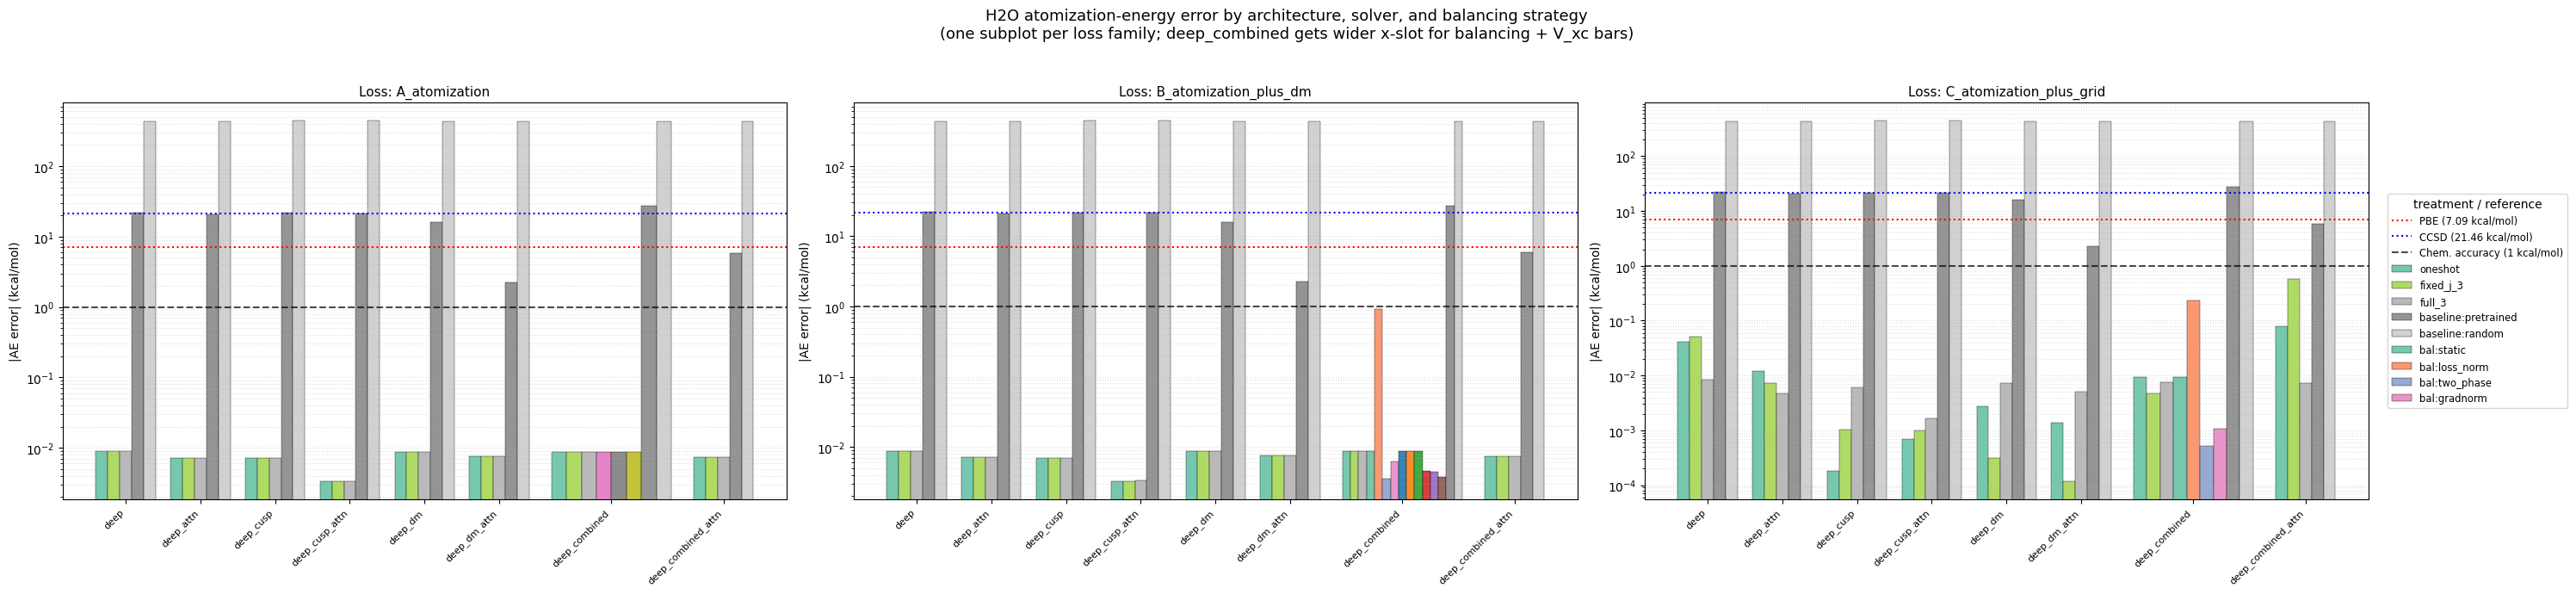

In [29]:
# Reference lines: PBE and CCSD atomization energy errors vs experiment
ext_data_dir = f"{CHECKPOINT_BASE}/external_data"
_E_ref = {}
for _name in ("H", "O", "H2O"):
    with open(f"{ext_data_dir}/{_name}_metadata.json") as _f:
        _E_ref[_name] = json.load(_f)
_AE_expt_kcalmol = 233.016

_ae_pbe_Ha = 2 * _E_ref["H"]["E_pbe_total"] + _E_ref["O"]["E_pbe_total"] - _E_ref["H2O"]["E_pbe_total"]
PBE_AE_err_kcalmol = abs(_ae_pbe_Ha * 627.509 - _AE_expt_kcalmol)
_ae_ccsd_Ha = 2 * _E_ref["H"]["E_ccsd_total"] + _E_ref["O"]["E_ccsd_total"] - _E_ref["H2O"]["E_ccsd_total"]
CCSD_AE_err_kcalmol = abs(_ae_ccsd_Ha * 627.509 - _AE_expt_kcalmol)

# Layout: one subplot per loss family. Within each subplot, per arch, we show
# 3 base solvers (oneshot, fixed_j_3, full_3). For deep_combined (BAL_ARCH),
# we ALSO show the balancing and V_xc variants that share this loss family.
# deep_combined therefore gets visibly more horizontal space (2x) than other
# archs because it has more bars; this is done by assigning it two x-slots.

def _bal_bars_for_loss(loss_name):
    """Balancing-sweep treatments applicable to this loss family."""
    treatments = []
    if loss_name in BAL_LOSS_NAMES:
        for bal_label in BALANCING_CONFIGS:
            treatments.append(("bal:" + bal_label,
                              f"{eval_balancing_dir}/{loss_name}/{bal_label}"))
    return treatments

def _vxc_bars_for_loss(loss_name):
    """V_xc-variant treatments whose ``loss_name`` matches this loss family."""
    treatments = []
    for variant_label, (vxc_loss, _, _) in VXC_VARIANTS.items():
        if vxc_loss != loss_name:
            continue
        for solver_label in SOLVER_LABELS:
            key = f"bal_vxc:{variant_label}/{solver_label}"
            out_dir = f"{eval_balancing_dir}/vxc/{variant_label}/{solver_label}"
            treatments.append((key, out_dir))
    return treatments

def _baseline_bars_for_arch(arch_name):
    """Baseline treatments (pretrained + random) for a given arch -- shown on
    every loss subplot so their context is visible alongside trained models."""
    return [
        (bl, f"{eval_baseline_dir}/{arch_name}/{bl}")
        for bl in BASELINE_LABELS
    ]

def _load_ae_err(out_dir):
    _p = f"{out_dir}/aggregate.json"
    if not os.path.isfile(_p):
        return np.nan
    with open(_p) as _f:
        _ag = json.load(_f)
    v = _ag.get("AE_error_kcalmol", {}).get("mean", np.nan)
    return abs(v) if not np.isnan(v) else np.nan

# Palettes: main solvers keep solver_colors; balancing get Set2; V_xc get tab10.
_bal_cmap = plt.get_cmap("Set2")
_vxc_cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, len(LOSS_NAMES), figsize=(10 * len(LOSS_NAMES), 7), squeeze=False)
for col_idx, loss_name in enumerate(LOSS_NAMES):
    ax = axes[0, col_idx]
    # Build list of (x_slot, arch, treatments) — deep_combined gets 2 x-slots
    # so its bars are visible; other archs get 1 slot each.
    _bal_trs = _bal_bars_for_loss(loss_name)
    _vxc_trs = _vxc_bars_for_loss(loss_name)
    _n_bal_extras = len(_bal_trs) + len(_vxc_trs)

    # Build the per-arch layout: list of (label, x_slot_count, treatments).
    arch_rows = []
    x_slot = 0
    for arch_name in ARCH_NAMES:
        is_bal = (arch_name == BAL_ARCH) and _n_bal_extras > 0
        slots = 2 if is_bal else 1
        # Base treatments: 3 solvers + 2 baselines (pretrained + random) so
        # the user can see how trained models compare against the NN's
        # PBE-mimicking starting point and a random-weights control on the
        # same chart.
        base_trs = [(s, f"{eval_dir}/{arch_name}/{loss_name}/{s}")
                    for s in SOLVER_LABELS]
        baseline_trs = _baseline_bars_for_arch(arch_name)
        trs = base_trs + (_bal_trs + _vxc_trs if is_bal else []) + baseline_trs
        arch_rows.append((arch_name, x_slot, slots, trs))
        x_slot += slots

    total_x = x_slot  # total x slots across all archs
    for arch_name, x0, slots, trs in arch_rows:
        n_bars = len(trs)
        span = slots * 0.8  # fraction of x-slot used for bars (leave 0.2 gap)
        bar_width = span / max(n_bars, 1)
        for bi, (label, out_dir) in enumerate(trs):
            val = _load_ae_err(out_dir)
            if np.isnan(val) or val <= 0:
                continue
            # Center bars on the arch's x-slot range
            xc = x0 + slots / 2.0 - 0.5
            offset = (bi - (n_bars - 1) / 2) * bar_width
            if label in SOLVER_LABELS:
                _color = solver_colors[label]
                _lbl = label if arch_name == ARCH_NAMES[0] else ""
            elif label.startswith("bal:"):
                _color = _bal_cmap(list(BALANCING_CONFIGS).index(label[4:]) % _bal_cmap.N)
                _lbl = label if arch_name == BAL_ARCH else ""
            elif label.startswith("bal_vxc:"):
                _vxc_keys = [
                    f"bal_vxc:{v}/{s}" for v in VXC_VARIANTS for s in SOLVER_LABELS
                ]
                _color = _vxc_cmap(_vxc_keys.index(label) % _vxc_cmap.N)
                _lbl = label if arch_name == BAL_ARCH else ""
            elif label in BASELINE_LABELS:
                _color = baseline_colors.get(label, '#AAAAAA')
                _lbl = f"baseline:{label}" if arch_name == ARCH_NAMES[0] else ""
            else:
                _color = "gray"; _lbl = ""
            ax.bar(xc + offset, val, width=bar_width, color=_color,
                   edgecolor="black", linewidth=0.3, label=_lbl, alpha=0.9)

    # X-axis ticks: one per arch, positioned at center of arch's x-slot range
    tick_positions = [x0 + slots / 2.0 - 0.5 for _, x0, slots, _ in arch_rows]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(ARCH_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("|AE error| (kcal/mol)")
    ax.set_yscale("log")
    ax.set_title(f"Loss: {loss_name}", fontsize=11)
    ax.grid(True, which="both", axis="y", ls=":", alpha=0.4)

    ax.axhline(PBE_AE_err_kcalmol, linestyle=":", color="r", linewidth=1.5,
               label=f"PBE ({PBE_AE_err_kcalmol:.2f} kcal/mol)")
    ax.axhline(CCSD_AE_err_kcalmol, linestyle=":", color="b", linewidth=1.5,
               label=f"CCSD ({CCSD_AE_err_kcalmol:.2f} kcal/mol)")
    ax.axhline(1.0, linestyle="--", color="k", alpha=0.7,
               label="Chem. accuracy (1 kcal/mol)")

# Dedup legend, move outside
_h, _l = axes[0, -1].get_legend_handles_labels()
_seen = {}
for _hh, _ll in zip(_h, _l):
    if _ll and _ll not in _seen:
        _seen[_ll] = _hh
axes[0, -1].legend(
    _seen.values(), _seen.keys(),
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    fontsize="small", title="treatment / reference",
)

fig.suptitle(
    "H2O atomization-energy error by architecture, solver, and balancing strategy\n"
    "(one subplot per loss family; deep_combined gets wider x-slot for balancing + V_xc bars)",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(f"{figures_dir}/scf_comparison_ae.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure: Density Matrix Residuals -- SCF Comparison

For loss B (energy + DM), this plot compares the density-matrix residuals
(NN - HF target) across the 3 solver configurations for the best-performing
architecture. A 1x3 panel with shared colorbar shows how self-consistency
affects the learned density matrix.


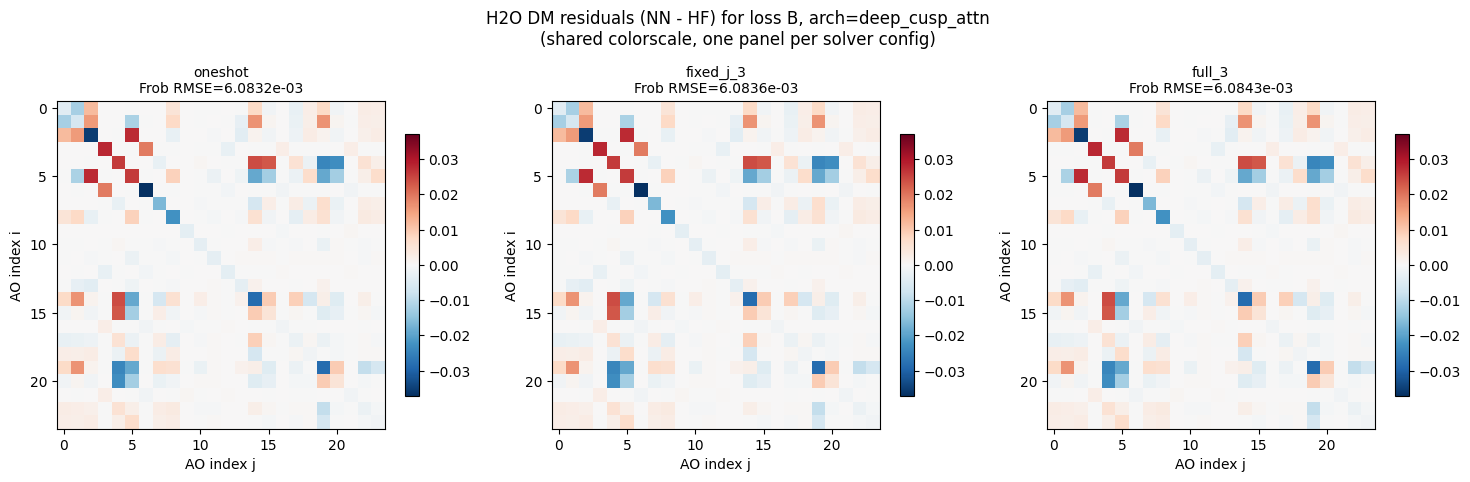

In [30]:
_loss_b = "B_atomization_plus_dm"
if _loss_b not in LOSS_NAMES:
    print("[Cell 29] loss B not in config -- skipping DM heatmaps")
else:
    # Find best arch for loss B across all solvers
    _sub = df.xs(_loss_b, level="loss")["AE_error_kcalmol_mean"].abs()
    _best_arch, _best_solver = _sub.idxmin()

    dm_hf = mol_data_list[2]["dm_target"]  # H2O is index 2

    fig, axes = plt.subplots(1, len(SOLVER_LABELS), figsize=(5 * len(SOLVER_LABELS), 4.5),
                             squeeze=False)
    _vmax = 0
    _dm_panels = []
    for solver_label in SOLVER_LABELS:
        ckpt = f"{train_dir}/{_best_arch}/{_loss_b}/{solver_label}/model.eqx"
        if not os.path.isfile(ckpt):
            _dm_panels.append(None)
            continue
        _arch_config = alec.get_architecture(_best_arch)
        _model = eqx.tree_deserialise_leaves(ckpt, alec.AlecGGAModel.from_arch(_arch_config))
        _dm_nn = alec.oneshot_dm_prediction_fast(_model, mol_data_list[2])
        _delta = _dm_nn - dm_hf
        _dm_panels.append(_delta)
        _vmax = max(_vmax, float(jnp.abs(_delta).max()))

    for i, (solver_label, delta) in enumerate(zip(SOLVER_LABELS, _dm_panels)):
        ax = axes[0, i]
        if delta is None:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
        else:
            _rmse = float(jnp.sqrt(jnp.mean(delta ** 2)))
            im = ax.imshow(np.asarray(delta), cmap="RdBu_r", vmin=-_vmax, vmax=_vmax)
            ax.set_title(f"{solver_label}\nFrob RMSE={_rmse:.4e}", fontsize=10)
            ax.set_xlabel("AO index j")
            ax.set_ylabel("AO index i")
            fig.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(
        f"H2O DM residuals (NN - HF) for loss B, arch={_best_arch}\n"
        f"(shared colorscale, one panel per solver config)",
        fontsize=12,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    os.makedirs(f"{figures_dir}", exist_ok=True)
    fig.savefig(f"{figures_dir}/dm_heatmaps_scf.png", dpi=150, bbox_inches="tight")
    plt.show()


### Figure: Grid Density Residuals -- SCF Comparison

For loss C (energy + grid density), this plot overlays histograms of the
grid-weighted density residual (delta-rho) across the 3 solver configurations
for the best-performing architecture. Tighter distributions indicate better
density prediction.


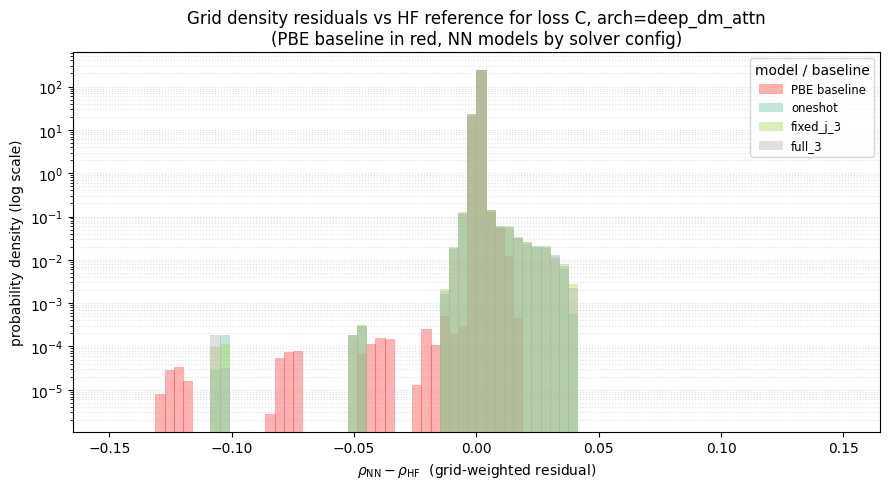

In [31]:
_loss_c = "C_atomization_plus_grid"
if _loss_c not in LOSS_NAMES:
    print("[Cell 31] loss C not in config -- skipping density histograms")
else:
    _sub = df.xs(_loss_c, level="loss")["AE_error_kcalmol_mean"].abs()
    _best_arch, _best_solver = _sub.idxmin()

    rho_ref = mol_data_list[2]["rho_ref_grid"]
    weights = mol_data_list[2]["grid_weights"]
    _bins = np.linspace(-0.15, 0.15, 81)

    # PBE baseline density residuals
    _rho_pbe = mol_data_list[2]["rho_grid"]
    _delta_pbe = np.asarray(_rho_pbe - rho_ref)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(_delta_pbe, bins=_bins, alpha=0.3, color="red", edgecolor="red",
            linewidth=0.5, label="PBE baseline",
            weights=np.asarray(weights), density=True)

    for solver_label in SOLVER_LABELS:
        ckpt = f"{train_dir}/{_best_arch}/{_loss_c}/{solver_label}/model.eqx"
        if not os.path.isfile(ckpt):
            continue
        _arch_config = alec.get_architecture(_best_arch)
        _model = eqx.tree_deserialise_leaves(ckpt, alec.AlecGGAModel.from_arch(_arch_config))
        _rho_nn = alec.oneshot_grid_density(_model, mol_data_list[2])
        _delta = np.asarray(_rho_nn - rho_ref)
        ax.hist(_delta, bins=_bins, alpha=0.4, color=solver_colors[solver_label],
                edgecolor=solver_colors[solver_label], linewidth=0.5,
                label=solver_label, weights=np.asarray(weights), density=True)

    ax.set_xlabel(r"$\rho_{\mathrm{NN}} - \rho_{\mathrm{HF}}$  (grid-weighted residual)")
    ax.set_ylabel("probability density (log scale)")
    ax.set_yscale("log")
    ax.set_title(
        f"Grid density residuals vs HF reference for loss C, arch={_best_arch}\n"
        f"(PBE baseline in red, NN models by solver config)",
    )
    ax.legend(title="model / baseline", fontsize="small")
    ax.grid(True, which="both", axis="y", ls=":", alpha=0.4)
    fig.tight_layout()
    os.makedirs(f"{figures_dir}", exist_ok=True)
    fig.savefig(f"{figures_dir}/grid_density_scf.png", dpi=150, bbox_inches="tight")
    plt.show()


### Figure: SCF Convergence Diagnostic

This plot runs the SCF solver with increased `max_cycles=10` on a trained
model (deep_combined, loss A) and plots |E(n) - E(n-1)| vs cycle number for
both FIXED_J and FULL modes. This shows the convergence rate under
self-consistency -- how quickly the energy settles.

Note: this is evaluation-only (no training through the loop). The trained
model was trained with the solver config in its checkpoint path; here we
just observe how it behaves under extended iteration.


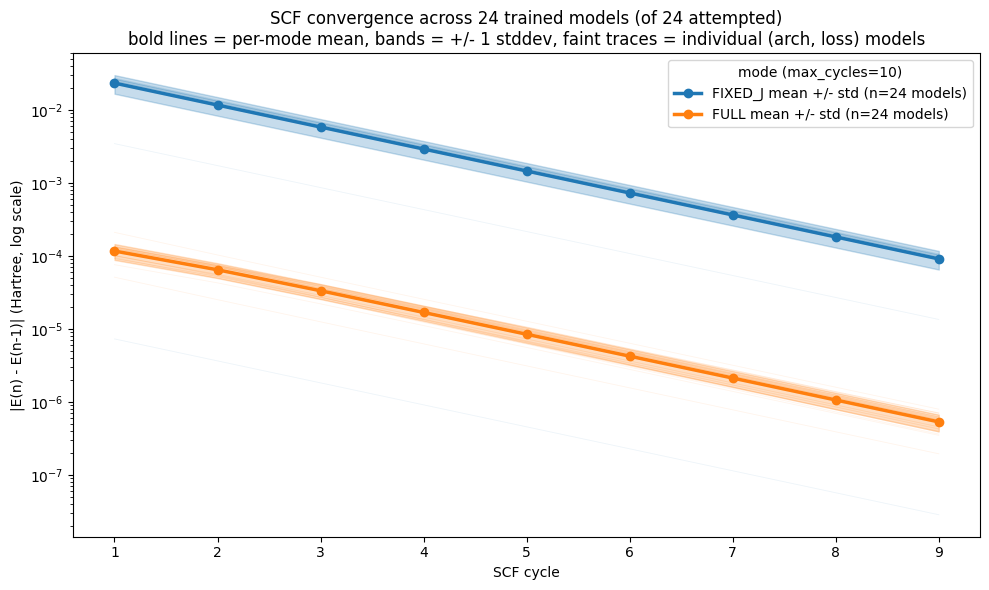


[Cell 33] aggregated 24 models; per-mode traces: [('FIXED_J', 24), ('FULL', 24)]


In [32]:
from xcquinox.alec.solver import run_scf

_DIAG_MAX_CYCLES = 10
_diag_configs = {
    "FIXED_J": SolverConfig(
        backend=SolverBackend.MANUAL, mode=SolverMode.FIXED_J,
        max_cycles=_DIAG_MAX_CYCLES, conv_tol=1e-10,
    ),
    "FULL": SolverConfig(
        backend=SolverBackend.MANUAL, mode=SolverMode.FULL,
        max_cycles=_DIAG_MAX_CYCLES, conv_tol=1e-10,
    ),
}
_h2o_data = next((m for m in mol_data_list if m.get('name') == 'H2O'), mol_data_list[-1])

# Collect per-cycle deltas for every trained (arch, loss) combination,
# stratified by solver mode. ``_deltas_by_mode[mode_name]`` is a list of
# 1-D arrays, one per (arch, loss) combination that successfully ran.
_deltas_by_mode = {name: [] for name in _diag_configs}
_n_attempted = 0
_n_completed = 0

for _arch_name in ARCH_NAMES:
    _arch_cfg = alec.get_architecture(_arch_name)
    for _loss_name in LOSS_NAMES:
        # Use oneshot-trained model for both FIXED_J and FULL diagnostics;
        # oneshot is the fastest training regime and gives the cleanest
        # convergence signature of the trained NN's V_xc.
        _ckpt = f"{train_dir}/{_arch_name}/{_loss_name}/oneshot/model.eqx"
        if not os.path.isfile(_ckpt):
            continue
        _n_attempted += 1
        try:
            _model = eqx.tree_deserialise_leaves(_ckpt, alec.AlecGGAModel.from_arch(_arch_cfg))
        except Exception as _e:
            print(f"  skip {_arch_name}/{_loss_name}: could not load ({_e})")
            continue
        for _mode_name, _cfg in _diag_configs.items():
            try:
                _res = run_scf(_cfg, _model, _h2o_data)
            except Exception as _e:
                print(f"  skip {_arch_name}/{_loss_name} {_mode_name}: {_e}")
                continue
            if not hasattr(_res, 'energy_trace') or _res.energy_trace is None:
                continue
            _trace = np.asarray(_res.energy_trace)
            _trace = _trace[np.isfinite(_trace)]
            if len(_trace) < 2:
                continue
            _deltas_by_mode[_mode_name].append(np.abs(np.diff(_trace)))
        _n_completed += 1

# Aggregate to mean/std per cycle. Different runs may have different
# energy_trace lengths (e.g. if SCF converged early), so we align by cycle
# index and take cycle-wise statistics only over runs that have data at
# that cycle.
def _aggregate_deltas(list_of_arrays, n_cycles):
    if not list_of_arrays:
        return None
    stacked = np.full((len(list_of_arrays), n_cycles), np.nan)
    for i, arr in enumerate(list_of_arrays):
        k = min(len(arr), n_cycles)
        stacked[i, :k] = arr[:k]
    means = np.nanmean(stacked, axis=0)
    stds = np.nanstd(stacked, axis=0)
    counts = np.sum(np.isfinite(stacked), axis=0)
    return means, stds, counts

fig, ax = plt.subplots(figsize=(10, 6))
_mode_colors = {'FIXED_J': '#1f77b4', 'FULL': '#ff7f0e'}
_n_cycles = _DIAG_MAX_CYCLES - 1  # n-1 deltas for n energies
for _mode_name, _deltas_list in _deltas_by_mode.items():
    _agg = _aggregate_deltas(_deltas_list, _n_cycles)
    if _agg is None:
        print(f"[Cell 33] no runs for {_mode_name} -- skipping")
        continue
    _means, _stds, _counts = _agg
    _x = np.arange(1, _n_cycles + 1)
    _color = _mode_colors[_mode_name]
    # Layer 1 (back): individual per-model traces, very transparent
    for _d in _deltas_list:
        _k = min(len(_d), _n_cycles)
        ax.semilogy(np.arange(1, _k + 1), _d[:_k], '-',
                   color=_color, alpha=0.08, linewidth=0.6, zorder=1)
    # Layer 2 (middle): mean +/- std band (clipped to positive for log scale)
    _low = np.maximum(_means - _stds, _means * 0.1)
    _high = _means + _stds
    ax.fill_between(_x, _low, _high, color=_color, alpha=0.25, zorder=2)
    # Layer 3 (front): mean line, fully opaque, on top of everything
    ax.semilogy(_x, _means, 'o-', color=_color, linewidth=2.5, zorder=3,
                label=f"{_mode_name} mean +/- std (n={len(_deltas_list)} models)")

ax.set_xlabel("SCF cycle")
ax.set_ylabel("|E(n) - E(n-1)| (Hartree, log scale)")
ax.set_title(
    f"SCF convergence across {_n_completed} trained models (of {_n_attempted} attempted)\n"
    f"bold lines = per-mode mean, bands = +/- 1 stddev, faint traces = individual (arch, loss) models"
)
ax.legend(title=f"mode (max_cycles={_DIAG_MAX_CYCLES})", loc='best')
ax.grid(False)
fig.tight_layout()
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(f"{figures_dir}/scf_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n[Cell 33] aggregated {_n_completed} models; "
      f"per-mode traces: {[(m, len(l)) for m, l in _deltas_by_mode.items()]}")


### Figure: Feature Impact Across Solver Configs

This plot compares the 4 non-attention deep variants (`deep`, `deep_cusp`,
`deep_dm`, `deep_combined`) across the 3 solver configs. One subplot per loss
family (A, B, C). Using non-attention variants only provides a clean comparison
of descriptor impact without attention confounds.


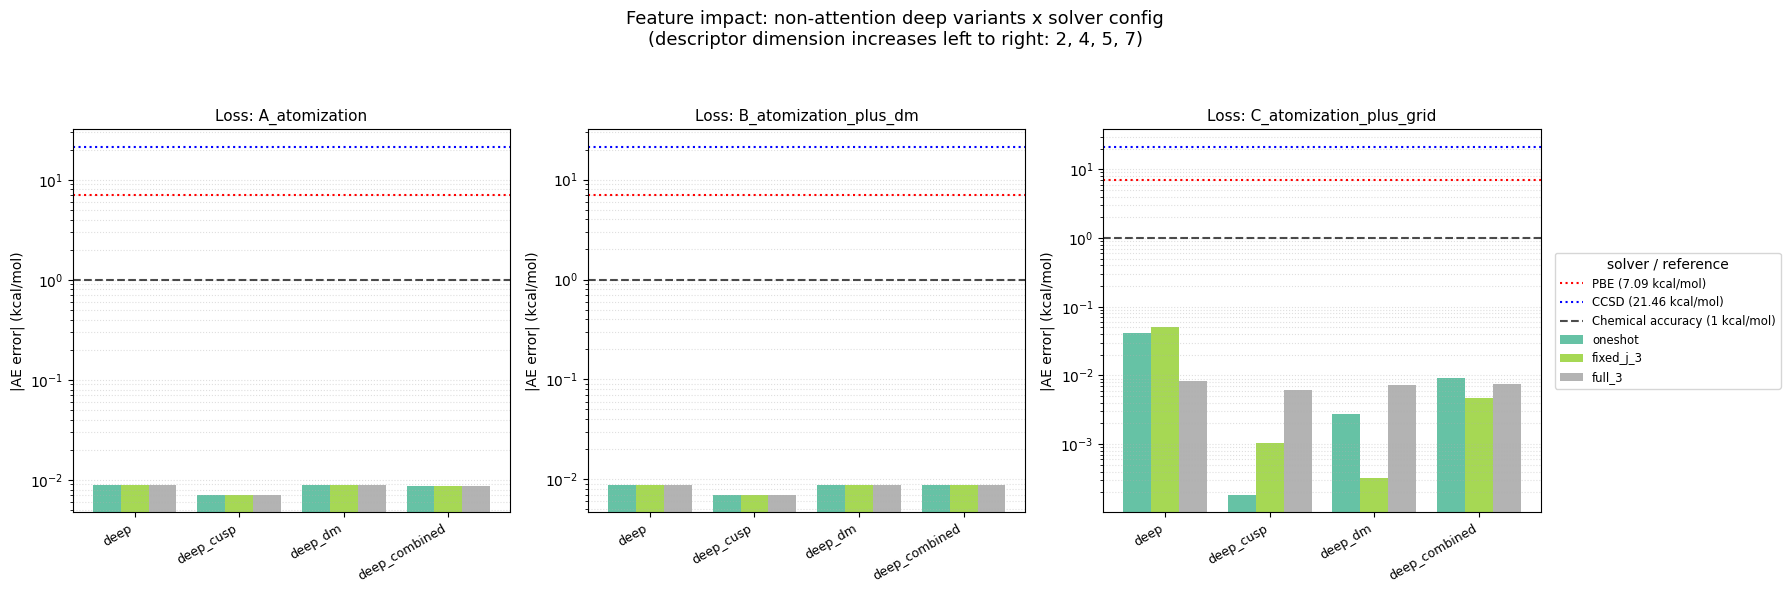

In [33]:
_feature_archs = ["deep", "deep_cusp", "deep_dm", "deep_combined"]
_feature_archs = [a for a in _feature_archs if a in ARCH_NAMES]

if not _feature_archs:
    print("[Cell 35] no non-attention deep variants in config -- skipping")
else:
    fig, axes = plt.subplots(1, len(LOSS_NAMES), figsize=(6 * len(LOSS_NAMES), 6),
                             squeeze=False)
    n_archs = len(_feature_archs)
    n_solvers = len(SOLVER_LABELS)
    x_positions = np.arange(n_archs)
    bar_width = 0.8 / max(n_solvers, 1)

    for col_idx, loss_name in enumerate(LOSS_NAMES):
        ax = axes[0, col_idx]
        for s_idx, solver_label in enumerate(SOLVER_LABELS):
            heights = []
            for arch_name in _feature_archs:
                try:
                    val = df.loc[(arch_name, loss_name, solver_label), "AE_error_kcalmol_mean"]
                    heights.append(abs(val) if not np.isnan(val) else np.nan)
                except KeyError:
                    heights.append(np.nan)
            offset = (s_idx - (n_solvers - 1) / 2) * bar_width
            ax.bar(x_positions + offset, heights, width=bar_width,
                   color=solver_colors[solver_label], label=solver_label)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(_feature_archs, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("|AE error| (kcal/mol)")
        ax.set_yscale("log")
        ax.set_title(f"Loss: {loss_name}", fontsize=11)
        ax.grid(True, which="both", axis="y", ls=":", alpha=0.4)
        ax.axhline(PBE_AE_err_kcalmol, linestyle=":", color="r", linewidth=1.5,
                   label=f"PBE ({PBE_AE_err_kcalmol:.2f} kcal/mol)")
        ax.axhline(CCSD_AE_err_kcalmol, linestyle=":", color="b", linewidth=1.5,
                   label=f"CCSD ({CCSD_AE_err_kcalmol:.2f} kcal/mol)")
        ax.axhline(1.0, linestyle="--", color="k", alpha=0.7,
                   label="Chemical accuracy (1 kcal/mol)")

    axes[0, -1].legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize="small",
        title="solver / reference",
    )

    fig.suptitle(
        "Feature impact: non-attention deep variants x solver config\n"
        "(descriptor dimension increases left to right: 2, 4, 5, 7)",
        fontsize=13,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    os.makedirs(f"{figures_dir}", exist_ok=True)
    fig.savefig(f"{figures_dir}/feature_impact_scf.png", dpi=150, bbox_inches="tight")
    plt.show()


## Section 7: Transfer Evaluation on New Molecules

This section tests all trained models (72 main + 8 balancing) on molecules
not seen during training:

| Molecule | Why | Key metric |
|----------|-----|------------|
| **H2** | Simplest diatomic; only H atoms (in training set) | AE error, density RMSE |
| **OH** | New element, never seen during training | Total energy error, density RMSE |
| **CH4** | New element (C), 5 atoms, tetrahedral geometry | AE error, density RMSE |

For each, we compute PBE/HF/CCSD reference data, then sweep all checkpoints.


In [34]:
ext_data_dir = f"{CHECKPOINT_BASE}/external_data"
os.makedirs(ext_data_dir, exist_ok=True)

# Define test molecules with their reference AE values
test_molecules = [
    {
        "name": "H2",
        "spec": alec.MoleculeSpec(
            name="H2",
            atom="H 0 0 0; H 0 0 0.74",
            basis=BASIS, charge=0, spin=0,
            atom_composition=(("H", 2),),
            grid_level=GRID_LEVEL,
            external_data_path=f"{ext_data_dir}/H2.npz",
        ),
        "new_atoms": [],
        "ae_ref_kcalmol": 109.493,
    },
    {
        "name": "OH",
        "spec": alec.MoleculeSpec(
            name="OH",
            atom="O 0 0 0.10785; H 0 0 -0.86281",
            basis=BASIS, charge=0, spin=1,
            atom_composition=(("O", 1), ("H", 1)),
            grid_level=GRID_LEVEL,
            external_data_path=f"{ext_data_dir}/OH.npz",
        ),
        "new_atoms": [],
        "ae_ref_kcalmol": 107.208,
    },
    {
        "name": "CH4",
        "spec": alec.MoleculeSpec(
            name="CH4",
            atom="C 0 0 0; H 0.63 0.63 0.63; H -0.63 -0.63 0.63; H -0.63 0.63 -0.63; H 0.63 -0.63 -0.63",
            basis=BASIS, charge=0, spin=0,
            atom_composition=(("C", 1), ("H", 4)),
            grid_level=GRID_LEVEL,
            external_data_path=f"{ext_data_dir}/CH4.npz",
        ),
        "new_atoms": [("C", "C 0 0 0", 2)],
        "ae_ref_kcalmol": 420.421,
    },
]

# Collect all new atom species across test molecules
all_new_atoms = []
_seen_atoms = set()
for tm in test_molecules:
    for a_name, a_atom, a_spin in tm["new_atoms"]:
        if a_name not in _seen_atoms:
            all_new_atoms.append((a_name, a_atom, a_spin))
            _seen_atoms.add(a_name)

# Generate reference data for all test molecules and new atoms
_all_entities = []
for tm in test_molecules:
    spec = tm["spec"]
    _all_entities.append((spec.name, spec.atom, spec.spin, False))
for a_name, a_atom, a_spin in all_new_atoms:
    _all_entities.append((a_name, a_atom, a_spin, True))

for _name, _atom, _spin, _is_atom in _all_entities:
    _npz_path = f"{ext_data_dir}/{_name}.npz"
    _meta_path = f"{ext_data_dir}/{_name}_metadata.json"
    if os.path.isfile(_npz_path) and os.path.isfile(_meta_path):
        print(f"Using cached {_name} reference data")
        continue

    _mol = gto.M(atom=_atom, basis=BASIS, charge=0, spin=_spin, verbose=0)

    _mf_pbe = dft.UKS(_mol) if _spin else dft.RKS(_mol)
    _mf_pbe.xc = "pbe"
    _mf_pbe.grids.level = GRID_LEVEL
    _mf_pbe.kernel()
    _E_pbe_total = float(_mf_pbe.e_tot)

    _mf_hf = scf.UHF(_mol) if _spin else scf.RHF(_mol)
    _mf_hf.kernel()
    _E_hf_total = float(_mf_hf.e_tot)

    _mycc = cc.UCCSD(_mf_hf) if _spin else cc.CCSD(_mf_hf)
    _mycc.kernel()
    _E_ccsd_total = float(_mf_hf.e_tot + _mycc.e_corr)

    _sidecar = {
        "E_hf_total": _E_hf_total,
        "E_ccsd_total": _E_ccsd_total,
        "E_pbe_total": _E_pbe_total,
        "E_lit_Ha": None,
    }

    if _is_atom:
        np.savez(_npz_path, E_ref_literature=_E_ccsd_total)
    else:
        # CCSD AO-basis DM via MO->AO transform. Closed-shell uses RCCSD;
        # open-shell (e.g. OH, spin=1) uses UCCSD with spin-branched mo_coeff.
        if _spin == 0:
            _dm_mo_ccsd = _mycc.make_rdm1()
            _C = _mf_hf.mo_coeff
            _dm_ao_ccsd = _C @ _dm_mo_ccsd @ _C.T
        else:
            _dm_mo_a, _dm_mo_b = _mycc.make_rdm1()
            _Ca, _Cb = _mf_hf.mo_coeff[0], _mf_hf.mo_coeff[1]
            _dm_ao_a = _Ca @ _dm_mo_a @ _Ca.T
            _dm_ao_b = _Cb @ _dm_mo_b @ _Cb.T
            _dm_ao_ccsd = np.stack([_dm_ao_a, _dm_ao_b], axis=0)
        _dm_total = (
            _dm_ao_ccsd[0] + _dm_ao_ccsd[1]
            if _dm_ao_ccsd.ndim == 3
            else _dm_ao_ccsd
        )
        _coords = _mf_pbe.grids.coords
        _weights = _mf_pbe.grids.weights
        _ao = _mf_pbe._numint.eval_ao(_mol, _coords, deriv=0)
        _rho_ccsd = np.einsum("ij,gi,gj->g", _dm_total, _ao, _ao)
        _dm_pbe = _mf_pbe.make_rdm1()
        _dm_pbe_total = _dm_pbe[0] + _dm_pbe[1] if _dm_pbe.ndim == 3 else _dm_pbe
        _rho_pbe = np.einsum("ij,gi,gj->g", _dm_pbe_total, _ao, _ao)
        _rho_pbe_ccsd_rmse = float(
            np.sqrt(np.sum(_weights * (_rho_pbe - _rho_ccsd) ** 2) / np.sum(_weights))
        )
        np.savez(
            _npz_path,
            dm_target=_dm_ao_ccsd,
            rho_ref_grid=_rho_ccsd,
            ref_density_method="ccsd",
            E_ref_literature=float(_E_ccsd_total),
        )
        _sidecar["rho_pbe_ccsd_rmse"] = _rho_pbe_ccsd_rmse

    with open(_meta_path, "w") as _f:
        json.dump(_sidecar, _f, indent=2)
    print(f"Generated {_name} reference data -> {_npz_path}")

# Build atom_energies for transfer eval (PBE-consistent)
transfer_atom_energies = {**atom_energies}
for a_name, _, _ in all_new_atoms:
    with open(f"{ext_data_dir}/{a_name}_metadata.json") as _f:
        transfer_atom_energies[a_name] = json.load(_f)["E_pbe_total"]
print(f"transfer_atom_energies: {list(transfer_atom_energies.keys())}")
print(f"Test molecules: {[tm['name'] for tm in test_molecules]}")


Using cached H2 reference data
Using cached OH reference data
Using cached CH4 reference data
Using cached C reference data
transfer_atom_energies: ['H', 'O', 'C']
Test molecules: ['H2', 'OH', 'CH4']


### Figure: Transfer Evaluation -- H2, OH, CH4

The next cell sweeps all trained checkpoints (72 main + 8 balancing) on each
test molecule. Results plotted as grouped bars:

- **H2:** AE error and density RMSE (known element, new geometry)
- **OH:** Total energy error and density RMSE (unseen element)
- **CH4:** AE error and density RMSE (unseen element C, larger molecule)

In [35]:
_transfer_pkl = transfer_results_path

def _eval_model_on_mol(arch_name, model_path, mol_spec, ae_ref, mol_name,
                        out_dir, solver_config, atom_energies_dict):
    """Run evaluation and return result row dict."""
    _is_atom = (len(mol_spec.atom_composition) == 1
                and mol_spec.atom_composition[0][1] == 1)
    if _is_atom:
        _metrics = ("total_energy", "density_rmse")
        _mk = {}
    else:
        _metrics = ("total_energy", "atomization_energy", "density_rmse")
        _mk = ({"atomization_energy": {"reference_ae_kcalmol": {mol_name: ae_ref}}}
               if ae_ref else {})
    _spec = alec.TestSpec.from_dicts(
        arch=alec.get_architecture(arch_name),
        model_checkpoint=model_path,
        molecules=(mol_spec,),
        metrics=_metrics,
        metric_kwargs=_mk,
        atom_energies=atom_energies_dict,
        output_dir=out_dir,
        solver_config=solver_config,
    )
    _res = alec.run_test(_spec)
    _pm = _res["per_molecule"][0]
    # Release JAX JIT cache between transfer eval calls. Transfer sweeps
    # ~250+ checkpoints (72 main + 17 balancing + 16 baseline) x 3 test
    # molecules x ... — without clearing, LLVM IR accumulates and OOMs.
    jax.clear_caches(); gc.collect()
    return {
        "AE_error_kcalmol": float(abs(_pm.get("AE_error_kcalmol", float("nan")))),
        "E_error_kcalmol": float(abs(_pm.get("E_error_kcalmol", float("nan")))),
        "density_rmse": float(_pm["density_rmse"]) if _pm.get("density_rmse") is not None else float("nan"),
    }

if RERUN_EVAL or not os.path.isfile(_transfer_pkl):
    transfer_results = {}
    for tm in test_molecules:
        _mol_name = tm["name"]
        _mol_spec = tm["spec"]
        _ae_ref = tm["ae_ref_kcalmol"]
        _rows = []

        # Trained models
        for _arch in ARCH_NAMES:
            for _loss in LOSS_NAMES:
                for _solver in SOLVER_LABELS:
                    _ckpt = f"{train_dir}/{_arch}/{_loss}/{_solver}/model.eqx"
                    if not os.path.isfile(_ckpt):
                        continue
                    _out = f"{test_new_dir}/{_mol_name}/{_arch}/{_loss}/{_solver}"
                    row = _eval_model_on_mol(
                        _arch, _ckpt, _mol_spec, _ae_ref, _mol_name,
                        _out, SCF_CONFIGS[_solver], transfer_atom_energies)
                    row.update({"arch": _arch, "loss": _loss, "solver": _solver})
                    _rows.append(row)

        # Balancing sweep
        for _loss in BAL_LOSS_NAMES:
            for _bl in BALANCING_CONFIGS:
                _ckpt = f"{train_balancing_dir}/{_loss}/{_bl}/model.eqx"
                if not os.path.isfile(_ckpt):
                    continue
                _out = f"{test_new_dir}/{_mol_name}/balancing/{_loss}/{_bl}"
                row = _eval_model_on_mol(
                    BAL_ARCH, _ckpt, _mol_spec, _ae_ref, _mol_name,
                    _out, SCF_CONFIGS[BAL_SOLVER], transfer_atom_energies)
                row.update({"arch": BAL_ARCH, "loss": _loss, "solver": f"bal:{_bl}"})
                _rows.append(row)

        # V_xc variants transfer eval (9 runs on deep_combined)
        for variant_label, (loss_name, _, _) in VXC_VARIANTS.items():
            for solver_label in SOLVER_LABELS:
                _ckpt = f"{train_balancing_dir}/vxc/{variant_label}/{solver_label}/model.eqx"
                if not os.path.isfile(_ckpt):
                    continue
                _out = f"{test_new_dir}/{_mol_name}/balancing_vxc/{variant_label}/{solver_label}"
                row = _eval_model_on_mol(
                    BAL_ARCH, _ckpt, _mol_spec, _ae_ref, _mol_name,
                    _out, SCF_CONFIGS[solver_label], transfer_atom_energies)
                row.update({
                    "arch": BAL_ARCH,
                    "loss": loss_name,
                    "solver": f"bal_vxc:{variant_label}/{solver_label}",
                })
                _rows.append(row)

        # Baselines (pretrained + random)
        for _arch in ARCH_NAMES:
            for _bl in BASELINE_LABELS:
                _ckpt = f"{baseline_dir}/{_bl}/{_arch}/model.eqx"
                if not os.path.isfile(_ckpt):
                    continue
                _out = f"{test_new_dir}/{_mol_name}/baseline/{_arch}/{_bl}"
                row = _eval_model_on_mol(
                    _arch, _ckpt, _mol_spec, _ae_ref, _mol_name,
                    _out, None, transfer_atom_energies)
                row.update({"arch": _arch, "loss": "baseline", "solver": _bl})
                _rows.append(row)

        if _rows:
            transfer_results[_mol_name] = pd.DataFrame(_rows)
            print(f"{_mol_name}: {len(_rows)} evaluations")
        else:
            print(f"{_mol_name}: no checkpoints found")

    with open(_transfer_pkl, "wb") as _f:
        pickle.dump(transfer_results, _f, protocol=4)
    print(f"\nSaved to {_transfer_pkl}")
else:
    with open(_transfer_pkl, "rb") as _f:
        transfer_results = pickle.load(_f)
    print(f"Loaded cached results from {_transfer_pkl}")
    for mol_name, tdf in transfer_results.items():
        print(f"  {mol_name}: {len(tdf)} rows")

# ---- Reference energies for each test molecule ----
transfer_refs = {}
for tm in test_molecules:
    _mol_name = tm["name"]
    _ae_ref = tm["ae_ref_kcalmol"]
    _meta_path = f"{ext_data_dir}/{_mol_name}_metadata.json"
    refs = {}
    if os.path.isfile(_meta_path):
        with open(_meta_path) as _f:
            _meta = json.load(_f)
        if _ae_ref is not None:
            _comp = dict(tm["spec"].atom_composition)
            for method in ('pbe', 'ccsd'):
                _key = f"E_{method}_total"
                _atom_E = sum(
                    transfer_refs.get(Z, {}).get(_key,
                        json.load(open(f"{ext_data_dir}/{Z}_metadata.json")).get(_key, 0)
                    ) * cnt for Z, cnt in _comp.items()
                )
                _mol_E = _meta.get(_key, 0)
                refs[f'{method}_ae_err'] = abs((_atom_E - _mol_E) * 627.509 - _ae_ref)
    transfer_refs[_mol_name] = refs
    if os.path.isfile(_meta_path):
        with open(_meta_path) as _f:
            for k, v in json.load(_f).items():
                transfer_refs.setdefault(_mol_name, {})[k] = v

print(f"\nTransfer evaluation ready: {list(transfer_results.keys())}")


H2: 105 evaluations
OH: 105 evaluations
CH4: 105 evaluations

Saved to checkpoints_step5/integration/transfer_results.pkl

Transfer evaluation ready: ['H2', 'OH', 'CH4']


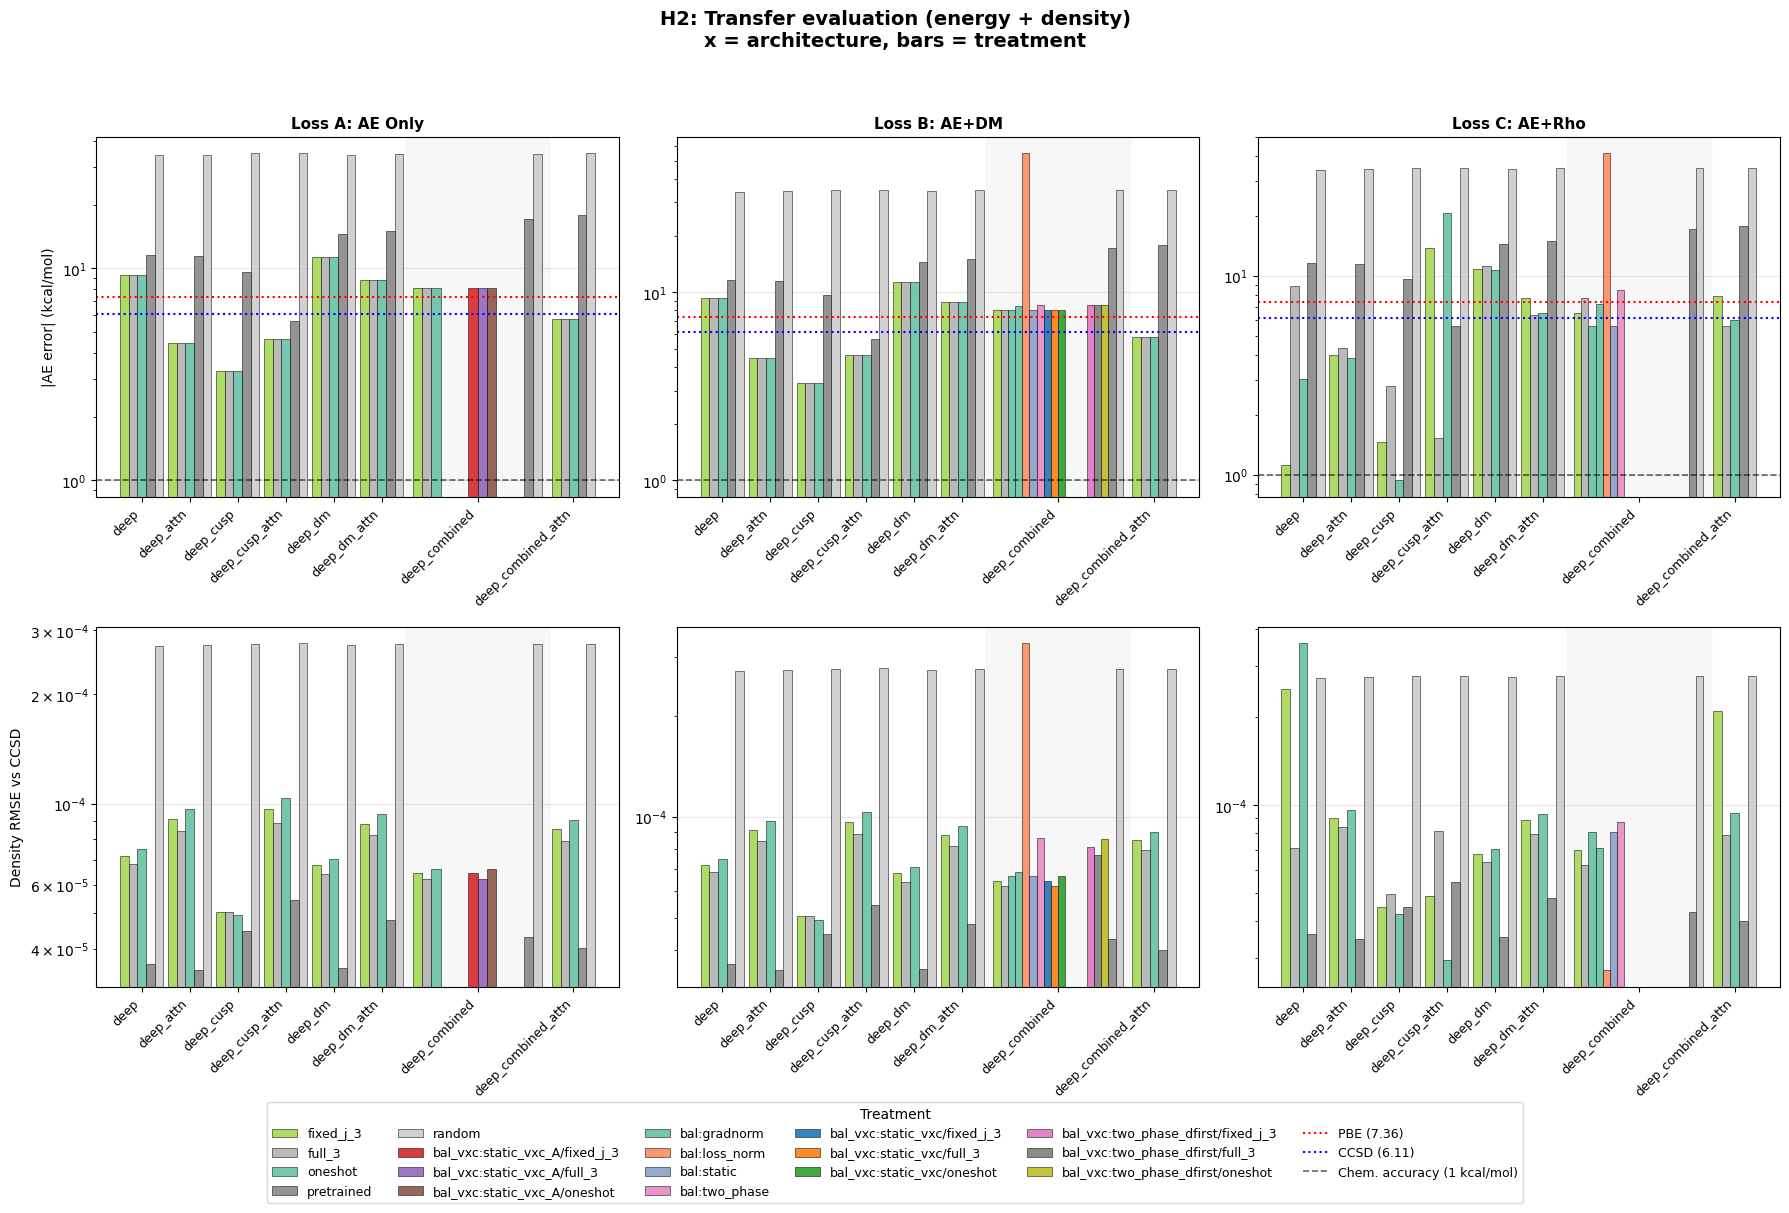

  Saved transfer_H2.png


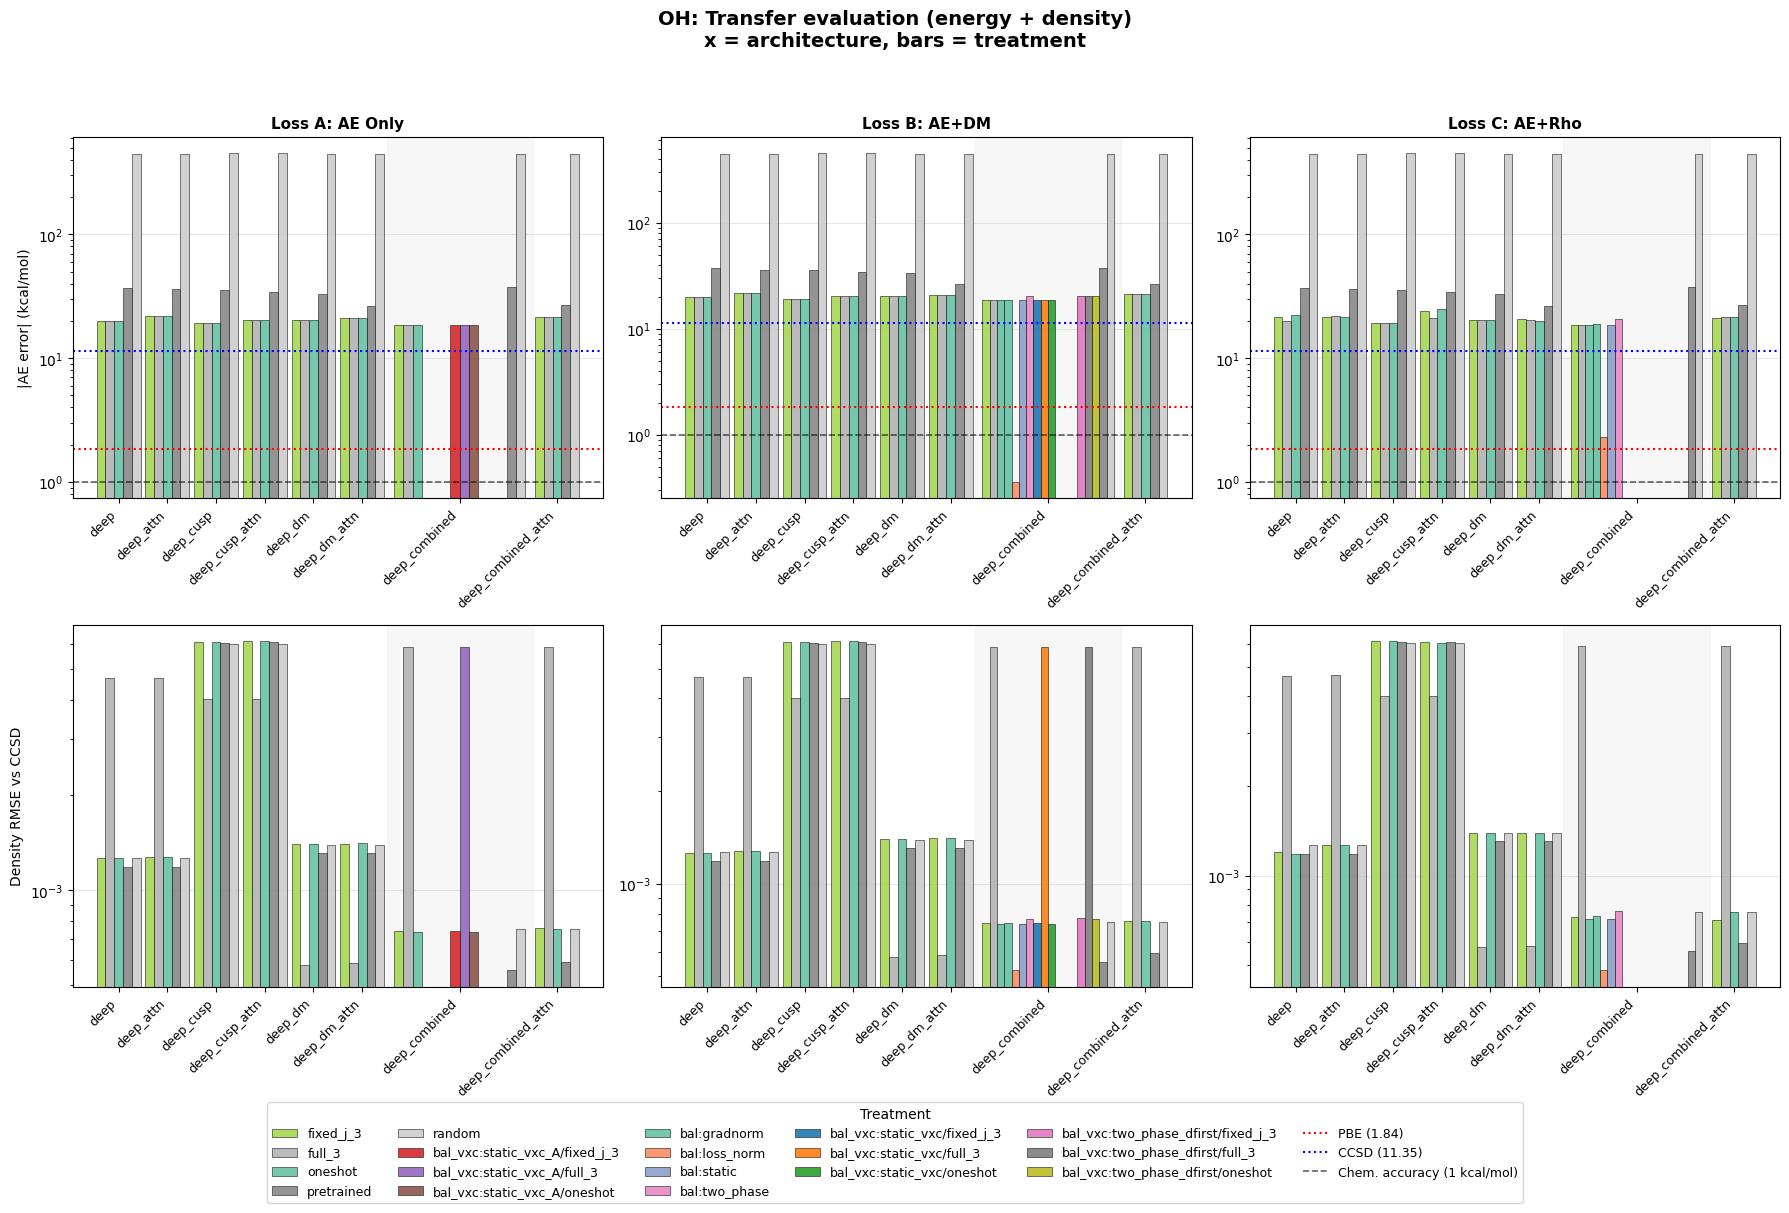

  Saved transfer_OH.png


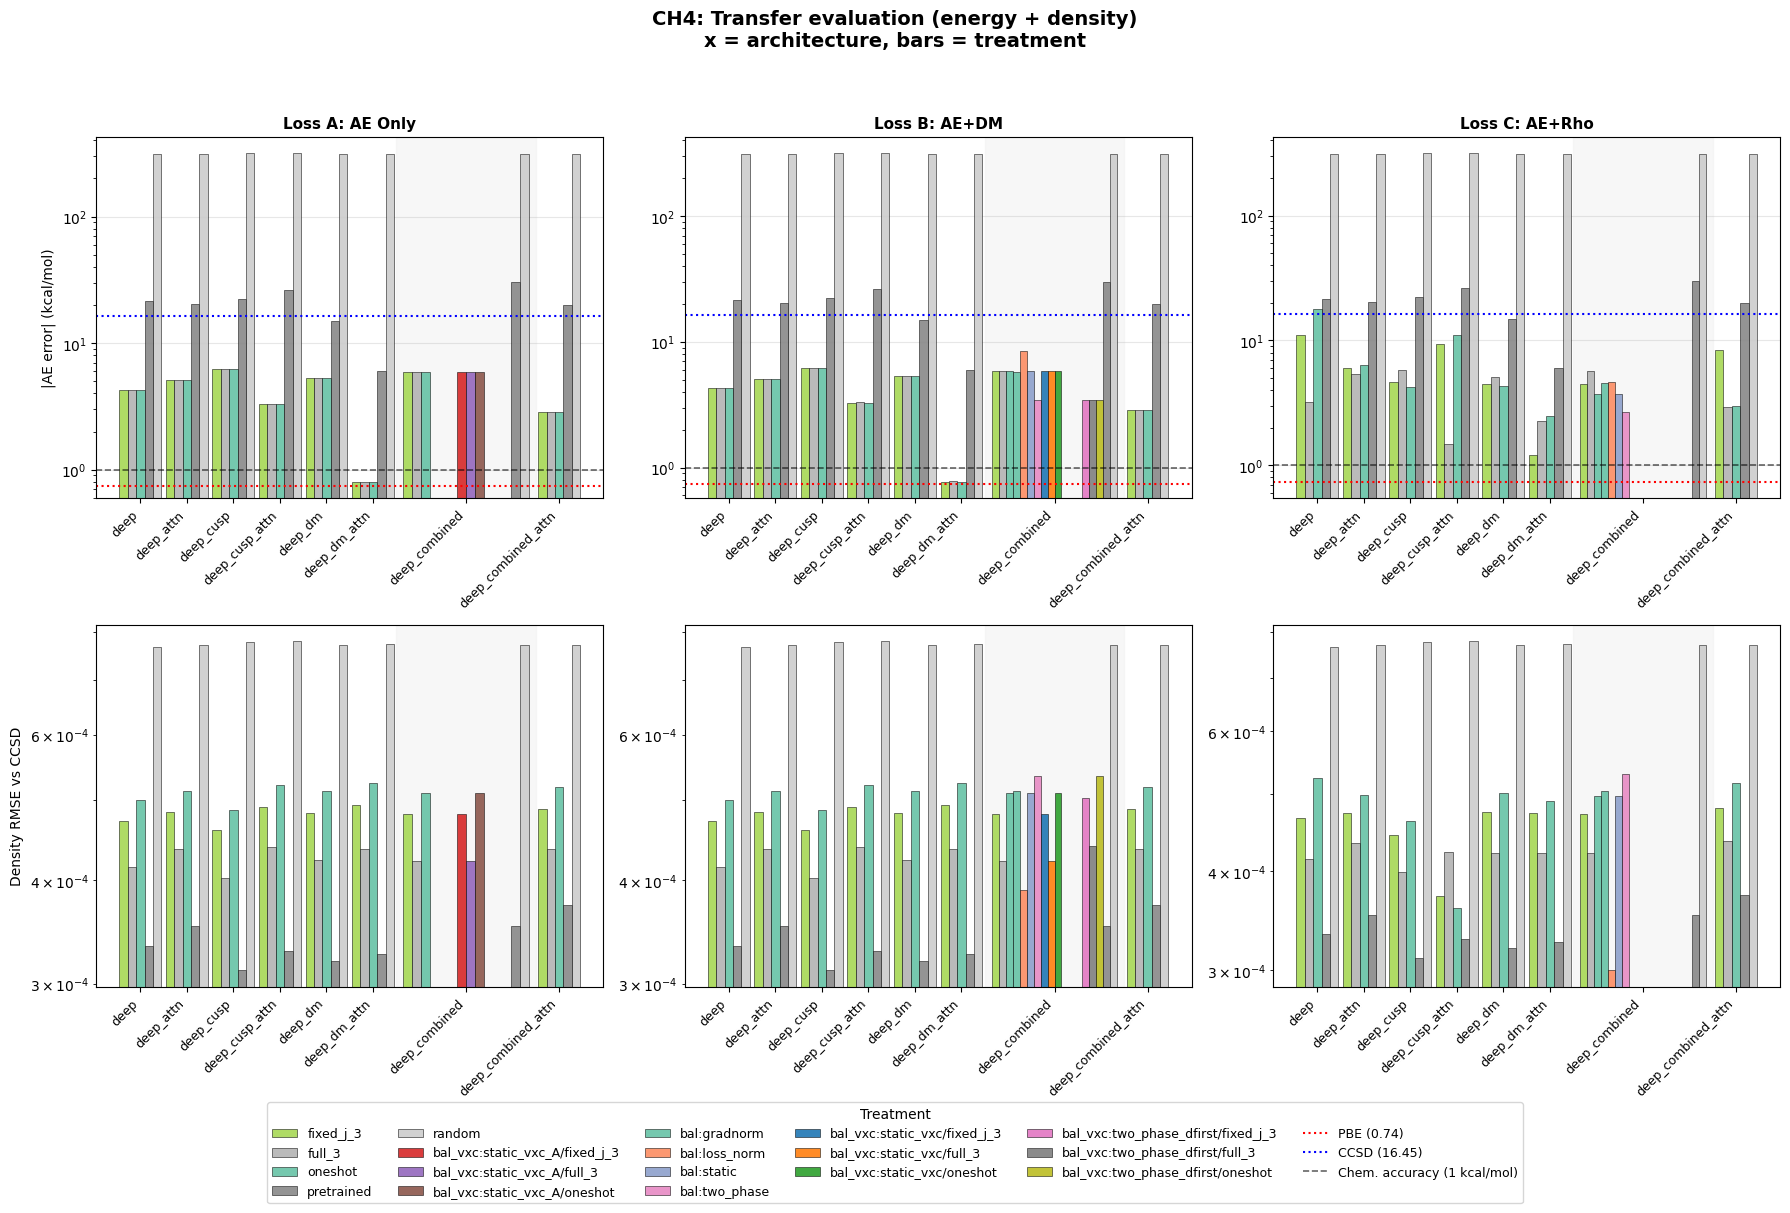

  Saved transfer_CH4.png
Transfer plots complete for 3 molecules across 3 losses


In [36]:
# ---- Transfer evaluation plots ----
n_mols = len(transfer_results)
if n_mols == 0:
    print("No transfer results to plot")
else:
    mol_items = list(transfer_results.items())
    _bl_set = set(BASELINE_LABELS)

    # Gather unique treatments across all molecules. Three classes:
    #   - base solvers: "oneshot", "fixed_j_3", "full_3" (main sweep)
    #   - bal:<strategy>: from balancing sweep base specs
    #   - bal_vxc:<variant>/<solver>: from V_xc-augmented balancing sweep
    #   - baseline labels: "pretrained", "random"
    _solvers_set, _bal_set, _bal_vxc_set = set(), set(), set()
    for tdf in transfer_results.values():
        for s in tdf['solver'].unique():
            if s in _bl_set:
                continue
            elif s.startswith('bal_vxc:'):
                _bal_vxc_set.add(s)
            elif s.startswith('bal:'):
                _bal_set.add(s)
            else:
                _solvers_set.add(s)
    _main_slvrs = sorted(_solvers_set)
    _bal_slvrs = sorted(_bal_set)
    _bal_vxc_slvrs = sorted(_bal_vxc_set)
    _base_slvrs = sorted(_bl_set)

    # Unique non-baseline losses
    _losses = sorted(set(
        l for tdf in transfer_results.values()
        for l in tdf['loss'].unique() if l != 'baseline'
    ))
    n_loss = len(_losses)
    _loss_abbrev = {l: l.split('_')[0] for l in _losses}

    # Build a self-contained color palette so this cell doesn't depend on
    # variables defined in cell 24 (bal_colors) that may not exist if the
    # user ran cells out of order. One cmap per class keeps treatments
    # visually distinguishable.
    _bal_cmap = plt.get_cmap('Set2')
    _bal_vxc_cmap = plt.get_cmap('tab10')
    _tc = {}
    for sl in _main_slvrs:
        _tc[sl] = solver_colors.get(sl, 'gray')
    for i, sl in enumerate(_bal_slvrs):
        _tc[sl] = _bal_cmap(i % _bal_cmap.N)
    for i, sl in enumerate(_bal_vxc_slvrs):
        _tc[sl] = _bal_vxc_cmap(i % _bal_vxc_cmap.N)
    for sl in _base_slvrs:
        _tc[sl] = baseline_colors.get(sl, '#AAAAAA')

    os.makedirs(f"{figures_dir}", exist_ok=True)

    for mol_name, tdf in mol_items:
        tm = next(t for t in test_molecules if t['name'] == mol_name)
        _is_atom = (len(tm['spec'].atom_composition) == 1
                    and tm['spec'].atom_composition[0][1] == 1)
        e_col = "E_error_kcalmol" if _is_atom else "AE_error_kcalmol"
        e_lbl = "|E error| (kcal/mol)" if _is_atom else "|AE error| (kcal/mol)"

        fig, axes = plt.subplots(
            2, max(n_loss, 1),
            figsize=(6 * max(n_loss, 1), 12),
            squeeze=False,
        )

        for metric_row, (col_name, y_lbl, metric_tag) in enumerate([
            (e_col, e_lbl, "energy"),
            ("density_rmse", "Density RMSE vs CCSD", "density"),
        ]):
            for col, loss in enumerate(_losses):
                ax = axes[metric_row, col]
                _seen = set()

                # Variable x-slot allocation: BAL_ARCH gets 3 slots so its
                # ~20 bars (3 main solvers + 4 balancing + 9 V_xc +
                # 2 baselines) are actually visible. Other archs get 1 slot.
                _arch_layout = []  # (arch_name, x_cursor, slots)
                _x_cursor = 0.0
                for arch in ARCH_NAMES:
                    _slots = 3.0 if arch == BAL_ARCH else 1.0
                    _arch_layout.append((arch, _x_cursor, _slots))
                    _x_cursor += _slots

                for arch, x_cursor, slots in _arch_layout:
                    x_center = x_cursor + (slots - 1) / 2.0
                    labels_here = list(_main_slvrs)
                    if arch == BAL_ARCH:
                        if loss in BAL_LOSS_NAMES:
                            labels_here += _bal_slvrs
                        labels_here += _bal_vxc_slvrs
                    labels_here += _base_slvrs
                    n_bars = len(labels_here)
                    # 0.9 * slots of horizontal space used for bars.
                    bw = (0.9 * slots) / max(n_bars, 1)

                    for si, sl in enumerate(labels_here):
                        if sl in _bl_set:
                            sub = tdf[(tdf['arch'] == arch)
                                      & (tdf['loss'] == 'baseline')
                                      & (tdf['solver'] == sl)]
                        else:
                            sub = tdf[(tdf['arch'] == arch)
                                      & (tdf['loss'] == loss)
                                      & (tdf['solver'] == sl)]
                        if len(sub) == 0:
                            continue
                        val = sub.iloc[0][col_name]
                        if not (np.isfinite(val) and val > 0):
                            continue
                        off = (si - (n_bars - 1) / 2) * bw
                        lbl = sl if sl not in _seen else ''
                        _seen.add(sl)
                        ax.bar(x_center + off, val, width=bw,
                               color=_tc.get(sl, 'gray'), label=lbl,
                               edgecolor='black', linewidth=0.4, alpha=0.9)

                _tick_xs = [x + (s - 1) / 2.0 for _, x, s in _arch_layout]
                ax.set_xticks(_tick_xs)
                ax.set_xticklabels(ARCH_NAMES, rotation=45, ha='right', fontsize=9)
                # Light shading behind the deep_combined block so reviewers
                # can visually locate the extra-wide region.
                for arch, x_cursor, slots in _arch_layout:
                    if slots > 1:
                        ax.axvspan(
                            x_cursor - 0.5, x_cursor + slots - 0.5,
                            color='#f0f0f0', alpha=0.5, zorder=0,
                        )
                if ax.patches:
                    ax.set_yscale('log')
                else:
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                            ha='center', va='center', fontsize=12, color='gray')
                ax.grid(True, which='major', axis='y', ls='-', alpha=0.3)
                ax.set_axisbelow(True)

                if col == 0:
                    ax.set_ylabel(y_lbl, fontsize=10)
                if metric_row == 0:
                    _abbrev_append = {"A":"AE Only", "B":"AE+DM","C":"AE+Rho"}
                    ax.set_title(f"Loss {_loss_abbrev[loss]}: {_abbrev_append[_loss_abbrev[loss]]}", fontsize=11, fontweight='bold')

                # Reference lines (energy row only)
                _add_lbl = (col == n_loss - 1)
                if metric_tag == "energy":
                    refs = transfer_refs.get(mol_name, {})
                    if not _is_atom:
                        if 'pbe_ae_err' in refs:
                            ax.axhline(refs['pbe_ae_err'], ls=':', color='r', lw=1.5,
                                       label=f"PBE ({refs['pbe_ae_err']:.2f})" if _add_lbl else "")
                        if 'ccsd_ae_err' in refs:
                            ax.axhline(refs['ccsd_ae_err'], ls=':', color='b', lw=1.5,
                                       label=f"CCSD ({refs['ccsd_ae_err']:.2f})" if _add_lbl else "")
                        ax.axhline(1.0, ls='--', color='k', alpha=0.6, lw=1.2,
                                   label="Chem. accuracy (1 kcal/mol)" if _add_lbl else "")
                    else:
                        if 'pbe_E_err' in refs:
                            ax.axhline(refs['pbe_E_err'], ls=':', color='r', lw=1.5,
                                       label=f"PBE ({refs['pbe_E_err']:.1f})" if _add_lbl else "")
                        if 'ccsd_E_err' in refs:
                            ax.axhline(refs['ccsd_E_err'], ls=':', color='b', lw=1.5,
                                       label=f"CCSD ({refs['ccsd_E_err']:.1f})" if _add_lbl else "")

        # Deduplicated legend at bottom, multi-column
        all_h, all_l = [], []
        for ax in axes.flat:
            h, l = ax.get_legend_handles_labels()
            all_h.extend(h)
            all_l.extend(l)
        by_label = {k: v for k, v in dict(zip(all_l, all_h)).items() if k}
        fig.legend(
            by_label.values(), by_label.keys(),
            loc='lower center', bbox_to_anchor=(0.5, -0.02),
            ncol=min(len(by_label), 6), fontsize=9,
            title='Treatment', title_fontsize=10,
            frameon=True, fancybox=True, shadow=False,
        )

        fig.suptitle(
            f"{mol_name}: Transfer evaluation (energy + density)\n"
            "x = architecture, bars = treatment",
            fontsize=14, fontweight='bold',
        )
        fig.tight_layout(rect=(0, 0.06, 1, 0.95))
        fig.savefig(f"{figures_dir}/transfer_{mol_name}.png",
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Saved transfer_{mol_name}.png")

    print(f"Transfer plots complete for {n_mols} molecules across {n_loss} losses")


Reference AE errors across ['H2', 'OH', 'CH4']: PBE MAE=3.3115515197097665, PBE RMSE=4.399756794121172, CCSD MAE=11.300075585464745, CCSD RMSE=12.062823579234218


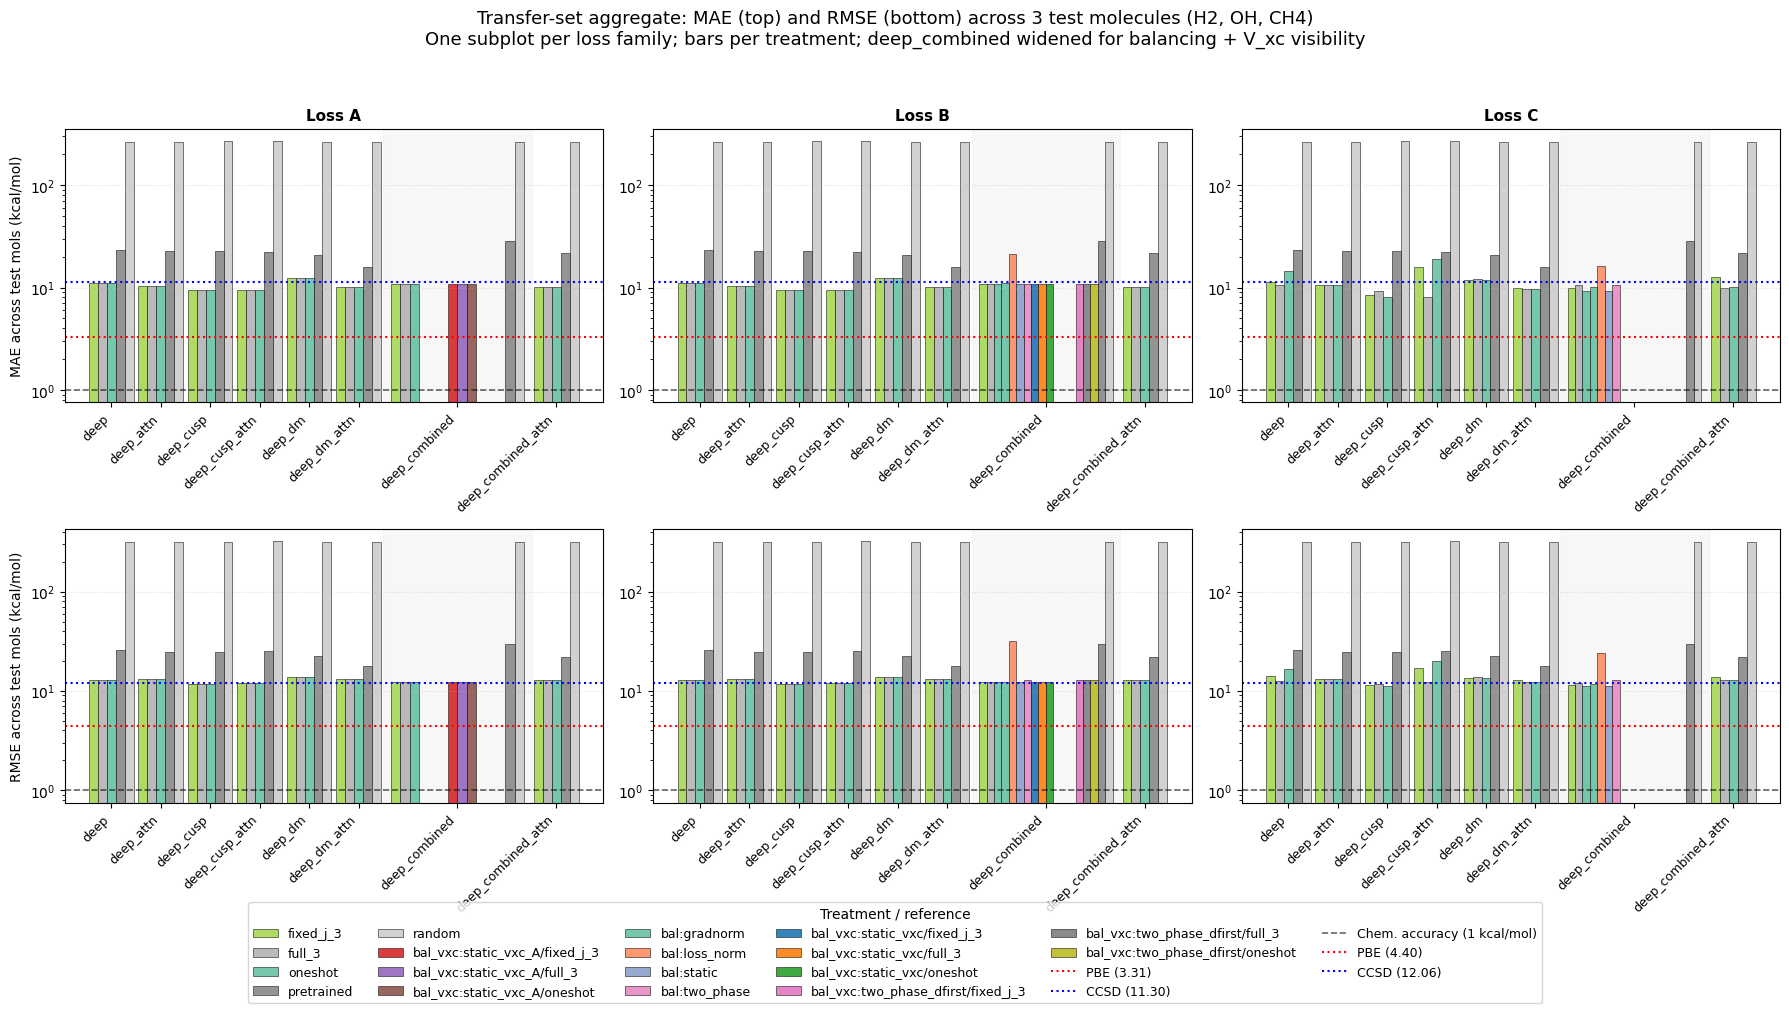


=== Top 10 treatments by cross-molecule MAE ===

-- Loss: A_atomization --
              arch    solver  n       mae      rmse
    deep_cusp_attn fixed_j_3  3  9.397570 12.148579
    deep_cusp_attn   oneshot  3  9.397570 12.148579
    deep_cusp_attn    full_3  3  9.397663 12.148734
         deep_cusp fixed_j_3  3  9.529501 11.746526
         deep_cusp   oneshot  3  9.529501 11.746526
         deep_cusp    full_3  3  9.529573 11.746644
deep_combined_attn fixed_j_3  3 10.024677 12.931683
deep_combined_attn   oneshot  3 10.024678 12.931684
deep_combined_attn    full_3  3 10.025007 12.932229
      deep_dm_attn    full_3  3 10.183193 13.115810

-- Loss: B_atomization_plus_dm --
              arch    solver  n       mae      rmse
    deep_cusp_attn   oneshot  3  9.382459 12.148421
    deep_cusp_attn fixed_j_3  3  9.391131 12.149637
    deep_cusp_attn    full_3  3  9.410712 12.152944
         deep_cusp   oneshot  3  9.527422 11.745344
         deep_cusp fixed_j_3  3  9.528867 11.745955
     

In [37]:
import pandas as _pd

# Concatenate per-molecule dataframes and compute aggregate metrics.
_concat_rows = []
for _mol_name, _tdf in transfer_results.items():
    _t2 = _tdf.copy()
    _t2['mol'] = _mol_name
    _concat_rows.append(_t2)
if not _concat_rows:
    print('No transfer results to aggregate'); raise SystemExit()
_tall = _pd.concat(_concat_rows, ignore_index=True)

# Group by (arch, loss, solver) and compute MAE, RMSE across mols.
def _rmse(x):
    x = _pd.Series(x).dropna()
    return float(np.sqrt(np.mean(x ** 2))) if len(x) else float('nan')

_agg = (_tall.groupby(['arch', 'loss', 'solver'])
              .agg(n=('AE_error_kcalmol', 'count'),
                   mae=('AE_error_kcalmol', 'mean'),
                   rmse=('AE_error_kcalmol', _rmse))
              .reset_index())

# Aggregate PBE / CCSD reference AE errors across the transfer mols
# the same way the NN bars are aggregated (MAE and RMSE across the
# same test set). These become horizontal reference lines so the
# reader can instantly tell where the NN treatments fall relative
# to classical DFT (PBE) and the post-HF target (CCSD).
_pbe_errs, _ccsd_errs = [], []
for _mol_name in transfer_results.keys():
    _refs = transfer_refs.get(_mol_name, {})
    if 'pbe_ae_err' in _refs:
        _pbe_errs.append(abs(_refs['pbe_ae_err']))
    elif 'pbe_E_err' in _refs:
        _pbe_errs.append(abs(_refs['pbe_E_err']))
    if 'ccsd_ae_err' in _refs:
        _ccsd_errs.append(abs(_refs['ccsd_ae_err']))
    elif 'ccsd_E_err' in _refs:
        _ccsd_errs.append(abs(_refs['ccsd_E_err']))

def _agg_ref(vals, how):
    if not vals:
        return None
    a = np.asarray(vals, dtype=float)
    if how == 'mae':
        return float(np.mean(np.abs(a)))
    if how == 'rmse':
        return float(np.sqrt(np.mean(a ** 2)))
    return None

_ref_vals = {
    'mae':  {'pbe': _agg_ref(_pbe_errs,  'mae'),  'ccsd': _agg_ref(_ccsd_errs, 'mae')},
    'rmse': {'pbe': _agg_ref(_pbe_errs,  'rmse'), 'ccsd': _agg_ref(_ccsd_errs, 'rmse')},
}
print(f"Reference AE errors across {list(transfer_results.keys())}: "
      f"PBE MAE={_ref_vals['mae']['pbe']}, PBE RMSE={_ref_vals['rmse']['pbe']}, "
      f"CCSD MAE={_ref_vals['mae']['ccsd']}, CCSD RMSE={_ref_vals['rmse']['ccsd']}")

# -- Plot: one figure with 2 rows (MAE, RMSE) x n_loss cols --
_losses_agg = sorted(set(_agg['loss'].unique()) - {'baseline'})
_n_loss_agg = len(_losses_agg)
_loss_abbrev_agg = {l: l.split('_')[0] for l in _losses_agg}

fig, axes = plt.subplots(
    2, max(_n_loss_agg, 1),
    figsize=(6 * max(_n_loss_agg, 1), 10), squeeze=False,
)

# Variable x-slot layout: deep_combined gets 3x.
def _arch_layout_agg():
    out = []; cur = 0.0
    for a in ARCH_NAMES:
        s = 3.0 if a == BAL_ARCH else 1.0
        out.append((a, cur, s)); cur += s
    return out

for row, (col_name, y_label) in enumerate([
    ('mae', 'MAE across test mols (kcal/mol)'),
    ('rmse', 'RMSE across test mols (kcal/mol)'),
]):
    for col, loss in enumerate(_losses_agg):
        ax = axes[row, col]
        _seen_lbl = set()
        for arch, x_cursor, slots in _arch_layout_agg():
            x_center = x_cursor + (slots - 1) / 2.0
            labels_here = list(_main_slvrs)
            if arch == BAL_ARCH:
                if loss in BAL_LOSS_NAMES:
                    labels_here += _bal_slvrs
                labels_here += _bal_vxc_slvrs
            labels_here += _base_slvrs
            n_bars = len(labels_here)
            bw = (0.9 * slots) / max(n_bars, 1)
            for si, sl in enumerate(labels_here):
                if sl in _bl_set:
                    _sub = _agg[(_agg['arch'] == arch)
                              & (_agg['loss'] == 'baseline')
                              & (_agg['solver'] == sl)]
                else:
                    _sub = _agg[(_agg['arch'] == arch)
                              & (_agg['loss'] == loss)
                              & (_agg['solver'] == sl)]
                if len(_sub) == 0:
                    continue
                val = abs(_sub.iloc[0][col_name])
                if not (np.isfinite(val) and val > 0):
                    continue
                off = (si - (n_bars - 1) / 2) * bw
                _lbl = sl if sl not in _seen_lbl else ''
                _seen_lbl.add(sl)
                ax.bar(x_center + off, val, width=bw,
                       color=_tc.get(sl, 'gray'), label=_lbl,
                       edgecolor='black', linewidth=0.4, alpha=0.9)
            if slots > 1:
                ax.axvspan(x_cursor - 0.5, x_cursor + slots - 0.5,
                           color='#f0f0f0', alpha=0.5, zorder=0)

        # Reference lines (PBE / CCSD aggregated the same way). Add
        # BEFORE plt.show so the inline-backend render captures them.
        _metric = 'rmse' if row == 1 else 'mae'
        _pbe_v  = _ref_vals[_metric]['pbe']
        _ccsd_v = _ref_vals[_metric]['ccsd']
        _add_lbl = (col == _n_loss_agg - 1)
        if _pbe_v is not None and np.isfinite(_pbe_v) and _pbe_v > 0:
            ax.axhline(_pbe_v, ls=':', color='r', lw=1.5,
                       label=(f"PBE ({_pbe_v:.2f})" if _add_lbl else ''))
        if _ccsd_v is not None and np.isfinite(_ccsd_v) and _ccsd_v > 0:
            ax.axhline(_ccsd_v, ls=':', color='b', lw=1.5,
                       label=(f"CCSD ({_ccsd_v:.2f})" if _add_lbl else ''))
        ax.axhline(1.0, ls='--', color='k', alpha=0.6, lw=1.2,
                   label=('Chem. accuracy (1 kcal/mol)' if _add_lbl else ''))

        ax.set_xticks([x + (s - 1) / 2.0 for _, x, s in _arch_layout_agg()])
        ax.set_xticklabels(ARCH_NAMES, rotation=45, ha='right', fontsize=9)
        if ax.patches:
            ax.set_yscale('log')
        ax.grid(True, which='major', axis='y', ls=':', alpha=0.4)
        if col == 0:
            ax.set_ylabel(y_label, fontsize=10)
        if row == 0:
            ax.set_title(f"Loss {_loss_abbrev_agg[loss]}", fontsize=11, fontweight='bold')

# Shared legend (built once, after bars AND reference lines are drawn).
_all_h, _all_l = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    _all_h.extend(h); _all_l.extend(l)
_by_label = {k: v for k, v in dict(zip(_all_l, _all_h)).items() if k}
fig.legend(_by_label.values(), _by_label.keys(),
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=min(len(_by_label), 6), fontsize=9,
           title='Treatment / reference', title_fontsize=10,
           frameon=True, fancybox=True)
fig.suptitle(
    f"Transfer-set aggregate: MAE (top) and RMSE (bottom) across "
    f"{len(transfer_results)} test molecules ({', '.join(transfer_results.keys())})\n"
    f"One subplot per loss family; bars per treatment; deep_combined widened for balancing + V_xc visibility",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
os.makedirs(f"{figures_dir}", exist_ok=True)
fig.savefig(f"{figures_dir}/transfer_aggregate.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Ranked top-10 table per loss family (by MAE, then by RMSE).
print("\n=== Top 10 treatments by cross-molecule MAE ===")
for loss in _losses_agg + ['baseline']:
    _sub = _agg[_agg['loss'] == loss].copy()
    if len(_sub) == 0:
        continue
    _sub = _sub.sort_values('mae').head(10)
    print(f"\n-- Loss: {loss} --")
    print(_sub[['arch', 'solver', 'n', 'mae', 'rmse']].to_string(index=False))


### Figure: F_x(s) Drift on CH4 Descriptors

The aggregate plot above shows that CH4 is where fine-tuned models lose most
to the pretrained baselines, despite never entering training. This cell tests
the mechanism directly: for every trained model we evaluate the exchange
enhancement ``F_x(rho, sigma, features)`` at CH4's grid points (from a PBE
SCF on CH4), then plot ``F_x`` vs reduced gradient ``s = |grad rho| / (2 k_F rho)``
aggregated over all models in each group.

- Pretrained models should track the PBE analytic curve tightly (they were
  fit to reproduce PBE).
- Random-initialized models span a wide envelope (no fit to PBE yet).
- Fine-tuned models should sit near PBE in ``(rho, s)`` regions H2O samples,
  but drift where H2O has little support and CH4 does (especially C-core).

Large drift in densely-sampled CH4 bins is the smoking gun for the transfer
gap: F_x is being modified where CH4 needs it, in regions where the H2O
training set has no corrective signal.


[Cell 49] sampled Fx on CH4 for 105/105 checkpoints


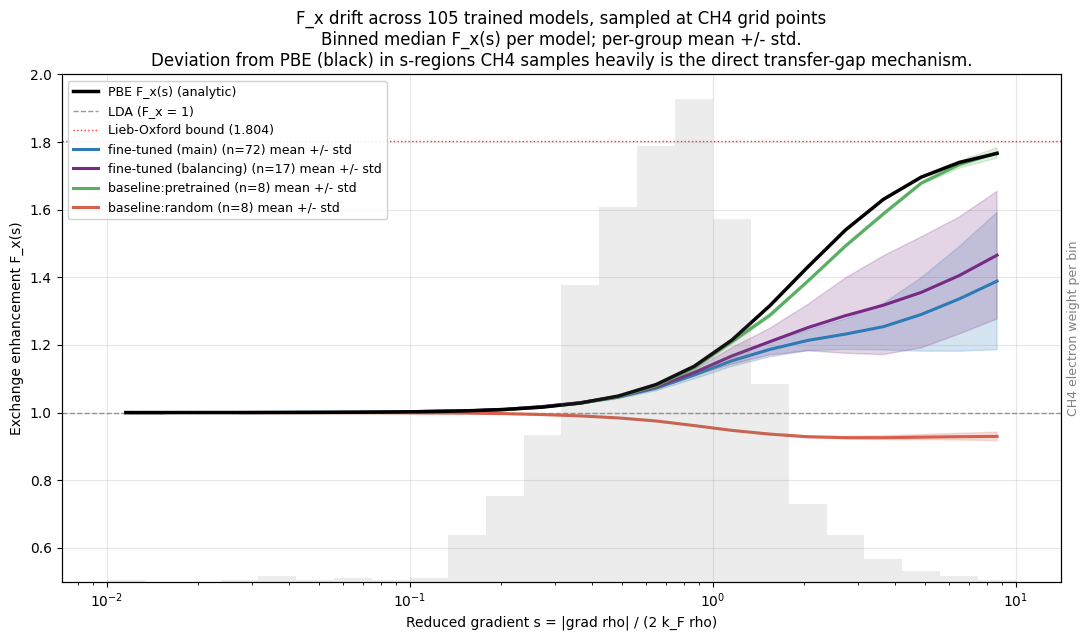

In [38]:
# PBE analytic exchange enhancement (Perdew-Burke-Ernzerhof 1996).
_PBE_KAPPA = 0.804
_PBE_MU = 0.21951
def _pbe_Fx_of_s(s):
    return 1.0 + _PBE_KAPPA - _PBE_KAPPA / (1.0 + _PBE_MU * s ** 2 / _PBE_KAPPA)

# Reduced gradient s = |grad rho| / (2 k_F rho), k_F = (3 pi^2 rho)^(1/3).
_KF_PREFAC = (3.0 * np.pi ** 2) ** (1.0 / 3.0)
def _reduced_gradient(rho, sigma):
    rho_s = np.maximum(np.asarray(rho), 1e-12)
    sig_s = np.maximum(np.asarray(sigma), 0.0)
    return np.sqrt(sig_s) / (2.0 * _KF_PREFAC * rho_s ** (4.0 / 3.0))

# CH4 descriptors: we only need the spec. Build one mol_data per arch so
# each arch's descriptor set is materialized correctly.
_ch4_item = next((t for t in test_molecules if t['name'] == 'CH4'), None)
if _ch4_item is None:
    print("[Cell 49] CH4 not in test_molecules -- skipping Fx drift plot")
else:
    _ch4_spec = _ch4_item['spec']
    _ch4_mol_data_by_arch = {}
    for _arch_name in ARCH_NAMES:
        _arch_cfg = alec.get_architecture(_arch_name)
        _descs = _arch_cfg.materialize_descriptors()
        _keys = set()
        for _d in _descs:
            _keys.update(_d.required_mol_keys)
        _ch4_mol_data_by_arch[_arch_name] = alec.precompute_fixed_density_data(
            _ch4_spec,
            required_keys=tuple(_keys),
            descriptors=_descs,
        )

    # Bin edges in s. Core density (high-rho, low-s) -> log s near -2 to -1;
    # valence and tail -> s in 0.1 to ~5. Bound to 10 to capture tail drift.
    _s_bins = np.logspace(-2.0, 1.0, 25)
    _s_centers = np.sqrt(_s_bins[:-1] * _s_bins[1:])

    def _binned_median(s, Fx):
        out = np.full(len(_s_centers), np.nan)
        for i in range(len(_s_centers)):
            mask = (s >= _s_bins[i]) & (s < _s_bins[i + 1])
            if np.any(mask):
                out[i] = float(np.nanmedian(Fx[mask]))
        return out

    # Group checkpoints. Fine-tuned = everything in main/train and balancing
    # sweeps. Baselines stay separate. V_xc variants folded into fine-tuned.
    _groups = {
        'fine-tuned (main)':       {'ckpts': [], 'color': '#2c7bb6'},
        'fine-tuned (balancing)':  {'ckpts': [], 'color': '#762a83'},
        'baseline:pretrained':     {'ckpts': [], 'color': '#5aae61'},
        'baseline:random':         {'ckpts': [], 'color': '#d6604d'},
    }
    for _arch in ARCH_NAMES:
        for _loss in LOSS_NAMES:
            for _solver in SOLVER_LABELS:
                _ckpt = f"{train_dir}/{_arch}/{_loss}/{_solver}/model.eqx"
                if os.path.isfile(_ckpt):
                    _groups['fine-tuned (main)']['ckpts'].append((_arch, _ckpt))
    for _loss in BAL_LOSS_NAMES:
        for _bl in BALANCING_CONFIGS:
            _ckpt = f"{train_balancing_dir}/{_loss}/{_bl}/model.eqx"
            if os.path.isfile(_ckpt):
                _groups['fine-tuned (balancing)']['ckpts'].append((BAL_ARCH, _ckpt))
    for _variant_label, (_ln, _, _) in VXC_VARIANTS.items():
        for _solver in SOLVER_LABELS:
            _ckpt = f"{train_balancing_dir}/vxc/{_variant_label}/{_solver}/model.eqx"
            if os.path.isfile(_ckpt):
                _groups['fine-tuned (balancing)']['ckpts'].append((BAL_ARCH, _ckpt))
    for _arch in ARCH_NAMES:
        for _bl in BASELINE_LABELS:
            _ckpt = f"{baseline_dir}/{_bl}/{_arch}/model.eqx"
            if os.path.isfile(_ckpt):
                _key = f'baseline:{_bl}'
                if _key in _groups:
                    _groups[_key]['ckpts'].append((_arch, _ckpt))

    _rho_for_mask = {a: np.asarray(md['rho_grid'])
                     for a, md in _ch4_mol_data_by_arch.items()}
    _sigma_for_mask = {a: np.asarray(md['sigma_grid'])
                       for a, md in _ch4_mol_data_by_arch.items()}

    _per_group_curves = {k: [] for k in _groups}
    _n_total = sum(len(g['ckpts']) for g in _groups.values())
    _n_done = 0
    from xcquinox.alec.descriptors import assemble_descriptor_features as _asm_feat
    for _gname, _ginfo in _groups.items():
        for _arch, _ckpt in _ginfo['ckpts']:
            _arch_cfg = alec.get_architecture(_arch)
            try:
                _model = eqx.tree_deserialise_leaves(
                    _ckpt, alec.AlecGGAModel.from_arch(_arch_cfg),
                )
            except Exception as _e:
                print(f"  skip {_arch} {_ckpt}: load error ({_e})")
                continue
            _md = _ch4_mol_data_by_arch[_arch]
            _rho = _rho_for_mask[_arch]
            _sigma = _sigma_for_mask[_arch]
            _features = _asm_feat(_model.descriptors, _md)
            try:
                _Fx = np.asarray(_model.eval_Fx(
                    jnp.asarray(_rho), jnp.asarray(_sigma), _features,
                ))
            except Exception as _e:
                print(f"  skip {_arch} {_ckpt}: eval_Fx error ({_e})")
                continue
            _s = _reduced_gradient(_rho, _sigma)
            _mask = (_rho > 1e-6) & np.isfinite(_Fx) & np.isfinite(_s) & (_s > 0)
            if not np.any(_mask):
                continue
            _per_group_curves[_gname].append(_binned_median(_s[_mask], _Fx[_mask]))
            _n_done += 1
            # Per-checkpoint JAX cache release -- hundreds of model loads.
            jax.clear_caches(); gc.collect()
    print(f"[Cell 49] sampled Fx on CH4 for {_n_done}/{_n_total} checkpoints")

    fig, ax = plt.subplots(figsize=(11, 6.5))
    _pbe_curve = _pbe_Fx_of_s(_s_centers)
    ax.semilogx(_s_centers, _pbe_curve, 'k-', lw=2.5,
                label='PBE F_x(s) (analytic)', zorder=5)
    ax.axhline(1.0, ls='--', color='gray', lw=1.0, alpha=0.8,
               label='LDA (F_x = 1)')
    ax.axhline(1.804, ls=':', color='red', lw=1.0, alpha=0.8,
               label='Lieb-Oxford bound (1.804)')

    import warnings as _warnings
    for _gname, _ginfo in _groups.items():
        _curves = [c for c in _per_group_curves[_gname] if c is not None]
        if not _curves:
            continue
        _arr = np.stack(_curves, axis=0)
        # Bins outside the sampled s-range are all-NaN -> suppress the
        # expected "Mean of empty slice" / "Degrees of freedom <= 0"
        # warnings; all-NaN columns correctly propagate as NaN and mask
        # the mean/std lines for those bins.
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore", category=RuntimeWarning)
            _m = np.nanmean(_arr, axis=0)
            _sd = np.nanstd(_arr, axis=0)
        _color = _ginfo['color']
        ax.semilogx(_s_centers, _m, '-', color=_color, lw=2.2, zorder=4,
                    label=f"{_gname} (n={_arr.shape[0]}) mean +/- std")
        ax.fill_between(_s_centers, _m - _sd, _m + _sd,
                        color=_color, alpha=0.20, zorder=2)

    # CH4 grid-point density (s-distribution) on twin axis so the reader
    # can tell which s-bins are actually sampled by CH4 and therefore
    # matter most for transfer error.
    _any_arch = next(iter(_ch4_mol_data_by_arch))
    _s_ch4 = _reduced_gradient(
        _rho_for_mask[_any_arch], _sigma_for_mask[_any_arch],
    )
    _w_ch4 = np.asarray(_ch4_mol_data_by_arch[_any_arch]['grid_weights'])
    _rho_ch4 = _rho_for_mask[_any_arch]
    _m2 = (_rho_ch4 > 1e-6) & np.isfinite(_s_ch4) & (_s_ch4 > 0)
    _ax2 = ax.twinx()
    _ax2.hist(_s_ch4[_m2], bins=_s_bins, weights=(_w_ch4 * _rho_ch4)[_m2],
              color='gray', alpha=0.15, zorder=1,
              label='CH4 electron-weighted s distribution')
    _ax2.set_ylabel('CH4 electron weight per bin', color='gray', fontsize=9)
    _ax2.tick_params(axis='y', labelcolor='gray')
    _ax2.set_yticks([])  # suppress numeric ticks; scale is relative.

    ax.set_xscale('log')
    ax.set_xlabel('Reduced gradient s = |grad rho| / (2 k_F rho)')
    ax.set_ylabel('Exchange enhancement F_x(s)')
    ax.set_title(
        f"F_x drift across {_n_done} trained models, sampled at CH4 grid points\n"
        f"Binned median F_x(s) per model; per-group mean +/- std.\n"
        f"Deviation from PBE (black) in s-regions CH4 samples heavily is the direct transfer-gap mechanism."
    )
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax.grid(True, which='major', alpha=0.3)
    ax.set_ylim(0.5, 2.0)
    fig.tight_layout()
    os.makedirs(f"{figures_dir}", exist_ok=True)
    fig.savefig(f"{figures_dir}/fx_drift_ch4.png",
                dpi=150, bbox_inches='tight')
    plt.show()


## Section 8: Step 5 Findings -- F_x Drift Interprets the Transfer Gap

The F_x(s) figure above (Cell 51, sampled at CH4 grid points across 105
trained models) is an unusually clean confirmation of why fine-tuned
models transfer worse than the pretrained baseline on CH4. We lock in the
reading here so step 6 can act on it.

### What the figure shows

1. **Baselines behave as expected.** Pretrained (green) tracks PBE (black)
   to within the line width everywhere -- the pretraining loss did its job.
   Random (red) sits pinned at F_x ~ 1 (LDA) since no data has shaped it yet.

2. **Fine-tuned models agree with PBE only where H2O has density weight.**
   For `s <~ 0.5` (core and near-nucleus regions), both fine-tuned groups
   (blue = main, purple = balancing) overlap the PBE curve almost exactly.
   This is the `s` regime where H2O's O-core and O-H bonds dominate the
   training loss.

3. **The divergence begins at `s ~ 0.7` and grows.** By `s = 10`, the
   fine-tuned curves plateau at F_x ~ 1.45 -- about 0.32 below PBE's value
   of ~1.77. The functional has been *flattened* at intermediate-to-large
   reduced gradient. Fine-tuning suppresses the gradient enhancement that
   PBE built into F_x for high-`s` regions.

4. **CH4's electron weight sits exactly in the drift zone.** The gray
   histogram (twin axis) peaks at `s ~ 0.8-1.5` and has a long right tail
   extending past `s = 10`. Every gray bar to the right of `s ~ 0.7` is
   electron weight being evaluated by a functional that has drifted
   ~0.05-0.3 below PBE.

### Why the drift is downward

The H2O training signal has no examples of the "exchange hole over a steep
gradient" regime that CH4's C-H bond tails probe. The loss gradient at
those `(rho, s)` points during H2O training is essentially zero -- no H2O
grid points contribute there, and `w_atomic · _atomic_reg` on the atoms
(H, O) does not probe this `s` range either (atoms are spherically
symmetric with different gradient profiles from a covalent C-H bond).
With no restoring force, ADAM's implicit regularization in flat directions
pulls the enhancement down toward the LDA limit.

### Numeric prediction

At `s = 2` (a reasonable CH4-bond representative point) PBE gives
F_x ~ 1.4, fine-tuned gives F_x ~ 1.25 -- ~11% suppression of the exchange
enhancement. Multiplied by the CH4 exchange energy contribution from those
grid points, this is comfortably large enough to account for the 5-30
kcal/mol AE errors in the aggregate plot (Cell 49).

### Main vs. balancing groups

The blue (main) and purple (balancing) bands overlap almost perfectly in
the Cell 51 figure. That is its own useful finding: **the V_xc matching
and loss-balancing additions that distinguish those two groups do not fix
the core-valence `s`-coverage problem.** They tune how H2O is matched;
they do not give the functional any new `(rho, s)` data. Any further
improvement probably has to come from the training set itself, not from
loss engineering.

### Step 6 roadmap (resume here)

Ordered by expected information gain:

1. **Add a carbon-containing species (or C atom) to the training set,**
   with meaningful atomic regularization weight. The F_x curve in the
   CH4-sampled plot should immediately pull back up toward PBE at
   `s >~ 1`. If it does, the mechanism is nailed and we know the fix
   generalizes to any out-of-sample element.

2. **Add a PBE-anchor term to the loss at unvisited `(rho, s)`** --
   regularize `|F_x_nn - F_x_PBE|^2` sampled uniformly on a `(rho, s)`
   grid with small weight (~1e-3). Cheapest possible fix since it
   requires no new reference molecules. Test in isolation to see whether
   it recovers most of the lost ground.

3. **Widen the training set to H2 + OH + CH4 (and isolated C)** so all
   transfer molecules are also training molecules. Then the "transfer
   gap" is no longer meaningful for those molecules -- but the new
   `{H2, OH, CH4}` gap on a different test set (e.g. NH3, H2CO, HF)
   tells us whether the overfitting pattern survives enlarging from
   one molecule to four. This is the cleanest way to separate the
   "molecule count" axis from the "density regime coverage" axis.

4. **Raise `w_atomic` from 0.01 -> 0.1 or 1.0.** Should reduce the
   OH gap more than H2 (OH has O, H2 does not). Easy to test.

5. **Per-molecule loss normalization.** H2O's grid point count dominates
   current steps; normalize by compound so H, O, H2O each contribute
   equally to the gradient. Pairs well with (4).

### What will carry over to step 6

- Full training pipeline (oneshot / fixed_j / full solvers) verified in
  step 5.
- Balancing + V_xc-matching infrastructure in place; adding new loss
  terms (e.g. PBE-anchor at unvisited `(rho, s)`) fits naturally.
- Checkpoint layout, eval pipeline, transfer aggregate plot, and the
  F_x-drift diagnostic (Cell 51) all generalize with no change beyond
  new molecule specs. The diagnostic is the single most informative
  plot for answering "is step 6 working?".
